Steps Completed:
Data Overview:

Loaded the dataset and examined its structure (rows, columns, and variable names).

The dataset has 10,174 rows and 8 variables, including ID, Name, Role, Transcript, Resume, decision, Reason_for_decision, and Job_Description.

1-Data Cleaning:

2-Missing Values Handling:

Checked for missing values in the dataset and performed imputation:

Numerical columns were imputed with the mean.

Categorical columns were imputed with the mode.

3-Duplicate Removal:

Checked for and removed duplicate rows from the dataset.

4-Data Type Conversion:

Converted decision and Role columns to categorical data types for easier processing.

5-Text Preprocessing:

Combined text columns (Resume, Transcript, Job_Description) into a single column.

6-Cleaned the text by:

Converting it to lowercase.

Removing punctuation and numbers.

Tokenizing the text.

Removing stopwords.

Lemmatizing the tokens.

7-TF-IDF Vectorization:

Applied TF-IDF vectorization to the cleaned text, creating a matrix of numerical features from the text data.

Saved the processed dataset with TF-IDF features to a CSV file.

8-Feature Engineering:

Encoded the Role column using Label Encoding.

Mapped the decision column to a binary label column (0 for rejected, 1 for selected).

Saved the updated dataset with labeled columns to a CSV file.

9-Visualization:

10-Distribution of Role_encoded and label:

Created violin plots to visualize the distribution of the Role_encoded feature across selected and rejected candidates.

11-Distribution of TF-IDF Features:

Created violin plots to visualize the distribution of features like "dont", "excellent", etc., by the label (selected vs. rejected).

12-Correlation Heatmap:

Generated a correlation heatmap for numeric features, including Role_encoded, label, and TF-IDF features.

13-Pair Plots:

Visualized pairwise relationships between selected features (like Role_encoded, dont, excellent, etc.) with the label.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd

# Replace with your actual file path
file_path = '/content/drive/MyDrive/Dissertation/dataset.csv'

# Read the dataset
df = pd.read_csv(file_path)

# View the first few rows
df.head()  # This will display the first 5 rows of the datasset

,ID,Name,Role,Transcript,Resume,decision,Reason_for_decision,Job_Description
0,jasojo159,Jason Jones,E-commerce Specialist,"Interviewer: Good morning, Jason. It's great t...",Here's a professional resume for Jason Jones:\...,reject,Lacked leadership skills for a senior position.,Be part of a passionate team at the forefront ...
1,annma759,Ann Marshall,Game Developer,Interview Scene\n\nA conference room with a ta...,Here's a professional resume for Ann Marshall:...,select,Strong technical skills in AI and ML.,Help us build the next-generation products as ...
2,patrmc729,Patrick Mcclain,Human Resources Specialist,Interview Setting: A conference room in a medi...,Here's a professional resume for Patrick Mccla...,reject,Insufficient system design expertise for senio...,We need a Human Resources Specialist to enhanc...
3,patrgr422,Patricia Gray,E-commerce Specialist,Here's a simulated professional interview for ...,Here's a professional resume for Patricia Gray...,select,Impressive leadership and communication abilit...,Be part of a passionate team at the forefront ...
4,amangr696,Amanda Gross,E-commerce Specialist,Here's the simulated interview:\n\nInterviewer...,Here's a professional resume for Amanda Gross:...,reject,Lacked leadership skills for a senior position.,We are looking for an experienced E-commerce S...


In [ ]:

# Get the number of rows
num_rows = df.shape[0]
print(f"Number of rows: {num_rows}")

# Get the number of variables (columns)
num_variables = df.shape[1]
print(f"Number of variables: {num_variables}")

# Get the names of the variables
variable_names = df.columns.tolist()
print(f"Variable names: {variable_names}")

Number of rows: 10174
Number of variables: 8
Variable names: ['ID', 'Name', 'Role', 'Transcript', 'Resume', 'decision', 'Reason_for_decision', 'Job_Description']


**Data Proprocessing:**

Data Cleaning



1.   Handling Missing Data




In [ ]:


# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())


# Identify numerical columns
numerical_cols = df.select_dtypes(include=['number']).columns
for col in numerical_cols:
  if df[col].isnull().sum() > 0:
    mean_val = df[col].mean()
    df[col].fillna(mean_val, inplace=True)
    print(f"Filled missing values in '{col}' with the mean ({mean_val:.2f})")


# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
  if df[col].isnull().sum() > 0:
    mode_val = df[col].mode()[0] # mode() can return multiple values, take the first
    df[col].fillna(mode_val, inplace=True)
    print(f"Filled missing values in '{col}' with the mode ('{mode_val}')")

# Verify that missing values have been handled
print("\nMissing values per column after imputation:")
print(df.isnull().sum())

Missing values per column:
ID                     0
Name                   0
Role                   0
Transcript             0
Resume                 0
decision               0
Reason_for_decision    0
Job_Description        0
dtype: int64

Missing values per column after imputation:
ID                     0
Name                   0
Role                   0
Transcript             0
Resume                 0
decision               0
Reason_for_decision    0
Job_Description        0
dtype: int64




2.   Removing Duplicates



In [ ]:

# Getting the number of rows before removing duplicates
num_rows_before_duplicates = df.shape[0]
print(f"Number of rows before removing duplicates: {num_rows_before_duplicates}")

# Removing duplicate rows
df.drop_duplicates(inplace=True)

# Getting the number of rows after removing duplicates
num_rows_after_duplicates = df.shape[0]
print(f"Number of rows after removing duplicates: {num_rows_after_duplicates}")

# Print the number of duplicate rows removed
duplicates_removed = num_rows_before_duplicates - num_rows_after_duplicates
print(f"Number of duplicate rows removed: {duplicates_removed}")

# Verifying that duplicates have been removed
print(f"Are there any duplicate rows remaining? {df.duplicated().any()}")

Number of rows before removing duplicates: 10174
Number of rows after removing duplicates: 10174
Number of duplicate rows removed: 0
Are there any duplicate rows remaining? False





3.   Fixing incorrect Data Types



In [ ]:

# Convert 'decision' column to categorical type (it should be categorical)
df['decision'] = df['decision'].astype('category')
df['Role'] = df['Role'].astype('category')
# Check the updated data types
print(df.dtypes)


ID                       object
Name                     object
Role                   category
Transcript               object
Resume                   object
decision               category
Reason_for_decision      object
Job_Description          object
dtype: object


Text Preprocessing

In [ ]:
!pip install nltk

import nltk
# Download necessary NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
# Download the missing punkt_tab resource
nltk.download('punkt_tab')

import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# Combine text columns
df['combined_text'] = df['Resume'].fillna('') + ' ' + df['Transcript'].fillna('') + ' '+ df['Reason_for_decision'].fillna('') +' '+ df['Job_Description'].fillna('')

# Lowercase
df['cleaned_text'] = df['combined_text'].str.lower()

# Remove punctuation and numbers
df['cleaned_text'] = df['cleaned_text'].apply(lambda x: re.sub(r'[^a-z\s]', '', x))

# Tokenize
df['tokens'] = df['cleaned_text'].apply(nltk.word_tokenize)

# Remove stopwords
stop_words = set(stopwords.words('english'))
df['tokens'] = df['tokens'].apply(lambda x: [word for word in x if word not in stop_words])

# Lemmatize
lemmatizer = WordNetLemmatizer()
df['tokens'] = df['tokens'].apply(lambda x: [lemmatizer.lemmatize(word) for word in x])

# Rejoin tokens
df['cleaned_text'] = df['tokens'].apply(lambda x: ' '.join(x))

# Vectorize with TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=500)
tfidf_matrix = tfidf_vectorizer.fit_transform(df['cleaned_text'])

# Convert TF-IDF matrix to DataFrame
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

# Add TF-IDF features to original DataFrame
df = pd.concat([df, tfidf_df], axis=1)

# Drop intermediate text columns if desired
df = df.drop(columns=['combined_text', 'tokens'])

# Save the processed DataFrame
output_file_path = '/content/drive/MyDrive/Dissertation/processed_data.csv'
df.to_csv(output_file_path, index=False)

print(f"\nProcessed data saved to {output_file_path}")

# Display sample of cleaned text
print("\nSample of cleaned text:")
print(df['cleaned_text'].head().iloc[0]) # Displaying the first cleaned text entry

# Display sample of TF-IDF output
print("\nSample of TF-IDF features for the first entry:")
print(df[tfidf_vectorizer.get_feature_names_out()].head(1).iloc[0])

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!



Processed data saved to /content/drive/MyDrive/Dissertation/processed_data.csv

Sample of cleaned text:
here professional resume jason jones jason jones ecommerce specialist contact information email jasonjonesemailcommailtojasonjonesemailcom phone linkedin linkedincominjasonjones summary resultsdriven ecommerce specialist year experience inventory management seo online advertising analytics proven track record increasing online sale improving website traffic optimizing inventory level skilled analyzing complex data set identifying trend making datadriven decision passionate staying uptodate latest ecommerce trend technology professional experience ecommerce specialist xyz corporation present managed inventory level across multiple channel resulting reduction stockouts reduction overstocking developed implemented seo strategy increased website traffic improved search engine ranking created executed online advertising campaign generated increase sale increase conversion rate analyzed w

In [ ]:

# Step 1: Setup and Imports

import spacy
import subprocess
import importlib
import pandas as pd
import re
import numpy as np

# Load SpaCy model (install if missing)
model_name = "en_core_web_sm"
try:
    nlp = spacy.load(model_name)
except OSError:
    print(f"Model '{model_name}' not found. Installing now...")
    subprocess.run(["python", "-m", "spacy", "download", model_name])
    importlib.invalidate_caches()
    nlp = spacy.load(model_name)
    print(f"Model '{model_name}' installed and loaded successfully.")


# Step 2: Load Preprocessed CSV

processed_data_path = '/content/drive/MyDrive/Dissertation/processed_data.csv'
try:
    df = pd.read_csv(processed_data_path)
    print(f" Loaded processed data from {processed_data_path}")
except FileNotFoundError:
    print(f" Error: File not found at {processed_data_path}")
    exit()


# Step 3: Define Feature Extraction

def extract_structured_features(text, doc=None):
    age = gender = experience_level = education_level = location = None

    if not text or pd.isnull(text):
        return age, gender, experience_level, education_level, location

    if doc is None:
        doc = nlp(text)

    # Location (GPE)
    for ent in doc.ents:
        if ent.label_ == "GPE":
            location = ent.text
            break

    text_lower = text.lower()

    # Gender
    if re.search(r'\b(he|him|his|male)\b', text_lower):
        gender = 'Male'
    elif re.search(r'\b(she|her|hers|female)\b', text_lower):
        gender = 'Female'

    # Experience
    experience_match = re.search(r'(\d+)\s*years?\s*of\s*experience', text_lower)
    if experience_match:
        experience_level = f"{experience_match.group(1)} years"
    else:
        if re.search(r'\b(entry-level|junior)\b', text_lower):
            experience_level = 'Entry-Level/Junior'
        elif re.search(r'\b(senior|lead)\b', text_lower):
            experience_level = 'Senior/Lead'
        elif re.search(r'\b(mid-level)\b', text_lower):
            experience_level = 'Mid-Level'

    # Education
    if re.search(r'\b(phd|doctorate)\b', text_lower):
        education_level = 'PhD'
    elif re.search(r'\b(master\'?s?|msc|ma|ms)\b', text_lower):
        education_level = "Master's"
    elif re.search(r'\b(bachelor\'?s?|bsc|ba|bs)\b', text_lower):
        education_level = "Bachelor's"
    elif re.search(r'\b(associate\'?s?|college)\b', text_lower):
        education_level = "Associate's/College"
    elif re.search(r'\b(high school)\b', text_lower):
        education_level = 'High School'

    # Age
    age_match = re.search(r'(\d+)\s*(?:years?|yrs?)\s*(?:old|of age)', text_lower)
    if age_match:
        age = int(age_match.group(1))

    return age, gender, experience_level, education_level, location


# Step 4: Apply Efficient Feature Extraction Using nlp.pipe()

if 'cleaned_text' in df.columns:
    print(" Processing texts efficiently using SpaCy pipe...")

    texts = df['cleaned_text'].fillna('').tolist()
    docs = nlp.pipe(texts, batch_size=100)

    # Preallocate lists for each feature
    ages, genders, experiences, educations, locations = [], [], [], [], []

    for doc, text in zip(docs, texts):
        age, gender, exp, edu, loc = extract_structured_features(text, doc)
        ages.append(age)
        genders.append(gender)
        experiences.append(exp)
        educations.append(edu)
        locations.append(loc)

    # Assign extracted features to DataFrame
    df['extracted_age'] = ages
    df['extracted_gender'] = genders
    df['extracted_experience_level'] = experiences
    df['extracted_education_level'] = educations
    df['extracted_location'] = locations

else:
    print(" Error: 'cleaned_text' column not found in the DataFrame.")
    exit()


# Step 5: Save Updated DataFrame

output_file_path = '/content/drive/MyDrive/Dissertation/processed_data_with_features.csv'
df.to_csv(output_file_path, index=False)
print(f"\n Saved updated data with extracted features to {output_file_path}")


# Step 6: Summary of Features

print("\n Summary of Extracted Features:")
feature_columns = ['extracted_age', 'extracted_gender', 'extracted_experience_level',
                   'extracted_education_level', 'extracted_location']

for col in feature_columns:
    valid = df[col].count()
    missing = df[col].isnull().sum()
    print(f"- {col}:  Valid = {valid},  Missing = {missing}")


# Step 7: Show Sample Output

print("\n Sample of DataFrame with New Features:")
sample_cols = ['ID', 'Name', 'cleaned_text'] + feature_columns
existing_cols = [col for col in sample_cols if col in df.columns]
print(df[existing_cols].head())


 Loaded processed data from /content/drive/MyDrive/Dissertation/processed_data.csv
 Processing texts efficiently using SpaCy pipe...

 Saved updated data with extracted features to /content/drive/MyDrive/Dissertation/processed_data_with_features.csv

 Summary of Extracted Features:
- extracted_age:  Valid = 0,  Missing = 10174
- extracted_gender:  Valid = 55,  Missing = 10119
- extracted_experience_level:  Valid = 8089,  Missing = 2085
- extracted_education_level:  Valid = 9064,  Missing = 1110
- extracted_location:  Valid = 1933,  Missing = 8241

 Sample of DataFrame with New Features:
          ID             Name  \
0  jasojo159      Jason Jones   
1   annma759     Ann Marshall   
2  patrmc729  Patrick Mcclain   
3  patrgr422    Patricia Gray   
4  amangr696     Amanda Gross   

                                        cleaned_text extracted_age  \
0  here professional resume jason jones jason jon...          None   
1  here professional resume ann marshall ann mars...          None 

In [ ]:


# List of columns to keep
columns_to_keep = ['ID', 'Name','extracted_experience_level', 'extracted_education_level']

# Drop all columns except the ones in the list
# The `errors='ignore'` will prevent errors if a column in columns_to_keep doesn't exist
df = df[columns_to_keep].copy()

# Save the modified DataFrame back to CSV or a new file
output_file_path_filtered = '/content/drive/MyDrive/Dissertation/filtered_processed_data_with_features.csv'
df.to_csv(output_file_path_filtered, index=False)

print(f"\n Saved filtered data to {output_file_path_filtered}")

# Display the head of the filtered DataFrame
print("\n Head of the filtered DataFrame:")
print(df.head())


 Saved filtered data to /content/drive/MyDrive/Dissertation/filtered_processed_data_with_features.csv

 Head of the filtered DataFrame:
          ID             Name extracted_experience_level  \
0  jasojo159      Jason Jones                Senior/Lead   
1   annma759     Ann Marshall                       None   
2  patrmc729  Patrick Mcclain                Senior/Lead   
3  patrgr422    Patricia Gray                Senior/Lead   
4  amangr696     Amanda Gross                Senior/Lead   

  extracted_education_level  
0                Bachelor's  
1                      None  
2                Bachelor's  
3                Bachelor's  
4                Bachelor's  


In [ ]:


# Check for missing values again after filtering
print("\nMissing values per column in the filtered DataFrame:")
print(df.isnull().sum())

# Remove rows with any missing values
df_cleaned = df.dropna()

print(f"\nNumber of rows before dropping missing values: {df.shape[0]}")
print(f"Number of rows after dropping missing values: {df_cleaned.shape[0]}")

# Display the head of the cleaned DataFrame
print("\n Head of the cleaned DataFrame (after dropping rows with missing values):")
print(df_cleaned.head())

# Optionally, save the cleaned DataFrame
output_file_path_cleaned = '/content/drive/MyDrive/Dissertation/processed_data_with_features.csv'
df_cleaned.to_csv(output_file_path_cleaned, index=False)
print(f"\n Saved cleaned filtered data to {output_file_path_cleaned}")



Missing values per column in the filtered DataFrame:
ID                               0
Name                             0
extracted_experience_level    2085
extracted_education_level     1110
dtype: int64

Number of rows before dropping missing values: 10174
Number of rows after dropping missing values: 7499

 Head of the cleaned DataFrame (after dropping rows with missing values):
          ID             Name extracted_experience_level  \
0  jasojo159      Jason Jones                Senior/Lead   
2  patrmc729  Patrick Mcclain                Senior/Lead   
3  patrgr422    Patricia Gray                Senior/Lead   
4  amangr696     Amanda Gross                Senior/Lead   
5  joseha394        Jose Hall                Senior/Lead   

  extracted_education_level  
0                Bachelor's  
2                Bachelor's  
3                Bachelor's  
4                Bachelor's  
5                Bachelor's  

 Saved cleaned filtered data to /content/drive/MyDrive/Dissertation/pro

In [ ]:


# Load the original processed_data.csv
processed_data_path = '/content/drive/MyDrive/Dissertation/processed_data.csv'
try:
    df_processed = pd.read_csv(processed_data_path)
    print(f" Loaded processed data from {processed_data_path}")
except FileNotFoundError:
    print(f" Error: File not found at {processed_data_path}")
    exit()

# Load the data with extracted features
processed_data_with_features_path = '/content/drive/MyDrive/Dissertation/processed_data_with_features.csv'
try:
    df_features = pd.read_csv(processed_data_with_features_path)
    print(f" Loaded data with features from {processed_data_with_features_path}")
except FileNotFoundError:
    print(f" Error: File not found at {processed_data_with_features_path}")
    exit()

# Select the necessary columns from the features dataframe
feature_columns_to_add = ['ID', 'extracted_experience_level', 'extracted_education_level']
df_features_subset = df_features[feature_columns_to_add]

# Merge the features into the original processed data dataframe
# Use 'ID' as the key to merge
df_merged = pd.merge(df_processed, df_features_subset, on='ID', how='left')

print("\n DataFrame after merging features:")
print(df_merged.head())
print(f"\nShape after merging: {df_merged.shape}")

# Check for missing values in the newly added columns
print("\nMissing values in merged DataFrame (before dropping):")
print(df_merged[['extracted_experience_level', 'extracted_education_level']].isnull().sum())

# Remove rows where either 'extracted_experience_level' or 'extracted_education_level' is NaN
rows_before_drop = df_merged.shape[0]
df_cleaned = df_merged.dropna(subset=['extracted_experience_level', 'extracted_education_level'])
rows_after_drop = df_cleaned.shape[0]

print(f"\nNumber of rows before dropping rows with missing features: {rows_before_drop}")
print(f"Number of rows after dropping rows with missing features: {rows_after_drop}")
print(f"Number of rows dropped: {rows_before_drop - rows_after_drop}")


# Verify no missing values in the target columns
print("\nMissing values in cleaned DataFrame:")
print(df_cleaned[['extracted_experience_level', 'extracted_education_level']].isnull().sum())


# Save the cleaned DataFrame back to the desired file path
output_file_path = '/content/drive/MyDrive/Dissertation/processed_data.csv'
df_cleaned.to_csv(output_file_path, index=False)

print(f"\n Saved updated and cleaned processed data to {output_file_path}")

print("\n Head of the final cleaned DataFrame:")
print(df_cleaned.head())

 Loaded processed data from /content/drive/MyDrive/Dissertation/processed_data.csv
 Loaded data with features from /content/drive/MyDrive/Dissertation/processed_data_with_features.csv

 DataFrame after merging features:
          ID             Name                        Role  \
0  jasojo159      Jason Jones       E-commerce Specialist   
1   annma759     Ann Marshall              Game Developer   
2  patrmc729  Patrick Mcclain  Human Resources Specialist   
3  patrgr422    Patricia Gray       E-commerce Specialist   
4  amangr696     Amanda Gross       E-commerce Specialist   

                                          Transcript  \
0  Interviewer: Good morning, Jason. It's great t...   
1  Interview Scene\n\nA conference room with a ta...   
2  Interview Setting: A conference room in a medi...   
3  Here's a simulated professional interview for ...   
4  Here's the simulated interview:\n\nInterviewer...   

                                              Resume decision  \
0  Here's a

In [ ]:


#  path to processed file
processed_file_path = '/content/drive/MyDrive/Dissertation/processed_data.csv'

# Read the processed dataset
df_processed = pd.read_csv(processed_file_path)

# Get the number of rows
num_rows_processed = df_processed.shape[0]
print(f"Number of rows in processed_data.csv: {num_rows_processed}")

# Get the number of columns
num_cols_processed = df_processed.shape[1]
print(f"Number of columns in processed_data.csv: {num_cols_processed}")

# Get the names of the columns
col_names_processed = df_processed.columns.tolist()
print(f"Column names in processed_data.csv: {col_names_processed}")


Number of rows in processed_data.csv: 7504
Number of columns in processed_data.csv: 511
Column names in processed_data.csv: ['ID', 'Name', 'Role', 'Transcript', 'Resume', 'decision', 'Reason_for_decision', 'Job_Description', 'cleaned_text', 'abc', 'ability', 'able', 'absolutely', 'accuracy', 'achievement', 'across', 'actually', 'ad', 'address', 'administration', 'administrator', 'agile', 'ah', 'ai', 'algorithm', 'also', 'always', 'analysis', 'analyst', 'analytics', 'analyze', 'apache', 'api', 'apis', 'app', 'application', 'apply', 'applying', 'appreciate', 'approach', 'architect', 'architecture', 'area', 'audience', 'automation', 'available', 'award', 'aws', 'azure', 'bachelor', 'background', 'based', 'believe', 'best', 'bi', 'big', 'bit', 'blockchain', 'blog', 'build', 'building', 'built', 'business', 'campaign', 'candidate', 'case', 'certification', 'certified', 'challenge', 'challenging', 'cicd', 'clear', 'client', 'closely', 'cloud', 'cloudbased', 'code', 'collaborate', 'collaborat

Word cloud image saved to /content/drive/MyDrive/Dissertation/wordcloud_output.png


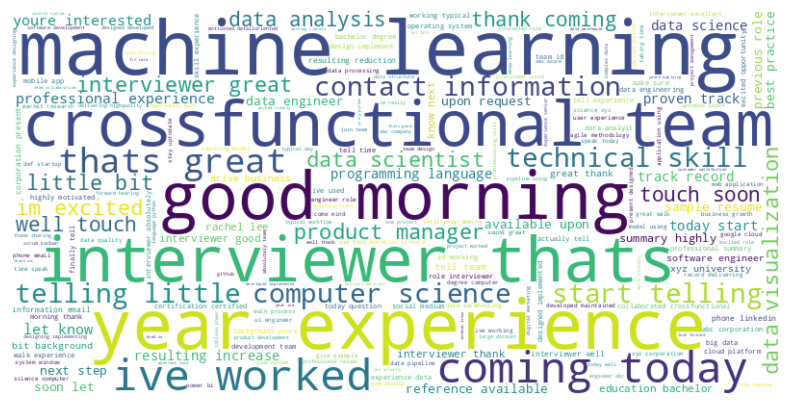

In [ ]:
!pip install wordcloud matplotlib

import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Join all the cleaned text into a single string
all_text = " ".join(df['cleaned_text'].dropna())

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

# Save the word cloud image
output_image_path = '/content/drive/MyDrive/Dissertation/wordcloud_output.png'
wordcloud.to_file(output_image_path)

print(f"Word cloud image saved to {output_image_path}")

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') # Hide the axes
plt.show()


In [ ]:


from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Load the processed dataset
processed_data_path = '/content/drive/MyDrive/Dissertation/processed_data.csv'
df_processed = pd.read_csv(processed_data_path)

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Apply LabelEncoder to 'Role', 'extracted_experience_level', 'extracted_education_level' columns
df_processed['Role_encoded'] = label_encoder.fit_transform(df_processed['Role'])
df_processed['extracted_experience_level_encoded'] = label_encoder.fit_transform(df_processed['extracted_experience_level'])
df_processed['extracted_education_level_encoded'] = label_encoder.fit_transform(df_processed['extracted_education_level'])


# Create 'label' column by mapping 'decision'
df_processed['label'] = df_processed['decision'].map({'select': 1, 'reject': 0})

# Save the updated dataset with new columns
output_updated_path = '/content/drive/MyDrive/Dissertation/processed_data_with_labels.csv'
df_processed.to_csv(output_updated_path, index=False)

print(f"\nUpdated processed data saved to {output_updated_path}")

# Display the head of the updated DataFrame to verify new columns
print("\nHead of the updated DataFrame:")
print(df_processed[['Role', 'Role_encoded', 'extracted_experience_level', 'extracted_experience_level_encoded', 'extracted_education_level', 'extracted_education_level_encoded', 'decision', 'label']].head())




Updated processed data saved to /content/drive/MyDrive/Dissertation/processed_data_with_labels.csv

Head of the updated DataFrame:
                         Role  Role_encoded extracted_experience_level  \
0       E-commerce Specialist            17                Senior/Lead   
1  Human Resources Specialist            22                Senior/Lead   
2       E-commerce Specialist            17                Senior/Lead   
3       E-commerce Specialist            17                Senior/Lead   
4        Mobile App Developer            25                Senior/Lead   

   extracted_experience_level_encoded extracted_education_level  \
0                                   1                Bachelor's   
1                                   1                Bachelor's   
2                                   1                Bachelor's   
3                                   1                Bachelor's   
4                                   1                Bachelor's   

   extracted_educati

In [ ]:


#  path to your processed file
processed_file_path = '/content/drive/MyDrive/Dissertation/processed_data_with_labels.csv'

# Read the processed dataset
df_processed = pd.read_csv(processed_file_path)

# Get the number of rows
num_rows_processed = df_processed.shape[0]
print(f"Number of rows in processed_data_with_labels.csv: {num_rows_processed}")

# Get the number of columns
num_cols_processed = df_processed.shape[1]
print(f"Number of columns in processed_data_with_labels.csv: {num_cols_processed}")

# Get the names of the columns
col_names_processed = df_processed.columns.tolist()
print(f"Column names in processed_data_with_labels.csv: {col_names_processed}")

Number of rows in processed_data_with_labels.csv: 7504
Number of columns in processed_data_with_labels.csv: 515
Column names in processed_data_with_labels.csv: ['ID', 'Name', 'Role', 'Transcript', 'Resume', 'decision', 'Reason_for_decision', 'Job_Description', 'cleaned_text', 'abc', 'ability', 'able', 'absolutely', 'accuracy', 'achievement', 'across', 'actually', 'ad', 'address', 'administration', 'administrator', 'agile', 'ah', 'ai', 'algorithm', 'also', 'always', 'analysis', 'analyst', 'analytics', 'analyze', 'apache', 'api', 'apis', 'app', 'application', 'apply', 'applying', 'appreciate', 'approach', 'architect', 'architecture', 'area', 'audience', 'automation', 'available', 'award', 'aws', 'azure', 'bachelor', 'background', 'based', 'believe', 'best', 'bi', 'big', 'bit', 'blockchain', 'blog', 'build', 'building', 'built', 'business', 'campaign', 'candidate', 'case', 'certification', 'certified', 'challenge', 'challenging', 'cicd', 'clear', 'client', 'closely', 'cloud', 'cloudbased'

Summary Statistics

In [ ]:

# Calculate summary statistics for the specified columns
summary_stats = df_processed[['Role_encoded', 'extracted_experience_level_encoded', 'extracted_education_level_encoded', 'label']].describe()

print("\nSummary Statistics:")
summary_stats


Summary Statistics:


,Role_encoded,extracted_experience_level_encoded,extracted_education_level_encoded,label
count,7504.000000,7504.000000,7504.000000,7504.000000
mean,20.335954,0.577292,1.441898,0.481743
std,12.035788,0.494023,0.585336,0.499700
min,0.000000,0.000000,0.000000,0.000000
25%,11.000000,0.000000,1.000000,0.000000
50%,18.000000,1.000000,1.000000,0.000000
75%,32.000000,1.000000,2.000000,1.000000
max,44.000000,1.000000,3.000000,1.000000



Distribution of 'label' (0: rejected, 1: selected):
label
0    3889
1    3615
Name: count, dtype: int64


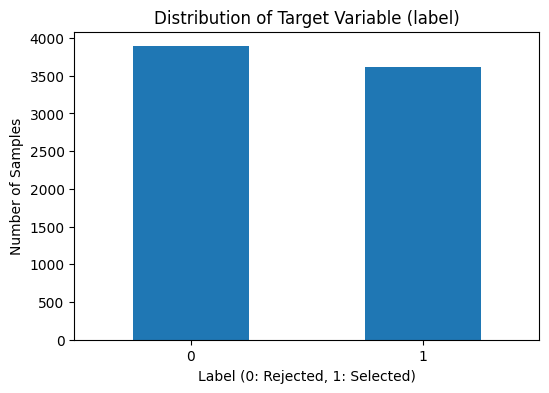

In [ ]:
import matplotlib.pyplot as plt # Import matplotlib.pyplot

# Load the dataset with labels
labeled_data_path = '/content/drive/MyDrive/Dissertation/processed_data_with_labels.csv'
df_labeled = pd.read_csv(labeled_data_path)

# Check the balance of the target variable 'label'
label_counts = df_labeled['label'].value_counts()
print("\nDistribution of 'label' (0: rejected, 1: selected):")
print(label_counts)

# Visualize the distribution using a bar chart
plt.figure(figsize=(6, 4))
label_counts.plot(kind='bar')
plt.title('Distribution of Target Variable (label)')
plt.xlabel('Label (0: Rejected, 1: Selected)')
plt.ylabel('Number of Samples')
plt.xticks(rotation=0) # Keep labels horizontal
plt.show()


Bias Analysis: Role vs. Label (Normalized Counts)
label                                0         1
Role                                            
AI Engineer                   0.272727  0.727273
AI Researcher                 0.520000  0.480000
AR/VR Developer               0.536232  0.463768
Blockchain Developer          0.488987  0.511013
Business Analyst              0.505102  0.494898
Cloud Architect               0.487903  0.512097
Cloud Engineer                0.612440  0.387560
Content Writer                0.611940  0.388060
Cybersecurity Analyst         0.497738  0.502262
Cybersecurity Specialist      0.714286  0.285714
Data Analyst                  0.492308  0.507692
Data Architect                0.533632  0.466368
Data Engineer                 0.546539  0.453461
Data Scientist                0.477273  0.522727
Database Administrator        0.562212  0.437788
DevOps Engineer               0.497908  0.502092
Digital Marketing Specialist  0.490909  0.509091
E-commerce Special

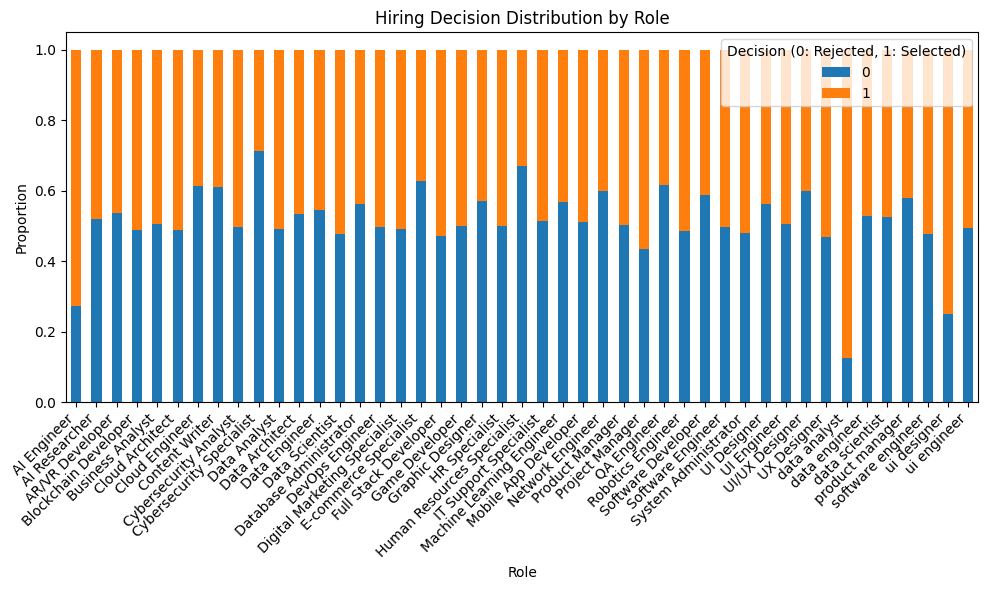

In [ ]:


# Load the dataset with labels
labeled_data_path = '/content/drive/MyDrive/Dissertation/processed_data_with_labels.csv'
df_labeled = pd.read_csv(labeled_data_path)

# Analyze bias by Role and label
print("\nBias Analysis: Role vs. Label (Normalized Counts)")
role_bias = df_labeled.groupby('Role')['label'].value_counts(normalize=True).unstack().fillna(0)
print(role_bias)

# Analyze bias by Reason_for_decision and label
print("\nBias Analysis: Reason_for_decision vs. Label (Normalized Counts)")
# Ensure Reason_for_decision column exists and handle potential missing values
if 'Reason_for_decision' in df_labeled.columns:
  reason_bias = df_labeled.groupby('Reason_for_decision')['label'].value_counts(normalize=True).unstack().fillna(0)
  print(reason_bias)
else:
  print("\n'Reason_for_decision' column not found in the dataset.")
  reason_bias = None

# Visualize bias by Role and label
if not role_bias.empty:
  print("\nVisualizing Bias by Role")
  role_bias.plot(kind='bar', stacked=True, figsize=(10, 6))
  plt.title('Hiring Decision Distribution by Role')
  plt.xlabel('Role')
  plt.ylabel('Proportion')
  plt.xticks(rotation=45, ha='right')
  plt.legend(title='Decision (0: Rejected, 1: Selected)')
  plt.tight_layout()
  plt.show()
else:
  print("\nNo data to visualize bias by Role.")


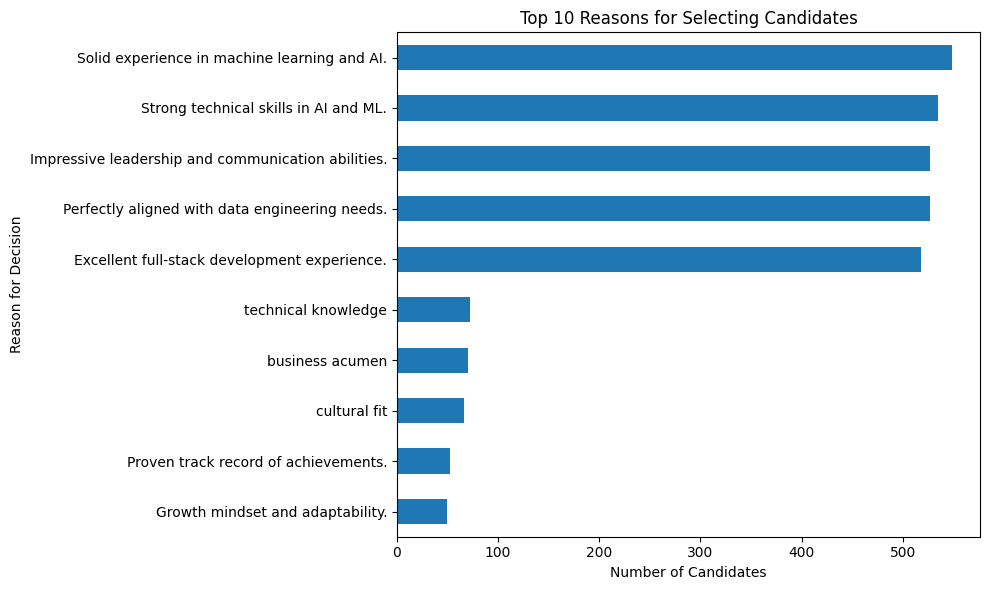

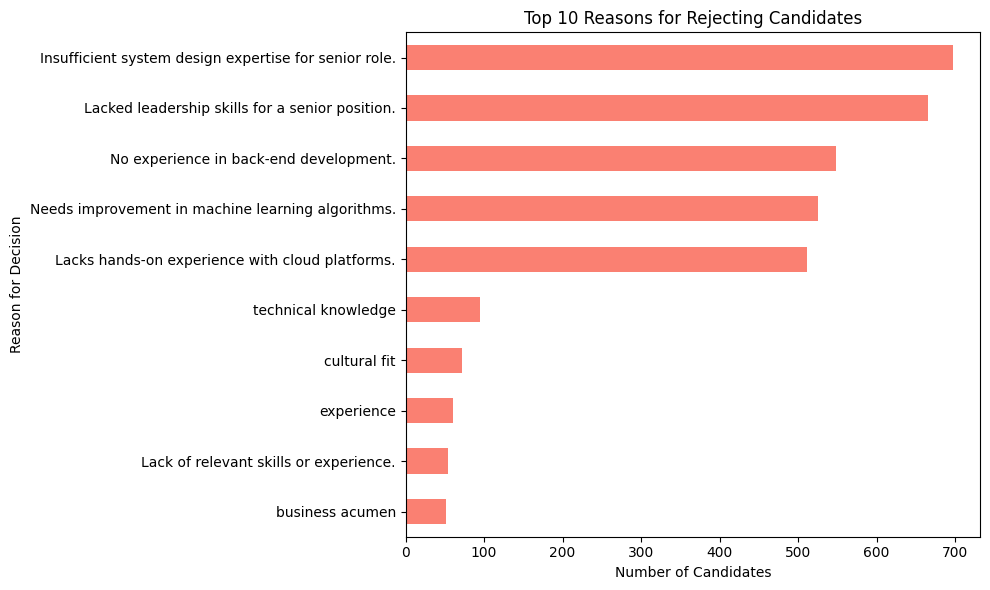

In [ ]:


# Load the dataset
labeled_data_path = '/content/drive/MyDrive/Dissertation/processed_data_with_labels.csv'
df_labeled = pd.read_csv(labeled_data_path)

# Filter data into selected and rejected subsets
df_selected = df_labeled[df_labeled['label'] == 1].copy()
df_rejected = df_labeled[df_labeled['label'] == 0].copy()

# Find top 10 reasons for selected candidates
if 'Reason_for_decision' in df_selected.columns:
  top_reasons_selected = df_selected['Reason_for_decision'].value_counts().nlargest(10)

  # Visualize top reasons for selected candidates
  plt.figure(figsize=(10, 6))
  top_reasons_selected.sort_values().plot(kind='barh')
  plt.title('Top 10 Reasons for Selecting Candidates')
  plt.xlabel('Number of Candidates')
  plt.ylabel('Reason for Decision')
  plt.tight_layout()
  plt.show()
else:
  print("\n'Reason_for_decision' column not found in the selected candidates data.")


# Find top 10 reasons for rejected candidates
if 'Reason_for_decision' in df_rejected.columns:
  top_reasons_rejected = df_rejected['Reason_for_decision'].value_counts().nlargest(10)

  # Visualize top reasons for rejected candidates
  plt.figure(figsize=(10, 6))
  top_reasons_rejected.sort_values().plot(kind='barh', color='salmon')
  plt.title('Top 10 Reasons for Rejecting Candidates')
  plt.xlabel('Number of Candidates')
  plt.ylabel('Reason for Decision')
  plt.tight_layout()
  plt.show()
else:
  print("\n'Reason_for_decision' column not found in the rejected candidates data.")


Distribution of 'label' (0: rejected, 1: selected):
label
0    3889
1    3615
Name: count, dtype: int64


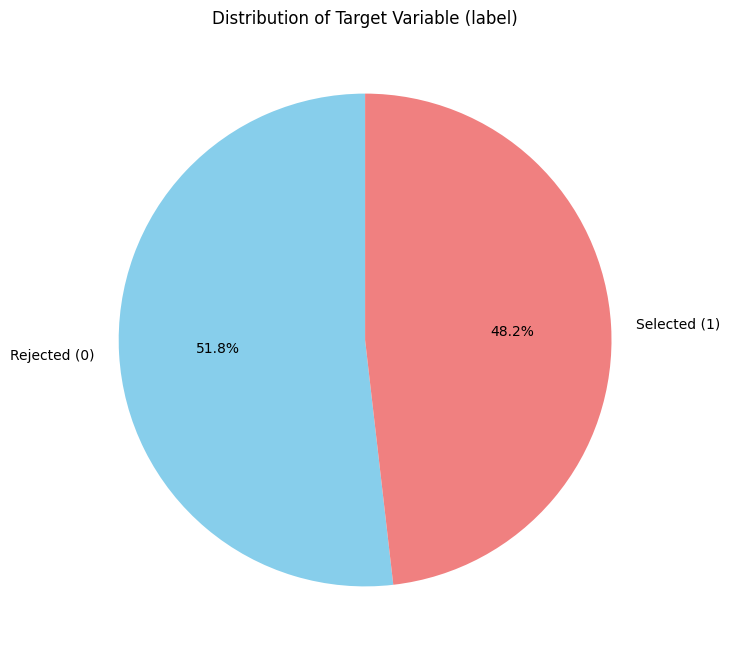

In [ ]:
import matplotlib.pyplot as plt # Import matplotlib.pyplot
import pandas as pd # Import pandas to read the data

# Load the dataset with labels
labeled_data_path = '/content/drive/MyDrive/Dissertation/processed_data_with_labels.csv'
df_labeled = pd.read_csv(labeled_data_path)

# Check the balance of the target variable 'label' and define label_counts
label_counts = df_labeled['label'].value_counts()
print("\nDistribution of 'label' (0: rejected, 1: selected):")
print(label_counts)

# Generate and display the pie chart
plt.figure(figsize=(8, 8))
label_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'], labels=['Rejected (0)', 'Selected (1)'])
plt.title('Distribution of Target Variable (label)')
plt.ylabel('') # Remove default y-label for pie chart
plt.show()

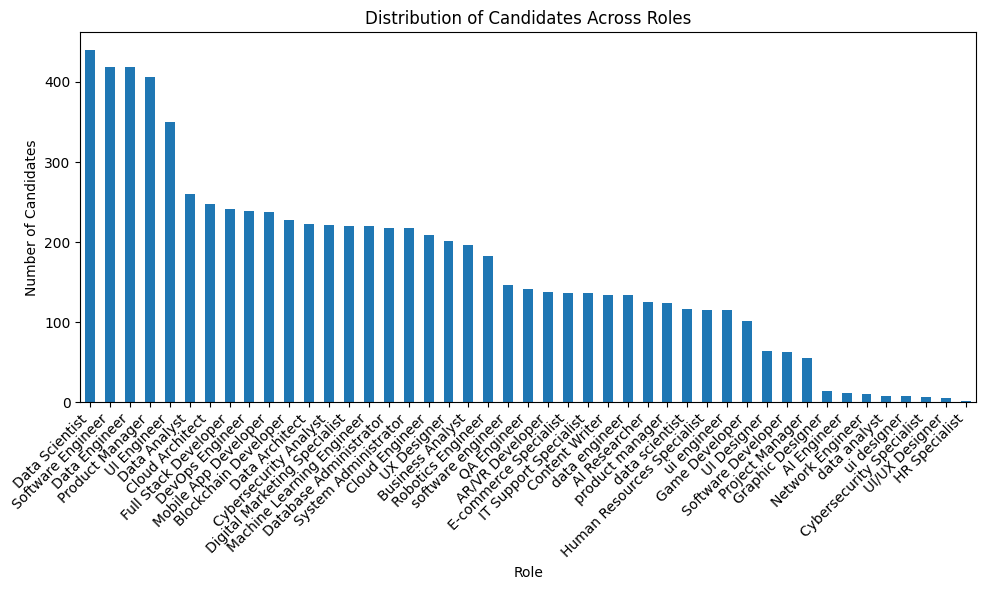

In [ ]:

# Count the occurrences of each unique value in the 'Role' column
role_distribution = df_labeled['Role'].value_counts()

# Visualize the distribution of roles using a bar chart
plt.figure(figsize=(10, 6))
role_distribution.plot(kind='bar')
plt.title('Distribution of Candidates Across Roles')
plt.xlabel('Role')
plt.ylabel('Number of Candidates')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Bias Analysis: extracted_experience_level vs. Label (Normalized Counts)
label                              0         1
extracted_experience_level                    
Entry-Level/Junior          0.509773  0.490227
Senior/Lead                 0.524469  0.475531

Visualizing Bias by Extracted Experience Level


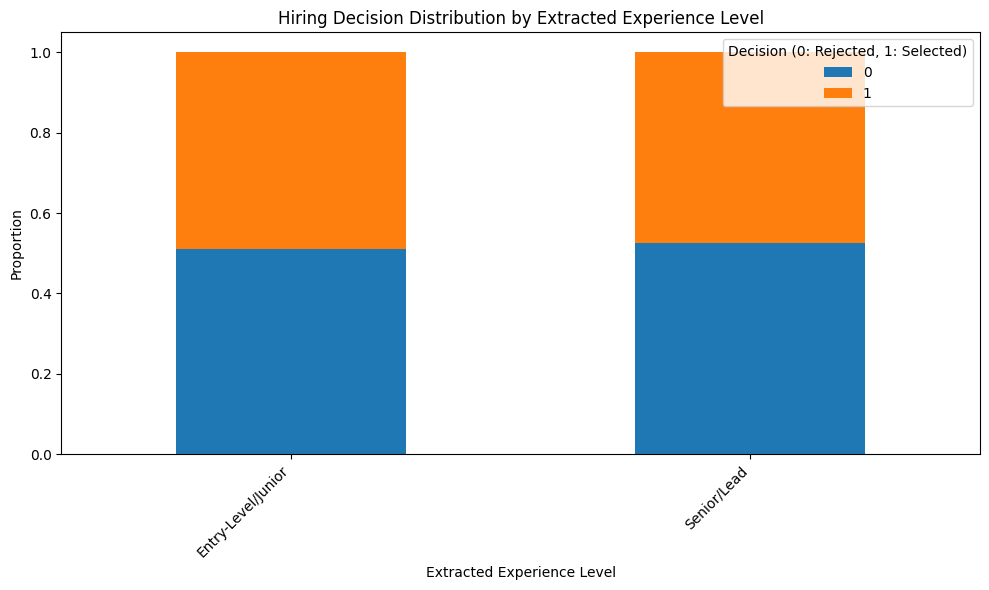

In [ ]:

# Analyze bias by extracted_experience_level and label
print("\nBias Analysis: extracted_experience_level vs. Label (Normalized Counts)")
experience_bias = df_labeled.groupby('extracted_experience_level')['label'].value_counts(normalize=True).unstack().fillna(0)
print(experience_bias)

# Visualize bias by extracted_experience_level and label
if not experience_bias.empty:
  print("\nVisualizing Bias by Extracted Experience Level")
  experience_bias.plot(kind='bar', stacked=True, figsize=(10, 6))
  plt.title('Hiring Decision Distribution by Extracted Experience Level')
  plt.xlabel('Extracted Experience Level')
  plt.ylabel('Proportion')
  plt.xticks(rotation=45, ha='right')
  plt.legend(title='Decision (0: Rejected, 1: Selected)')
  plt.tight_layout()
  plt.show()
else:
  print("\nNo data to visualize bias by Extracted Experience Level.")


Bias Analysis: extracted_education_level vs. Label (Normalized Counts)
label                             0         1
extracted_education_level                    
Associate's/College        0.422222  0.577778
Bachelor's                 0.530252  0.469748
Master's                   0.502380  0.497620
PhD                        0.501587  0.498413

Visualizing Bias by Extracted Education Level


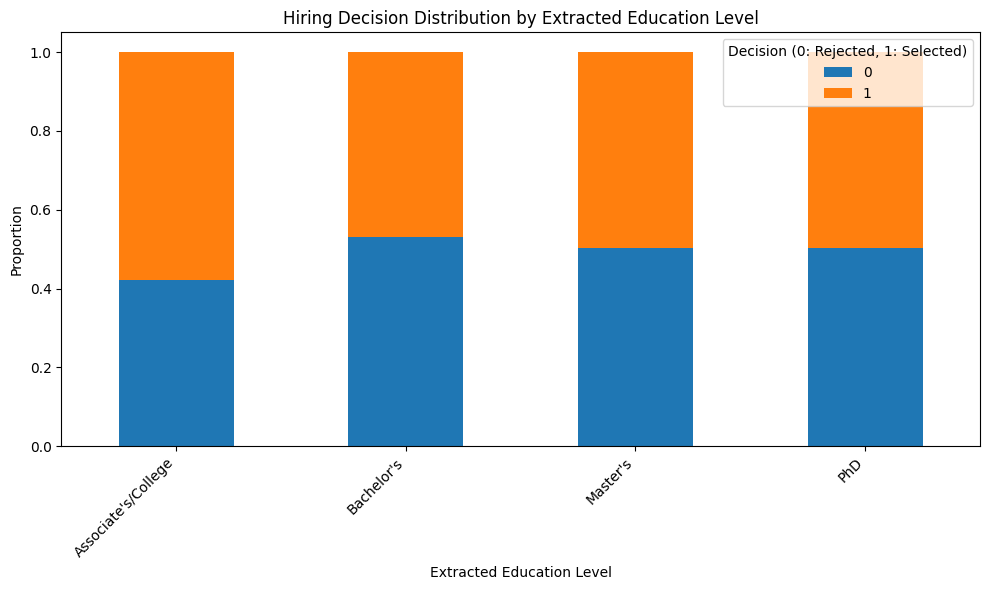

In [ ]:


import matplotlib.pyplot as plt
import pandas as pd

# Analyze bias by extracted_education_level and label
print("\nBias Analysis: extracted_education_level vs. Label (Normalized Counts)")
education_bias = df_labeled.groupby('extracted_education_level')['label'].value_counts(normalize=True).unstack().fillna(0)
print(education_bias)

# Visualize bias by extracted_education_level and label
if not education_bias.empty:
  print("\nVisualizing Bias by Extracted Education Level")
  education_bias.plot(kind='bar', stacked=True, figsize=(10, 6))
  plt.title('Hiring Decision Distribution by Extracted Education Level')
  plt.xlabel('Extracted Education Level')
  plt.ylabel('Proportion')
  plt.xticks(rotation=45, ha='right')
  plt.legend(title='Decision (0: Rejected, 1: Selected)')
  plt.tight_layout()
  plt.show()
else:
  print("\nNo data to visualize bias by Extracted Education Level.")



Count of Candidates by Education Level:
extracted_education_level
Bachelor's             4413
Master's               2731
PhD                     315
Associate's/College      45
Name: count, dtype: int64


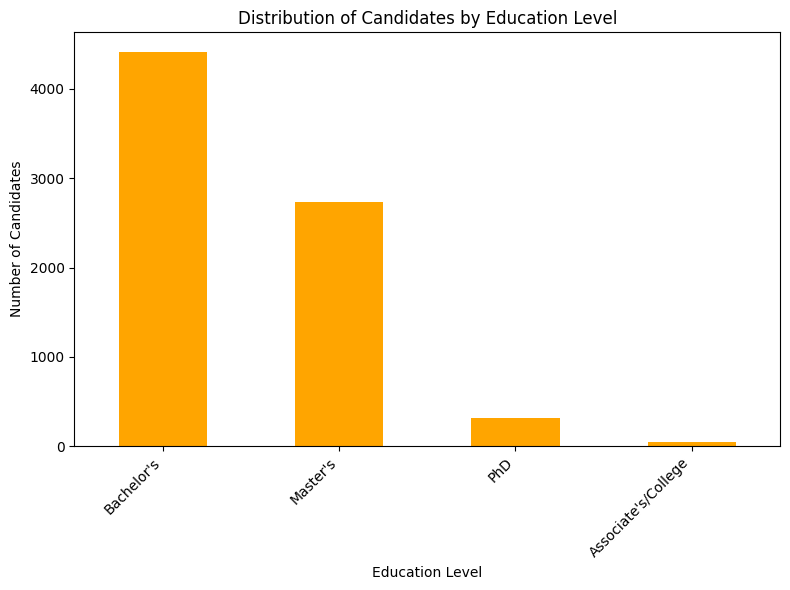


Count of Candidates by Experience Level:
extracted_experience_level
Senior/Lead           4332
Entry-Level/Junior    3172
Name: count, dtype: int64


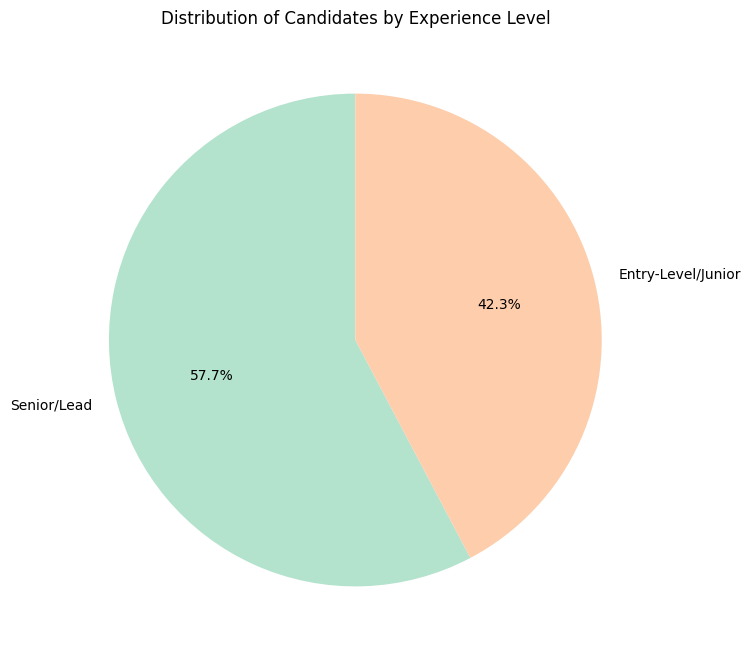

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the labeled dataset
labeled_data_path = '/content/drive/MyDrive/Dissertation/processed_data_with_labels.csv'
df_labeled = pd.read_csv(labeled_data_path)

# -----------------------------
# 1. Distribution of Extracted Education Levels (Bar Chart)
# -----------------------------
education_counts = df_labeled['extracted_education_level'].value_counts()
print("\nCount of Candidates by Education Level:")
print(education_counts)

plt.figure(figsize=(8, 6))
education_counts.plot(kind='bar', color='orange')
plt.title('Distribution of Candidates by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Number of Candidates')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# -----------------------------
# 2. Distribution of Extracted Experience Levels (Pie Chart)
# -----------------------------
experience_counts = df_labeled['extracted_experience_level'].value_counts()
print("\nCount of Candidates by Experience Level:")
print(experience_counts)

plt.figure(figsize=(8, 8))
experience_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90,
                       colors=plt.cm.Pastel2.colors, ylabel='')
plt.title('Distribution of Candidates by Experience Level')
plt.show()


Processed dataset loaded successfully.

Identified 502 TF-IDF features.

Pearson Correlation with 'label' (Top 20 features by absolute correlation):
impressive       0.216817
excellent        0.199658
senior           0.179793
dont             0.148729
okay             0.128183
position         0.115309
think            0.108916
believe          0.105665
strong           0.097927
ability          0.096235
expertise        0.092356
sure             0.090724
communication    0.088748
see              0.087378
really           0.085368
improvement      0.083122
good             0.079048
coming           0.076449
know             0.075174
absolutely       0.072620
dtype: float64


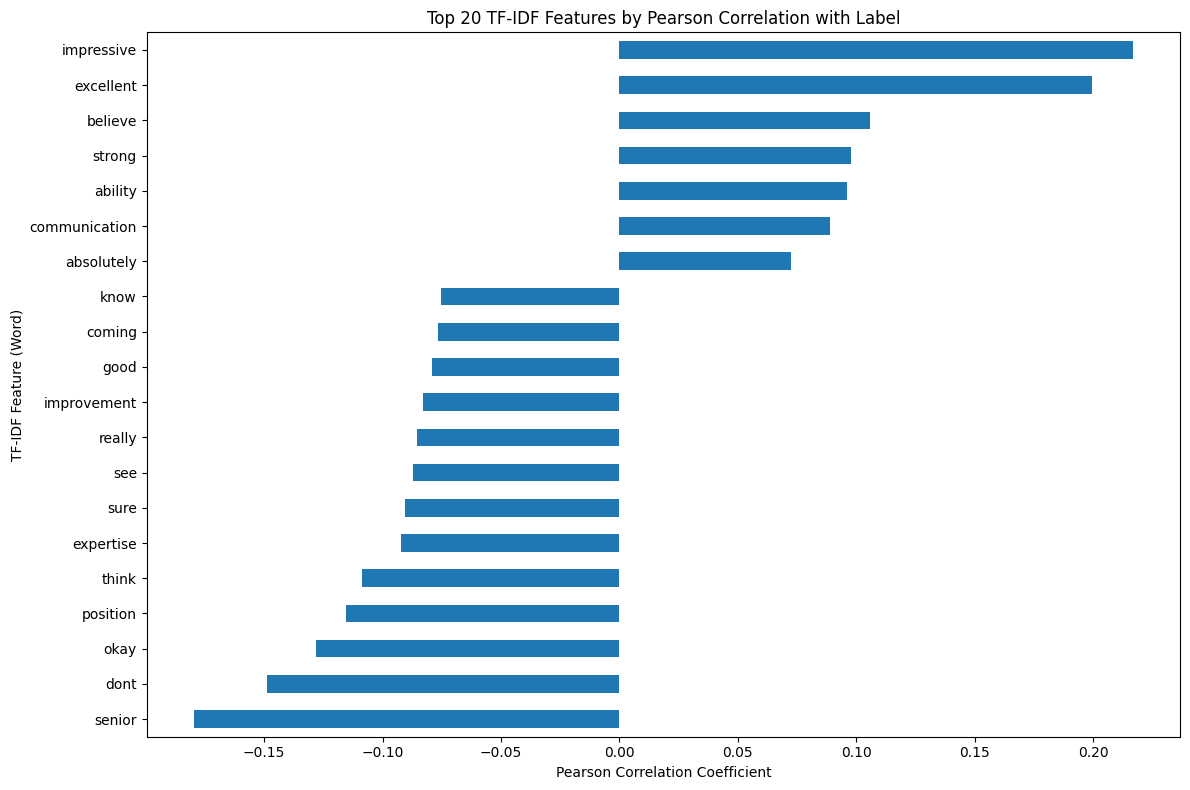

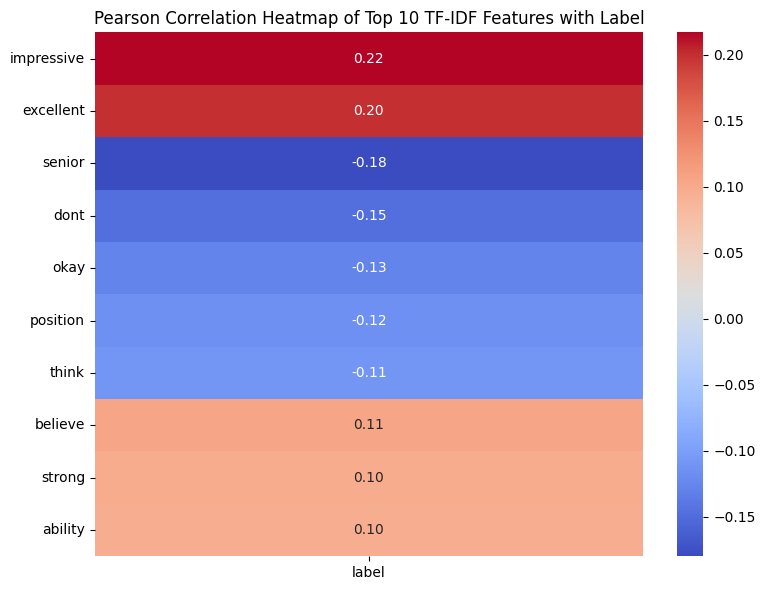

In [ ]:

import pandas as pd # Import pandas here to make pd available
import matplotlib.pyplot as plt # Import matplotlib.pyplot
import seaborn as sns # Import seaborn
from sklearn.feature_extraction.text import TfidfVectorizer # Import TfidfVectorizer

# Ensure the processed dataset with TF-IDF features and labels is loaded
labeled_data_path = '/content/drive/MyDrive/Dissertation/processed_data_with_labels.csv'
try:
    df_labeled = pd.read_csv(labeled_data_path)
    print("Processed dataset loaded successfully.")
except FileNotFoundError:
    print(f"Error: The file '{labeled_data_path}' was not found.")

    exit()





non_tfidf_numeric_cols = ['Role_encoded', 'label']

# Identify all numeric columns in the dataframe
all_numeric_cols = df_labeled.select_dtypes(include=['number']).columns

# Filter out the non-TF-IDF numeric columns to get the TF-IDF feature columns
tfidf_feature_cols = [col for col in all_numeric_cols if col not in non_tfidf_numeric_cols]

if not tfidf_feature_cols:
    print("Error: No TF-IDF feature columns found in the DataFrame.")

    exit()

print(f"\nIdentified {len(tfidf_feature_cols)} TF-IDF features.")



# Calculate Pearson Correlation between TF-IDF features and the 'label' column
correlation_with_label = df_labeled[tfidf_feature_cols].corrwith(df_labeled['label'])

# Sort the correlation values by absolute value in descending order
sorted_correlations = correlation_with_label.abs().sort_values(ascending=False)

print("\nPearson Correlation with 'label' (Top 20 features by absolute correlation):")
print(sorted_correlations.head(20))

# Get the actual correlation values for the top features
top_features = sorted_correlations.index
top_feature_correlations = correlation_with_label[top_features]

# Visualize the top features with the highest correlation
num_top_features_to_plot = 20

if len(top_feature_correlations) > num_top_features_to_plot:
    features_to_plot = top_feature_correlations.head(num_top_features_to_plot)
else:
    features_to_plot = top_feature_correlations

plt.figure(figsize=(12, 8))
features_to_plot.sort_values().plot(kind='barh')
plt.title(f'Top {len(features_to_plot)} TF-IDF Features by Pearson Correlation with Label')
plt.xlabel('Pearson Correlation Coefficient')
plt.ylabel('TF-IDF Feature (Word)')
plt.tight_layout()
plt.show()


num_features_for_heatmap = 10
if len(top_features) >= num_features_for_heatmap:
    # Correctly select the top feature names for the heatmap
    features_for_heatmap = top_features[:num_features_for_heatmap].tolist()

    # Ensure these features exist in the DataFrame before proceeding
    if set(features_for_heatmap).issubset(df_labeled.columns):
        correlation_matrix_subset = df_labeled[features_for_heatmap + ['label']].corr()

        plt.figure(figsize=(8, 6))
        sns.heatmap(correlation_matrix_subset[['label']].drop('label'), annot=True, cmap='coolwarm', fmt=".2f")
        plt.title(f'Pearson Correlation Heatmap of Top {num_features_for_heatmap} TF-IDF Features with Label')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()
    else:
        print(f"\nError: Some of the selected top TF-IDF features for heatmap ({features_for_heatmap}) are not in the DataFrame columns.")
else:
    print(f"\nNot enough TF-IDF features ({len(tfidf_feature_cols)}) to generate a heatmap for {num_features_for_heatmap} features.")

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd

# Ensure the processed dataset with TF-IDF features and labels is loaded
labeled_data_path = '/content/drive/MyDrive/Dissertation/processed_data_with_labels.csv'
try:
    df_labeled = pd.read_csv(labeled_data_path)
    print("Processed dataset loaded successfully for feature selection and modeling.")
except FileNotFoundError:
    print(f"Error: The file '{labeled_data_path}' was not found. Cannot proceed with modeling.")
    exit()

# --- Feature Selection ---


# Identify TF-IDF features again
non_tfidf_numeric_cols = ['Role_encoded', 'label','extracted_experience_level_encoded', 'extracted_education_level_encoded']
all_numeric_cols = df_labeled.select_dtypes(include=['number']).columns
tfidf_feature_cols = [col for col in all_numeric_cols if col not in non_tfidf_numeric_cols]

if not tfidf_feature_cols:
    print("Error: No TF-IDF feature columns found for correlation analysis.")
    exit()

correlation_with_label = df_labeled[tfidf_feature_cols].corrwith(df_labeled['label'])
sorted_correlations = correlation_with_label.abs().sort_values(ascending=False)

# Select the top 20 TF-IDF feature names
top_20_tfidf_features = sorted_correlations.head(20).index.tolist()


additional_relevant_features = []

# Ensure features from additional_relevant_features are present in the dataframe
additional_relevant_features = [
    feat for feat in additional_relevant_features if feat in df_labeled.columns
]
if not additional_relevant_features:
    print("Warning: No additional relevant features found in the DataFrame based on your list.")



# Identify numerical features (excluding label and Role_encoded itself initially)
other_numeric_cols = [col for col in all_numeric_cols if col not in non_tfidf_numeric_cols and col not in tfidf_feature_cols]

# Calculate correlation of other numeric features with the label
other_numeric_correlations = df_labeled[other_numeric_cols].corrwith(df_labeled['label']).abs().sort_values(ascending=False)

# Select numerical features with correlation above a certain threshold (e.g., 0.1)
# Adjust threshold based on your data
strong_corr_numeric_features = other_numeric_correlations[other_numeric_correlations > 0.1].index.tolist()

# Always include 'Role_encoded' as it's identified as important
important_numerical_features =  ['Role_encoded'] + strong_corr_numeric_features

# Combine all selected features, removing duplicates
selected_features = list(set(top_20_tfidf_features + additional_relevant_features + important_numerical_features))

# Remove 'label' if it somehow got included
if 'label' in selected_features:
    selected_features.remove('label')

# Ensure all selected features are actually columns in the DataFrame
final_selected_features = [
    feat for feat in selected_features if feat in df_labeled.columns
]

print("\n--- Important Features Identified ---")
print(f"Number of initially selected features: {len(final_selected_features)}")
print("List of initially selected features:")
print(final_selected_features)


# Prepare data for modeling
X = df_labeled[final_selected_features]
y = df_labeled['label']

# Handle potential NaN or Inf values that might have crept in
X = X.replace([np.inf, -np.inf], np.nan).fillna(X.mean())


# --- Train Model and Calculate Feature Importance ---

# Split data into training and test sets (optional here, mainly for importance)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Train a Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Get feature importance
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
sorted_feature_importances = feature_importances.sort_values(ascending=False)

print("\n--- Random Forest Feature Importances ---")
print(sorted_feature_importances)

# Retain features above a certain importance threshold
# decided to keep features with importance > 0.005
importance_threshold = 0.005
important_features_rf = sorted_feature_importances[sorted_feature_importances > importance_threshold].index.tolist()

print(f"\nFeatures retained based on Random Forest importance > {importance_threshold}:")
print(important_features_rf)


# --- Apply Recursive Feature Elimination (RFE) ---

# Use Logistic Regression as the estimator for RFE
lr_model = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42) # max_iter increase for convergence

# Define the number of features to select with RFE
n_features_to_select_rfe = 30
if n_features_to_select_rfe > X.shape[1]:
    n_features_to_select_rfe = X.shape[1]
    print(f"Warning: RFE requested {n_features_to_select_rfe} features, but only {X.shape[1]} are available. Using all available features for RFE.")
elif n_features_to_select_rfe == 0:
    n_features_to_select_rfe = 1

rfe = RFE(estimator=lr_model, n_features_to_select=n_features_to_select_rfe)

# Fit RFE on the training data
rfe.fit(X_train, y_train)

# Get the RFE selected features
rfe_features_mask = rfe.support_
rfe_features = X.columns[rfe_features_mask].tolist()

print(f"\n--- Features selected by RFE (Logistic Regression, {n_features_to_select_rfe} features) ---")
print(rfe_features)


# --- Combine Feature Selection Results ---
# Combine features from RF importance and RFE selection
# We take the union of features identified by both methods
final_refined_features = list(set(important_features_rf + rfe_features))

# Ensure the final feature set is within the original set
final_refined_features = [
    feat for feat in final_refined_features if feat in X.columns
]


print("\n--- Final Refined Feature Set ---")
print(f"Number of final refined features: {len(final_refined_features)}")
print("List of final refined features:")
print(final_refined_features)

# Prepare data with the final refined features
X_refined = df_labeled[final_refined_features]
y_refined = df_labeled['label']

# Handle potential NaN/Inf again for the refined set
X_refined = X_refined.replace([np.inf, -np.inf], np.nan).fillna(X_refined.mean())


# --- Perform k-fold Cross-Validation ---

# Choose a model for cross-validation (e.g., Random Forest)
cv_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Define the number of folds for k-fold cross-validation
k_folds = 5

print(f"\n--- Performing {k_folds}-fold Cross-Validation with Random Forest ---")

# Perform cross-validation
# We'll use 'accuracy' as the scoring metric
cv_scores = cross_val_score(cv_model, X_refined, y_refined, cv=k_folds, scoring='accuracy')

print(f"Cross-validation scores (accuracy) for each fold: {cv_scores}")
print(f"Mean cross-validation accuracy: {cv_scores.mean():.4f}")
print(f"Standard deviation of cross-validation accuracy: {cv_scores.std():.4f}")


# --- Finalize and Display the Refined Feature Set ---

print("\n--- Final Refined Feature Set Contributing Most to Prediction ---")
print(f"Total features in the final set: {len(final_refined_features)}")
print("Features:")
for feature in final_refined_features:
    print(f"- {feature}")

# --- Remove Least Important Features Based on Random Forest Importance ---

importance_threshold = 0.02

# Filter out features that have importance less than the threshold
refined_features = sorted_feature_importances[sorted_feature_importances > importance_threshold].index.tolist()

print(f"\nFeatures retained based on Random Forest importance > {importance_threshold}:")
print(refined_features)

# --- Prepare Final Refined Feature Set ---
# Update the final refined features with the ones above the importance threshold
final_refined_features = refined_features

# Prepare data with the final refined features
X_refined = df_labeled[final_refined_features]
y_refined = df_labeled['label']

# Handle potential NaN/Inf again for the refined set
X_refined = X_refined.replace([np.inf, -np.inf], np.nan).fillna(X_refined.mean())

# --- Save Final Refined Feature Set ---
# Save the final refined features dataset to a CSV file
X_refined.to_csv('/content/drive/MyDrive/Dissertation/final_refined_features_dataset.csv', index=False)

# Confirm that the file is saved
print("\nFinal refined features dataset saved to 'final_refined_features_dataset.csv'.")

# can now use X_refined and y_refined to train the final model

Processed dataset loaded successfully for feature selection and modeling.

--- Important Features Identified ---
Number of initially selected features: 21
List of initially selected features:
['excellent', 'okay', 'coming', 'see', 'sure', 'communication', 'Role_encoded', 'absolutely', 'improvement', 'know', 'strong', 'expertise', 'senior', 'believe', 'ability', 'good', 'position', 'think', 'dont', 'really', 'impressive']

--- Random Forest Feature Importances ---
senior           0.099776
good             0.069693
excellent        0.065181
strong           0.055336
coming           0.052391
sure             0.050914
think            0.050518
know             0.050310
expertise        0.049371
absolutely       0.048141
Role_encoded     0.047429
position         0.047125
impressive       0.046217
communication    0.042830
improvement      0.039383
ability          0.038031
really           0.034004
okay             0.030870
dont             0.030116
believe          0.026687
see         

In [ ]:

processed_file_path = '/content/drive/MyDrive/Dissertation/final_refined_features_dataset.csv'

# Read the processed dataset
df_processed = pd.read_csv(processed_file_path)

# Get the number of rows
num_rows_processed = df_processed.shape[0]
print(f"Number of rows in final_refined_features_dataset.csv: {num_rows_processed}")

# Get the number of columns
num_cols_processed = df_processed.shape[1]
print(f"Number of columns in final_refined_features_dataset.csv: {num_cols_processed}")

# Get the names of the columns
col_names_processed = df_processed.columns.tolist()
print(f"Column names in final_refined_features_dataset.csv: {col_names_processed}")

Number of rows in final_refined_features_dataset.csv: 7504
Number of columns in final_refined_features_dataset.csv: 21
Column names in final_refined_features_dataset.csv: ['senior', 'good', 'excellent', 'strong', 'coming', 'sure', 'think', 'know', 'expertise', 'absolutely', 'Role_encoded', 'position', 'impressive', 'communication', 'improvement', 'ability', 'really', 'okay', 'dont', 'believe', 'see']


TRAINING AND TESTING MODELS

Logistic Regression Model

X_refined and y_refined loaded successfully.

Training set shape: (5628, 21)
Testing set shape: (1876, 21)

Logistic Regression model trained successfully.

--- Model Evaluation ---
Accuracy: 0.6631
Precision: 0.6730
Recall: 0.5852
F1-score: 0.6260
AUC-ROC: 0.7144

Confusion Matrix:
[[715 257]
 [375 529]]

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.74      0.69       972
           1       0.67      0.59      0.63       904

    accuracy                           0.66      1876
   macro avg       0.66      0.66      0.66      1876
weighted avg       0.66      0.66      0.66      1876



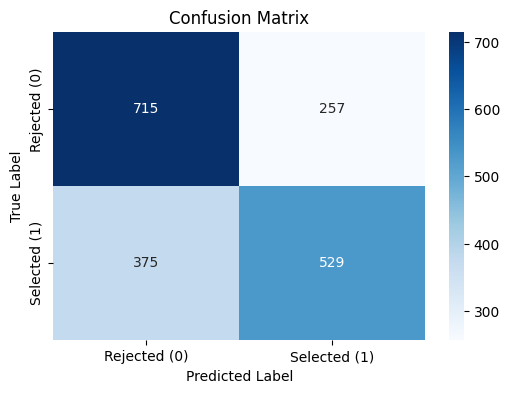


--- Cross-Validation (Using X_refined, y_refined) ---
5-Fold Cross-Validation Accuracy Scores: [0.68487675 0.66489007 0.63224517 0.60892738 0.71066667]
Mean CV Accuracy: 0.6603
Std Dev CV Accuracy: 0.0363

5-Fold Cross-Validation AUC-ROC Scores: [0.74273503 0.71147426 0.68524109 0.64946293 0.72341755]
Mean CV AUC-ROC: 0.7025
Std Dev CV AUC-ROC: 0.0324

5-Fold Cross-Validation F1-Scores: [0.64085042 0.63096112 0.61235955 0.56356877 0.66251944]
Mean CV F1-Score: 0.6221
Std Dev CV F1-Score: 0.0334


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE


import matplotlib.pyplot as plt
import seaborn as sns


try:
    X_refined = pd.read_csv('/content/drive/MyDrive/Dissertation/final_refined_features_dataset.csv')

    labeled_data_path = '/content/drive/MyDrive/Dissertation/processed_data_with_labels.csv'
    df_labeled = pd.read_csv(labeled_data_path)
    y_refined = df_labeled['label']
    print("X_refined and y_refined loaded successfully.")
except FileNotFoundError:
    print("Error: Could not load X_refined or y_refined. Please run the preceding cells to generate them.")
    exit()

# --- Prepare the Dataset ---
# X_refined and y_refined are already prepared based on the previous steps.
# Spliting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_refined, y_refined, test_size=0.25, random_state=42, stratify=y_refined
)

print(f"\nTraining set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")


# --- Train the Logistic Regression Model ---
# Initialize the Logistic Regression model
# Using a suitable solver and increase max_iter if convergence warnings occur
model = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)

# Train the model on the training data
model.fit(X_train, y_train)

print("\nLogistic Regression model trained successfully.")


# --- Evaluate the Model ---
# Make predictions on the testing data
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1] # Probability of the positive class (1)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_prob)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print("\n--- Model Evaluation ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)

# Visualize Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Rejected (0)', 'Selected (1)'], yticklabels=['Rejected (0)', 'Selected (1)'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


# --- Cross-Validation  ---
print("\n--- Cross-Validation (Using X_refined, y_refined) ---")

# Define the number of folds
k_folds = 5

# Perform cross-validation on the entire refined dataset
cv_scores_accuracy = cross_val_score(model, X_refined, y_refined, cv=k_folds, scoring='accuracy')
cv_scores_roc_auc = cross_val_score(model, X_refined, y_refined, cv=k_folds, scoring='roc_auc')
cv_scores_f1 = cross_val_score(model, X_refined, y_refined, cv=k_folds, scoring='f1')


print(f"{k_folds}-Fold Cross-Validation Accuracy Scores: {cv_scores_accuracy}")
print(f"Mean CV Accuracy: {cv_scores_accuracy.mean():.4f}")
print(f"Std Dev CV Accuracy: {cv_scores_accuracy.std():.4f}")

print(f"\n{k_folds}-Fold Cross-Validation AUC-ROC Scores: {cv_scores_roc_auc}")
print(f"Mean CV AUC-ROC: {cv_scores_roc_auc.mean():.4f}")
print(f"Std Dev CV AUC-ROC: {cv_scores_roc_auc.std():.4f}")

print(f"\n{k_folds}-Fold Cross-Validation F1-Scores: {cv_scores_f1}")
print(f"Mean CV F1-Score: {cv_scores_f1.mean():.4f}")
print(f"Std Dev CV F1-Score: {cv_scores_f1.std():.4f}")

Random Forest

X_refined and y_refined loaded successfully.

Training set shape: (5628, 21)
Testing set shape: (1876, 21)

Random Forest model trained successfully.

--- Random Forest Model Evaluation ---
Accuracy: 0.7052
Precision: 0.7122
Recall: 0.6515
F1-score: 0.6805
AUC-ROC: 0.7984

Confusion Matrix:
[[734 238]
 [315 589]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.76      0.73       972
           1       0.71      0.65      0.68       904

    accuracy                           0.71      1876
   macro avg       0.71      0.70      0.70      1876
weighted avg       0.71      0.71      0.70      1876



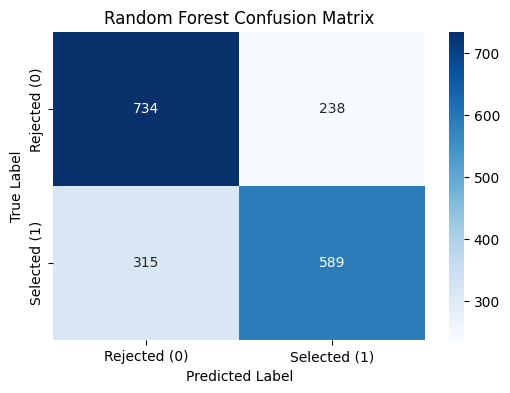


--- Random Forest Cross-Validation (Using X_refined, y_refined) ---
5-Fold Cross-Validation Accuracy Scores: [0.70019987 0.69553631 0.68687542 0.67554963 0.72933333]
Mean CV Accuracy: 0.6975
Std Dev CV Accuracy: 0.0180

5-Fold Cross-Validation AUC-ROC Scores: [0.77134601 0.79026087 0.76234324 0.75273425 0.78125873]
Mean CV AUC-ROC: 0.7716
Std Dev CV AUC-ROC: 0.0133

5-Fold Cross-Validation F1-Scores: [0.66666667 0.6647102  0.67361111 0.64786696 0.69148936]
Mean CV F1-Score: 0.6689
Std Dev CV F1-Score: 0.0141


In [ ]:


from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


try:
    X_refined = pd.read_csv('/content/drive/MyDrive/Dissertation/final_refined_features_dataset.csv')

    labeled_data_path = '/content/drive/MyDrive/Dissertation/processed_data_with_labels.csv'
    df_labeled = pd.read_csv(labeled_data_path)
    y_refined = df_labeled['label']
    print("X_refined and y_refined loaded successfully.")
except FileNotFoundError:
    print("Error: Could not load X_refined or y_refined. Please run the preceding cells to generate them.")
    exit()

# --- Prepare the Dataset ---

# Spliting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_refined, y_refined, test_size=0.25, random_state=42, stratify=y_refined
)

print(f"\nTraining set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")


# --- Train the Random Forest Model ---
# Initialize the Random Forest model
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model on the training data
model_rf.fit(X_train, y_train)

print("\nRandom Forest model trained successfully.")


# --- Evaluate the Model ---
# Make predictions on the testing data
y_pred_rf = model_rf.predict(X_test)
y_prob_rf = model_rf.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_roc_rf = roc_auc_score(y_test, y_prob_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
class_report_rf = classification_report(y_test, y_pred_rf)

print("\n--- Random Forest Model Evaluation ---")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1-score: {f1_rf:.4f}")
print(f"AUC-ROC: {auc_roc_rf:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix_rf)
print("\nClassification Report:")
print(class_report_rf)

#  Visualize Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['Rejected (0)', 'Selected (1)'], yticklabels=['Rejected (0)', 'Selected (1)'])
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


# --- Cross-Validation  ---
print("\n--- Random Forest Cross-Validation (Using X_refined, y_refined) ---")


k_folds = 5

# Perform cross-validation on the entire refined dataset
cv_scores_accuracy_rf = cross_val_score(model_rf, X_refined, y_refined, cv=k_folds, scoring='accuracy')
cv_scores_roc_auc_rf = cross_val_score(model_rf, X_refined, y_refined, cv=k_folds, scoring='roc_auc')
cv_scores_f1_rf = cross_val_score(model_rf, X_refined, y_refined, cv=k_folds, scoring='f1')


print(f"{k_folds}-Fold Cross-Validation Accuracy Scores: {cv_scores_accuracy_rf}")
print(f"Mean CV Accuracy: {cv_scores_accuracy_rf.mean():.4f}")
print(f"Std Dev CV Accuracy: {cv_scores_accuracy_rf.std():.4f}")

print(f"\n{k_folds}-Fold Cross-Validation AUC-ROC Scores: {cv_scores_roc_auc_rf}")
print(f"Mean CV AUC-ROC: {cv_scores_roc_auc_rf.mean():.4f}")
print(f"Std Dev CV AUC-ROC: {cv_scores_roc_auc_rf.std():.4f}")

print(f"\n{k_folds}-Fold Cross-Validation F1-Scores: {cv_scores_f1_rf}")
print(f"Mean CV F1-Score: {cv_scores_f1_rf.mean():.4f}")
print(f"Std Dev CV F1-Score: {cv_scores_f1_rf.std():.4f}")


XGBoost

X_refined and y_refined loaded successfully.

Training set shape: (5628, 21)
Testing set shape: (1876, 21)

XGBoost model trained successfully.

--- XGBoost Model Evaluation ---
Accuracy: 0.7111
Precision: 0.7038
Recall: 0.6914
F1-score: 0.6975
AUC-ROC: 0.7908

Confusion Matrix:
[[709 263]
 [279 625]]

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.73      0.72       972
           1       0.70      0.69      0.70       904

    accuracy                           0.71      1876
   macro avg       0.71      0.71      0.71      1876
weighted avg       0.71      0.71      0.71      1876



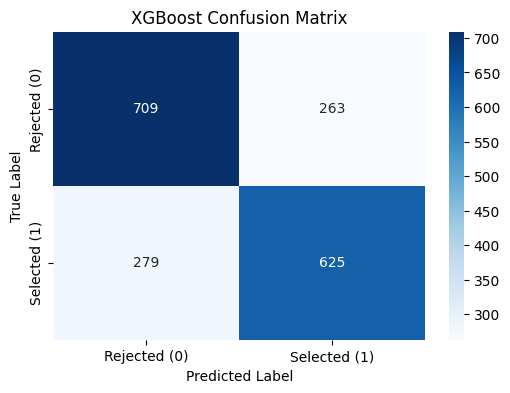


--- XGBoost Cross-Validation (Using X_refined, y_refined) ---
5-Fold Cross-Validation Accuracy Scores: [0.69153897 0.70019987 0.67288474 0.67355097 0.69933333]
Mean CV Accuracy: 0.6875
Std Dev CV Accuracy: 0.0120

5-Fold Cross-Validation AUC-ROC Scores: [0.76243835 0.77706607 0.76052011 0.74221769 0.75630818]
Mean CV AUC-ROC: 0.7597
Std Dev CV AUC-ROC: 0.0112

5-Fold Cross-Validation F1-Scores: [0.65930831 0.68531469 0.65879083 0.64697406 0.68172195]
Mean CV F1-Score: 0.6664
Std Dev CV F1-Score: 0.0147


In [ ]:
!pip install xgboost

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


try:
    X_refined = pd.read_csv('/content/drive/MyDrive/Dissertation/final_refined_features_dataset.csv')

    labeled_data_path = '/content/drive/MyDrive/Dissertation/processed_data_with_labels.csv'
    df_labeled = pd.read_csv(labeled_data_path)
    y_refined = df_labeled['label']
    print("X_refined and y_refined loaded successfully.")
except FileNotFoundError:
    print("Error: Could not load X_refined or y_refined. Please run the preceding cells to generate them.")
    exit()

# --- Prepare the Dataset ---

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_refined, y_refined, test_size=0.25, random_state=42, stratify=y_refined
)

print(f"\nTraining set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")


# --- Train the XGBOOST Model ---
# Initialize the XGBoost model

model_xgb = xgb.XGBClassifier(objective='binary:logistic', random_state=42)

# Train the model on the training data
model_xgb.fit(X_train, y_train)

print("\nXGBoost model trained successfully.")


# --- Evaluate the Model ---
# Make predictions on the testing data
y_pred_xgb = model_xgb.predict(X_test)
y_prob_xgb = model_xgb.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
auc_roc_xgb = roc_auc_score(y_test, y_prob_xgb)
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)
class_report_xgb = classification_report(y_test, y_pred_xgb)

print("\n--- XGBoost Model Evaluation ---")
print(f"Accuracy: {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall: {recall_xgb:.4f}")
print(f"F1-score: {f1_xgb:.4f}")
print(f"AUC-ROC: {auc_roc_xgb:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix_xgb)
print("\nClassification Report:")
print(class_report_xgb)

# Visualize Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', cmap='Blues', xticklabels=['Rejected (0)', 'Selected (1)'], yticklabels=['Rejected (0)', 'Selected (1)'])
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


# --- Cross-Validation---
print("\n--- XGBoost Cross-Validation (Using X_refined, y_refined) ---")

k_folds = 5

# Perform cross-validation on the entire refined dataset
cv_scores_accuracy_xgb = cross_val_score(model_xgb, X_refined, y_refined, cv=k_folds, scoring='accuracy')
cv_scores_roc_auc_xgb = cross_val_score(model_xgb, X_refined, y_refined, cv=k_folds, scoring='roc_auc')
cv_scores_f1_xgb = cross_val_score(model_xgb, X_refined, y_refined, cv=k_folds, scoring='f1')


print(f"{k_folds}-Fold Cross-Validation Accuracy Scores: {cv_scores_accuracy_xgb}")
print(f"Mean CV Accuracy: {cv_scores_accuracy_xgb.mean():.4f}")
print(f"Std Dev CV Accuracy: {cv_scores_accuracy_xgb.std():.4f}")

print(f"\n{k_folds}-Fold Cross-Validation AUC-ROC Scores: {cv_scores_roc_auc_xgb}")
print(f"Mean CV AUC-ROC: {cv_scores_roc_auc_xgb.mean():.4f}")
print(f"Std Dev CV AUC-ROC: {cv_scores_roc_auc_xgb.std():.4f}")

print(f"\n{k_folds}-Fold Cross-Validation F1-Scores: {cv_scores_f1_xgb}")
print(f"Mean CV F1-Score: {cv_scores_f1_xgb.mean():.4f}")
print(f"Std Dev CV F1-Score: {cv_scores_f1_xgb.std():.4f}")


FINE-TUNING

Logistic Regression Model

X_refined and y_refined loaded successfully for fine-tuning.

Data split for fine-tuning: Training set shape (5628, 21), Testing set shape (1876, 21)

--- Hyperparameter Tuning for Logistic Regression using GridSearchCV ---
Starting Grid Search...
Grid Search complete.

Best Hyperparameters found by GridSearchCV:
{'C': 10, 'max_iter': 200, 'solver': 'lbfgs'}

Best Logistic Regression Model:
LogisticRegression(C=10, max_iter=200, random_state=42)

--- Evaluating the Best Model on the Test Set ---
Tuned Model Accuracy: 0.6722
Tuned Model Precision: 0.6667
Tuned Model Recall: 0.6394
Tuned Model F1-score: 0.6527
Tuned Model AUC-ROC: 0.7346

Tuned Model Confusion Matrix:
[[683 289]
 [326 578]]

Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.70      0.69       972
           1       0.67      0.64      0.65       904

    accuracy                           0.67      1876
   macro avg       0.67      0.67      0.67     

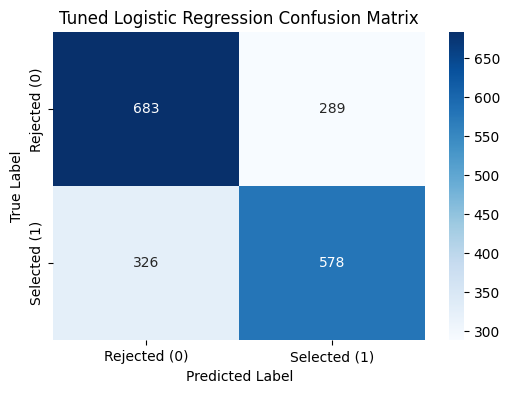

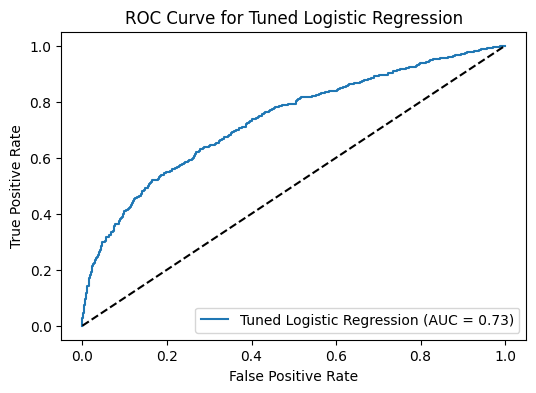


--- Comparison: Original vs. Tuned Logistic Regression ---
Metric        | Original Model | Tuned Model
----------------|----------------|--------------
Accuracy      | 0.6631       | 0.6722
Precision     | 0.6730       | 0.6667
Recall        | 0.5852       | 0.6394
F1-score      | 0.6260       | 0.6527
AUC-ROC       | 0.7144       | 0.7346
----------------|----------------|--------------


In [ ]:


from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


try:
    X_refined = pd.read_csv('/content/drive/MyDrive/Dissertation/final_refined_features_dataset.csv')

    labeled_data_path = '/content/drive/MyDrive/Dissertation/processed_data_with_labels.csv'
    df_labeled = pd.read_csv(labeled_data_path)
    y_refined = df_labeled['label']
    print("X_refined and y_refined loaded successfully for fine-tuning.")

    # Split the data for fine-tuning
    X_train, X_test, y_train, y_test = train_test_split(
        X_refined, y_refined, test_size=0.25, random_state=42, stratify=y_refined
    )
    print(f"\nData split for fine-tuning: Training set shape {X_train.shape}, Testing set shape {X_test.shape}")

except FileNotFoundError:
    print("Error: Could not load X_refined or y_refined for fine-tuning. Please run the preceding cells.")
    exit()


print("\n--- Hyperparameter Tuning for Logistic Regression using GridSearchCV ---")

# Define the parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga', 'lbfgs'],
    'max_iter': [100, 200, 300]
}

# Initialize the Logistic Regression model
log_reg = LogisticRegression(random_state=42)


# Using 'accuracy' as the scoring metric
# Use 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Perform the grid search on the training data
print("Starting Grid Search...")
grid_search.fit(X_train, y_train)
print("Grid Search complete.")

# Get the best hyperparameters and the best model
best_params = grid_search.best_params_
best_log_reg_model = grid_search.best_estimator_

print("\nBest Hyperparameters found by GridSearchCV:")
print(best_params)

print("\nBest Logistic Regression Model:")
print(best_log_reg_model)


# --- Evaluate the Best Model on the Test Set ---
print("\n--- Evaluating the Best Model on the Test Set ---")

# Make predictions with the best model
y_pred_tuned = best_log_reg_model.predict(X_test)
y_prob_tuned = best_log_reg_model.predict_proba(X_test)[:, 1]

# Calculating evaluation metrics for the tuned model
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)
auc_roc_tuned = roc_auc_score(y_test, y_prob_tuned)
conf_matrix_tuned = confusion_matrix(y_test, y_pred_tuned)
class_report_tuned = classification_report(y_test, y_pred_tuned)


print(f"Tuned Model Accuracy: {accuracy_tuned:.4f}")
print(f"Tuned Model Precision: {precision_tuned:.4f}")
print(f"Tuned Model Recall: {recall_tuned:.4f}")
print(f"Tuned Model F1-score: {f1_tuned:.4f}")
print(f"Tuned Model AUC-ROC: {auc_roc_tuned:.4f}")
print("\nTuned Model Confusion Matrix:")
print(conf_matrix_tuned)
print("\nTuned Model Classification Report:")
print(class_report_tuned)


#  Visualize Confusion Matrix for the tuned model
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_tuned, annot=True, fmt='d', cmap='Blues', xticklabels=['Rejected (0)', 'Selected (1)'], yticklabels=['Rejected (0)', 'Selected (1)'])
plt.title('Tuned Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Plot ROC Curve for the tuned model
fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_prob_tuned)
plt.figure(figsize=(6, 4))
plt.plot(fpr_tuned, tpr_tuned, label=f'Tuned Logistic Regression (AUC = {auc_roc_tuned:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Tuned Logistic Regression')
plt.legend(loc='lower right')
plt.show()


# --- Compare with Original Model  ---


print("\n--- Comparison: Original vs. Tuned Logistic Regression ---")
print(f"Metric        | Original Model | Tuned Model")
print(f"----------------|----------------|--------------")
print(f"Accuracy      | {accuracy:.4f}       | {accuracy_tuned:.4f}")
print(f"Precision     | {precision:.4f}       | {precision_tuned:.4f}")
print(f"Recall        | {recall:.4f}       | {recall_tuned:.4f}")
print(f"F1-score      | {f1:.4f}       | {f1_tuned:.4f}")
print(f"AUC-ROC       | {auc_roc:.4f}       | {auc_roc_tuned:.4f}")
print(f"----------------|----------------|--------------")


Random Forest

X_refined and y_refined loaded successfully for Random Forest fine-tuning.

Data split for Random Forest fine-tuning: Training set shape (5628, 21), Testing set shape (1876, 21)

--- Hyperparameter Tuning for Random Forest using RandomizedSearchCV ---
Starting Random Forest RandomizedSearchCV...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Random Forest RandomizedSearchCV complete.

Best Hyperparameters found by RandomizedSearchCV for Random Forest:
{'n_estimators': 500, 'min_samples_split': 20, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': False}

Best Random Forest Model:
RandomForestClassifier(bootstrap=False, min_samples_leaf=10,
                       min_samples_split=20, n_estimators=500, random_state=42)

--- Evaluating the Best Random Forest Model on the Test Set ---
Tuned Random Forest Model Accuracy: 0.7079
Tuned Random Forest Model Precision: 0.7104
Tuned Random Forest Model Recall: 0.6648
Tuned Random Forest Model F1-score:

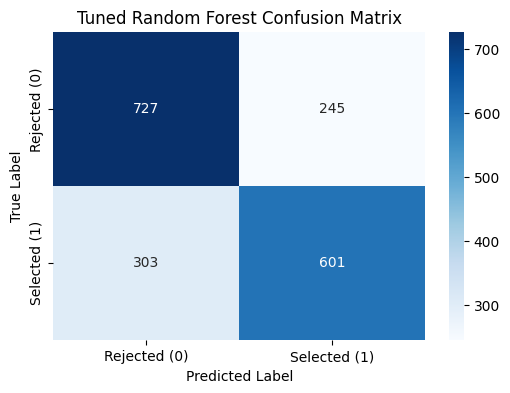

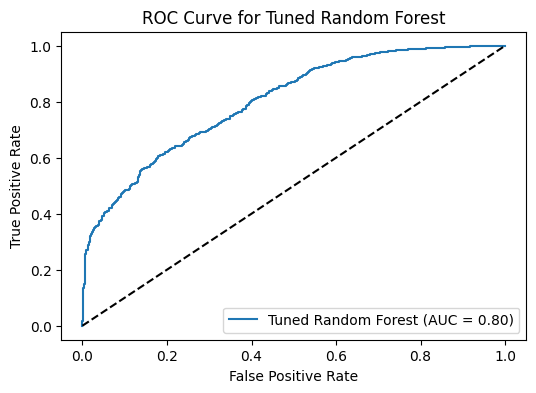


--- Comparison: Original vs. Tuned Random Forest ---
Metric        | Original RF | Tuned RF
----------------|-------------|----------
Accuracy      | 0.7052    | 0.7079
Precision     | 0.7122    | 0.7104
Recall        | 0.6515    | 0.6648
F1-score      | 0.6805    | 0.6869
AUC-ROC       | 0.7984    | 0.8024
----------------|-------------|----------


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import randint


try:
    # Load refined features and labels
    X_refined = pd.read_csv('/content/drive/MyDrive/Dissertation/final_refined_features_dataset.csv')
    labeled_data_path = '/content/drive/MyDrive/Dissertation/processed_data_with_labels.csv'
    df_labeled = pd.read_csv(labeled_data_path)
    y_refined = df_labeled['label']
    print("X_refined and y_refined loaded successfully for Random Forest fine-tuning.")

    # Handle potential NaN or Inf values in X_refined
    X_refined = X_refined.replace([np.inf, -np.inf], np.nan).fillna(X_refined.mean())

    # Split the data for fine-tuning
    X_train, X_test, y_train, y_test = train_test_split(
        X_refined, y_refined, test_size=0.25, random_state=42, stratify=y_refined
    )
    print(f"\nData split for Random Forest fine-tuning: Training set shape {X_train.shape}, Testing set shape {X_test.shape}")

except FileNotFoundError:
    print("Error: Could not load X_refined or y_refined for Random Forest fine-tuning. Please run the preceding cells.")
    exit()

print("\n--- Hyperparameter Tuning for Random Forest using RandomizedSearchCV ---")

# Define the parameter distribution for Random Forest
param_dist_rf = {
    'n_estimators': [100, 200, 500],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

# Initialize the Random Forest model
rf_model = RandomForestClassifier(random_state=42)

# Set up RandomizedSearchCV
random_search_rf = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist_rf,
    n_iter=10,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Perform the randomized search on the training data
print("Starting Random Forest RandomizedSearchCV...")
random_search_rf.fit(X_train, y_train)
print("Random Forest RandomizedSearchCV complete.")

# Get the best hyperparameters and the best model
best_params_rf = random_search_rf.best_params_
best_rf_model = random_search_rf.best_estimator_

print("\nBest Hyperparameters found by RandomizedSearchCV for Random Forest:")
print(best_params_rf)

print("\nBest Random Forest Model:")
print(best_rf_model)


# --- Evaluate the Best Random Forest Model on the Test Set ---
print("\n--- Evaluating the Best Random Forest Model on the Test Set ---")

# Make predictions with the best model
y_pred_tuned_rf = best_rf_model.predict(X_test)
y_prob_tuned_rf = best_rf_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics for the tuned model
accuracy_tuned_rf = accuracy_score(y_test, y_pred_tuned_rf)
precision_tuned_rf = precision_score(y_test, y_pred_tuned_rf)
recall_tuned_rf = recall_score(y_test, y_pred_tuned_rf)
f1_tuned_rf = f1_score(y_test, y_pred_tuned_rf)
auc_roc_tuned_rf = roc_auc_score(y_test, y_prob_tuned_rf)
conf_matrix_tuned_rf = confusion_matrix(y_test, y_pred_tuned_rf)
class_report_tuned_rf = classification_report(y_test, y_pred_tuned_rf)

# Display evaluation metrics
print(f"Tuned Random Forest Model Accuracy: {accuracy_tuned_rf:.4f}")
print(f"Tuned Random Forest Model Precision: {precision_tuned_rf:.4f}")
print(f"Tuned Random Forest Model Recall: {recall_tuned_rf:.4f}")
print(f"Tuned Random Forest Model F1-score: {f1_tuned_rf:.4f}")
print(f"Tuned Random Forest Model AUC-ROC: {auc_roc_tuned_rf:.4f}")
print("\nTuned Random Forest Model Confusion Matrix:")
print(conf_matrix_tuned_rf)
print("\nTuned Random Forest Model Classification Report:")
print(class_report_tuned_rf)


# Visualize Confusion Matrix for the tuned model
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_tuned_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['Rejected (0)', 'Selected (1)'], yticklabels=['Rejected (0)', 'Selected (1)'])
plt.title('Tuned Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#  Plot ROC Curve for the tuned model
fpr_tuned_rf, tpr_tuned_rf, _ = roc_curve(y_test, y_prob_tuned_rf)
plt.figure(figsize=(6, 4))
plt.plot(fpr_tuned_rf, tpr_tuned_rf, label=f'Tuned Random Forest (AUC = {auc_roc_tuned_rf:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Tuned Random Forest')
plt.legend(loc='lower right')
plt.show()


# --- Compare with Original Random Forest Model (Optional) ---

print("\n--- Comparison: Original vs. Tuned Random Forest ---")
print(f"Metric        | Original RF | Tuned RF")
print(f"----------------|-------------|----------")
print(f"Accuracy      | {accuracy_rf:.4f}    | {accuracy_tuned_rf:.4f}")
print(f"Precision     | {precision_rf:.4f}    | {precision_tuned_rf:.4f}")
print(f"Recall        | {recall_rf:.4f}    | {recall_tuned_rf:.4f}")
print(f"F1-score      | {f1_rf:.4f}    | {f1_tuned_rf:.4f}")
print(f"AUC-ROC       | {auc_roc_rf:.4f}    | {auc_roc_tuned_rf:.4f}")
print(f"----------------|-------------|----------")


XGBoost

X_refined and y_refined loaded successfully for XGBoost fine-tuning.

Data split for XGBoost fine-tuning: Training set shape (5628, 21), Testing set shape (1876, 21)

--- Hyperparameter Tuning for XGBoost using RandomizedSearchCV ---
Calculated scale_pos_weight: 1.08
Starting XGBoost RandomizedSearchCV...
Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [16:10:37] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost RandomizedSearchCV complete.

Best Hyperparameters found by RandomizedSearchCV for XGBoost:
{'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 10, 'max_depth': 10, 'learning_rate': 0.01, 'gamma': 0.2, 'colsample_bytree': 0.8}

Best XGBoost Model:
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.2,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=10, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
      

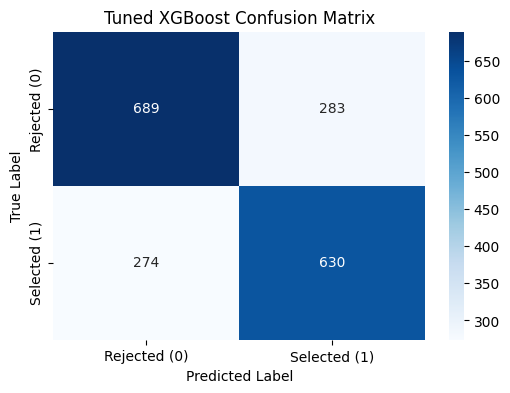

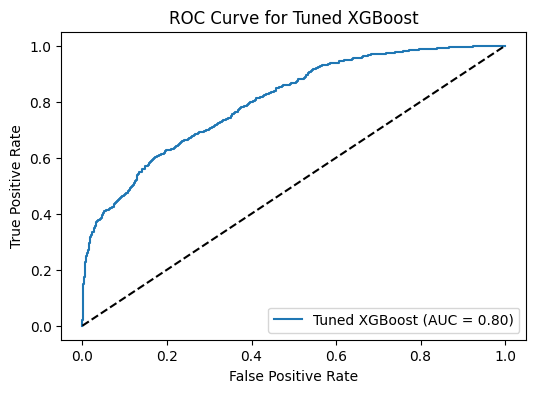


--- Comparison: Original vs. Tuned XGBoost ---
Metric        | Original XGB | Tuned XGB
----------------|--------------|----------
Accuracy      | 0.7111     | 0.7031
Precision     | 0.7038     | 0.6900
Recall        | 0.6914     | 0.6969
F1-score      | 0.6975     | 0.6935
AUC-ROC       | 0.7908     | 0.8018
----------------|--------------|----------


In [ ]:


from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb


try:
    # Load refined features and labels
    X_refined = pd.read_csv('/content/drive/MyDrive/Dissertation/final_refined_features_dataset.csv')
    labeled_data_path = '/content/drive/MyDrive/Dissertation/processed_data_with_labels.csv'
    df_labeled = pd.read_csv(labeled_data_path)
    y_refined = df_labeled['label']
    print("X_refined and y_refined loaded successfully for XGBoost fine-tuning.")

    # Handle potential NaN or Inf values in X_refined
    X_refined = X_refined.replace([np.inf, -np.inf], np.nan).fillna(X_refined.mean())

    # Split the data for fine-tuning
    X_train, X_test, y_train, y_test = train_test_split(
        X_refined, y_refined, test_size=0.25, random_state=42, stratify=y_refined
    )
    print(f"\nData split for XGBoost fine-tuning: Training set shape {X_train.shape}, Testing set shape {X_test.shape}")

except FileNotFoundError:
    print("Error: Could not load X_refined or y_refined for XGBoost fine-tuning. Please run the preceding cells.")
    exit()


print("\n--- Hyperparameter Tuning for XGBoost using RandomizedSearchCV ---")

# Define the parameter distribution for XGBoost
param_dist_xgb = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 10],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2],
    'min_child_weight': [1, 5, 10]
}

# Initialize the XGBoost model

scale_pos_weight_value = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print(f"Calculated scale_pos_weight: {scale_pos_weight_value:.2f}")


xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight_value
)

# Set up RandomizedSearchCV
random_search_xgb = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist_xgb,
    n_iter=20,  # Number of random combinations to sample
    cv=5,  # 5-fold cross-validation
    scoring='roc_auc',  # Using AUC-ROC as scoring metric for imbalanced data
    n_jobs=-1,  # Use all available cores for parallelization
    random_state=42,
    verbose=1
)

# Perform the randomized search on the training data
print("Starting XGBoost RandomizedSearchCV...")
random_search_xgb.fit(X_train, y_train)
print("XGBoost RandomizedSearchCV complete.")

# Get the best hyperparameters and the best model
best_params_xgb = random_search_xgb.best_params_
best_xgb_model = random_search_xgb.best_estimator_

print("\nBest Hyperparameters found by RandomizedSearchCV for XGBoost:")
print(best_params_xgb)

print("\nBest XGBoost Model:")
print(best_xgb_model)


# --- Evaluate the Best XGBoost Model on the Test Set ---
print("\n--- Evaluating the Best XGBoost Model on the Test Set ---")

# Make predictions with the best model
y_pred_tuned_xgb = best_xgb_model.predict(X_test)
y_prob_tuned_xgb = best_xgb_model.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics for the tuned model
accuracy_tuned_xgb = accuracy_score(y_test, y_pred_tuned_xgb)
precision_tuned_xgb = precision_score(y_test, y_pred_tuned_xgb)
recall_tuned_xgb = recall_score(y_test, y_pred_tuned_xgb)
f1_tuned_xgb = f1_score(y_test, y_pred_tuned_xgb)
auc_roc_tuned_xgb = roc_auc_score(y_test, y_prob_tuned_xgb)
conf_matrix_tuned_xgb = confusion_matrix(y_test, y_pred_tuned_xgb)
class_report_tuned_xgb = classification_report(y_test, y_pred_tuned_xgb)


# Display evaluation metrics
print(f"Tuned XGBoost Model Accuracy: {accuracy_tuned_xgb:.4f}")
print(f"Tuned XGBoost Model Precision: {precision_tuned_xgb:.4f}")
print(f"Tuned XGBoost Model Recall: {recall_tuned_xgb:.4f}")
print(f"Tuned XGBoost Model F1-score: {f1_tuned_xgb:.4f}")
print(f"Tuned XGBoost Model AUC-ROC: {auc_roc_tuned_xgb:.4f}")
print("\nTuned XGBoost Model Confusion Matrix:")
print(conf_matrix_tuned_xgb)
print("\nTuned XGBoost Model Classification Report:")
print(class_report_tuned_xgb)


plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_tuned_xgb, annot=True, fmt='d', cmap='Blues', xticklabels=['Rejected (0)', 'Selected (1)'], yticklabels=['Rejected (0)', 'Selected (1)'])
plt.title('Tuned XGBoost Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


fpr_tuned_xgb, tpr_tuned_xgb, _ = roc_curve(y_test, y_prob_tuned_xgb)
plt.figure(figsize=(6, 4))
plt.plot(fpr_tuned_xgb, tpr_tuned_xgb, label=f'Tuned XGBoost (AUC = {auc_roc_tuned_xgb:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Tuned XGBoost')
plt.legend(loc='lower right')
plt.show()


# --- Compare with Original XGBoost Model  ---

print("\n--- Comparison: Original vs. Tuned XGBoost ---")
print(f"Metric        | Original XGB | Tuned XGB")
print(f"----------------|--------------|----------")
print(f"Accuracy      | {accuracy_xgb:.4f}     | {accuracy_tuned_xgb:.4f}")
print(f"Precision     | {precision_xgb:.4f}     | {precision_tuned_xgb:.4f}")
print(f"Recall        | {recall_xgb:.4f}     | {recall_tuned_xgb:.4f}")
print(f"F1-score      | {f1_xgb:.4f}     | {f1_tuned_xgb:.4f}")
print(f"AUC-ROC       | {auc_roc_xgb:.4f}     | {auc_roc_tuned_xgb:.4f}")
print(f"----------------|--------------|----------")



**BIAS DETECTION**

In [ ]:
# --- Install Fairness Libraries ---
!pip install fairlearn
!pip install aif360

**ROLE ( LOGISTIC REGRESSION ,RANDOM FOREST ,XGBOOST)**

Processed dataset loaded successfully for fairness evaluation.

Data split for Fairness Evaluation:
Training set shape (features): (5628, 21)
Testing set shape (features): (1876, 21)
Training set shape (labels): (5628,)
Testing set shape (labels): (1876,)
Training set shape (sensitive attribute): (5628,)
Testing set shape (sensitive attribute): (1876,)

--- Training Models for Fairness Evaluation ---
Tuned Logistic Regression model not found or is None. Training a new one with default params.
Tuned Random Forest model not found or is None. Training a new one with default params.
Tuned XGBoost model not found or is None. Training a new one with default params.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [14:48:47] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Models trained on fairness evaluation split.

--- Fairness Evaluation using Fairlearn ---

Fairness Metrics for Logistic Regression:
Metrics by group:
                              selection_rate  true_positive_rate  \
Role                                                               
AI Engineer                         0.800000            1.000000   
AI Researcher                       0.230769            0.352941   
AR/VR Developer                     0.214286            0.473684   
Blockchain Developer                0.309091            0.444444   
Business Analyst                    0.142857            0.240000   
Cloud Architect                     0.210526            0.318182   
Cloud Engineer                      0.250000            0.466667   
Content Writer                      0.370370            0.538462   
Cybersecurity Analyst               0.421053            0.500000   
Cybersecurity Specialist            0.500000            1.000000   
Data Analyst                    

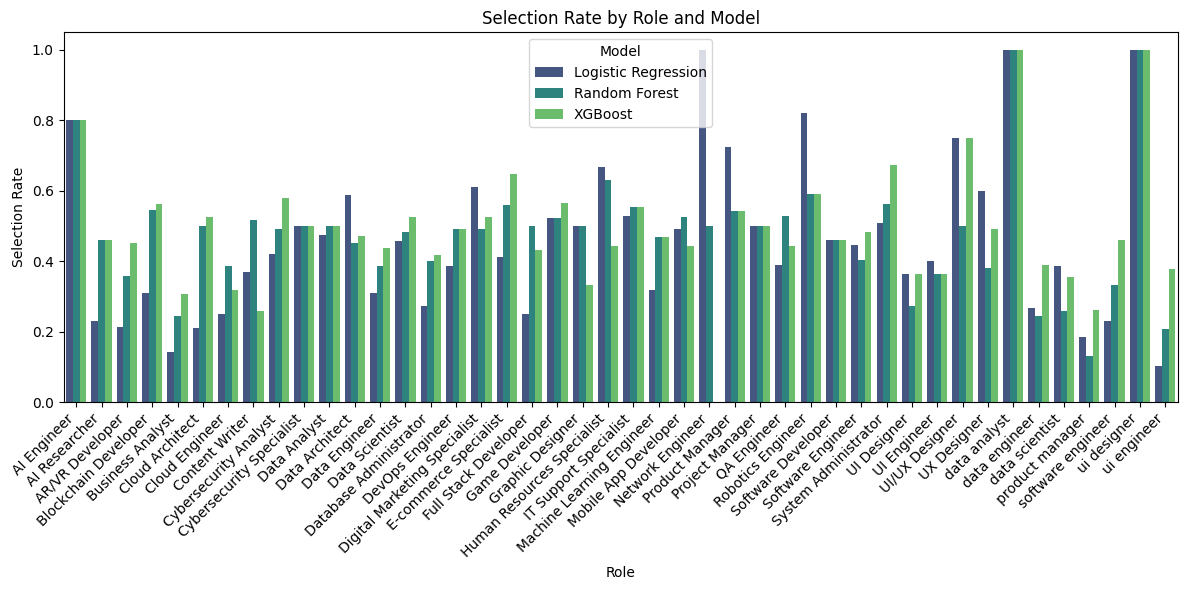

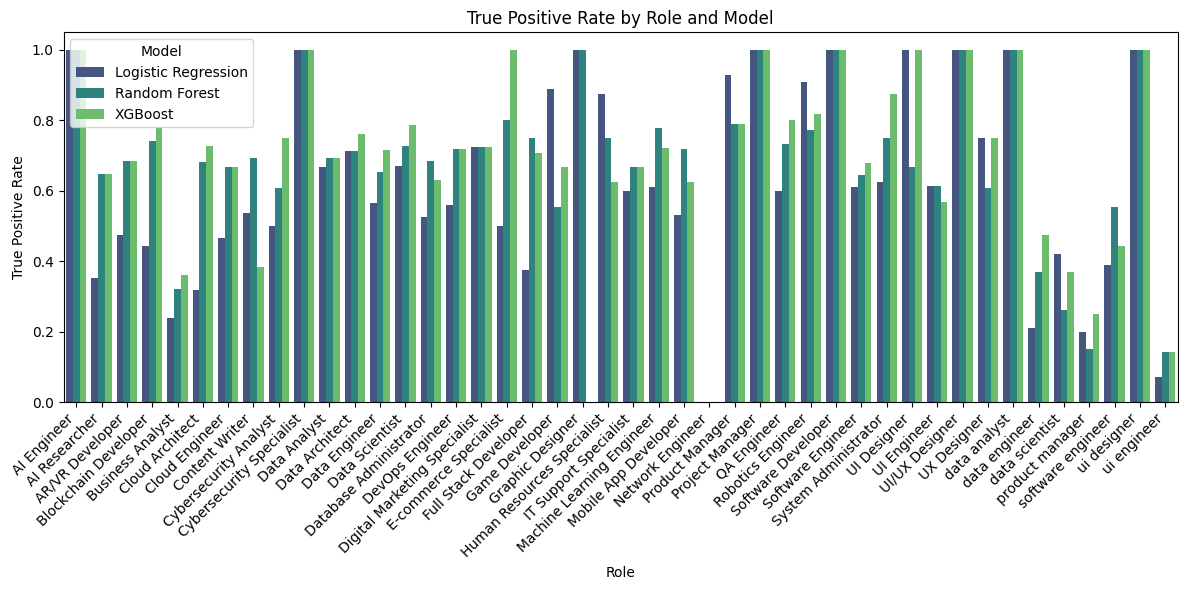

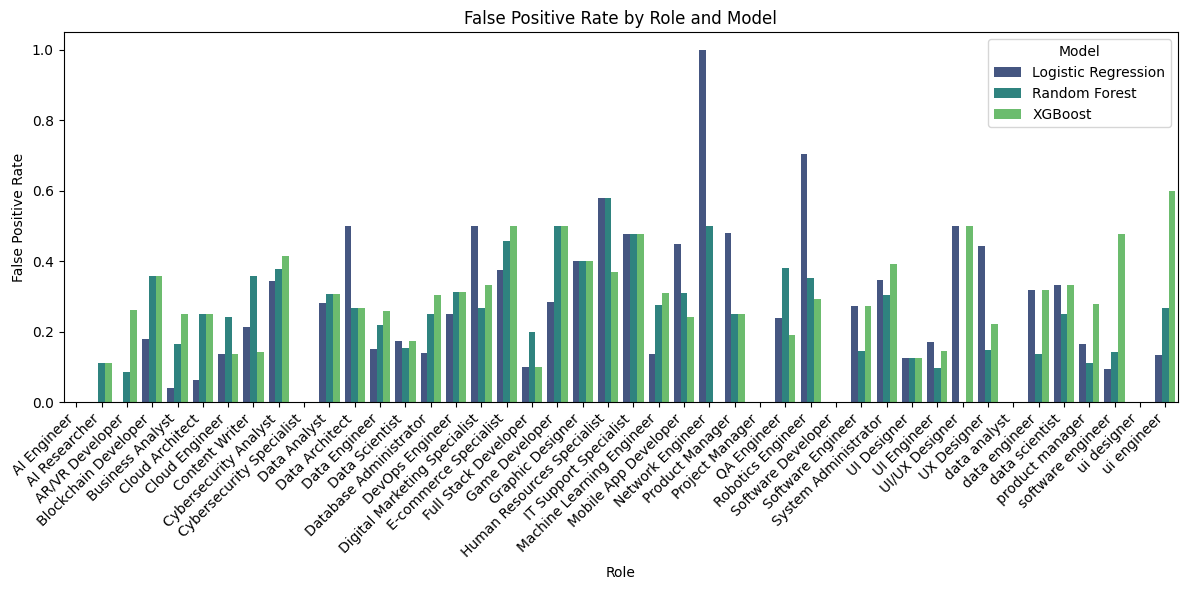


--- Summary of Overall Fairness Metrics (Differences/Ratios) ---
                                            Metric  Logistic Regression  \
0   Demographic Parity Difference (Selection Rate)               0.8966   
1        Demographic Parity Ratio (Selection Rate)               0.1034   
2   Equalized Odds Difference (True Positive Rate)               1.0000   
3        Equalized Odds Ratio (True Positive Rate)               0.0000   
4  Equalized Odds Difference (False Positive Rate)               1.0000   
5       Equalized Odds Ratio (False Positive Rate)               0.0000   

   Random Forest  XGBoost  
0         0.8684      1.0  
1         0.1316      0.0  
2         1.0000      1.0  
3         0.0000      0.0  
4         0.5789      0.6  
5         0.0000      0.0  


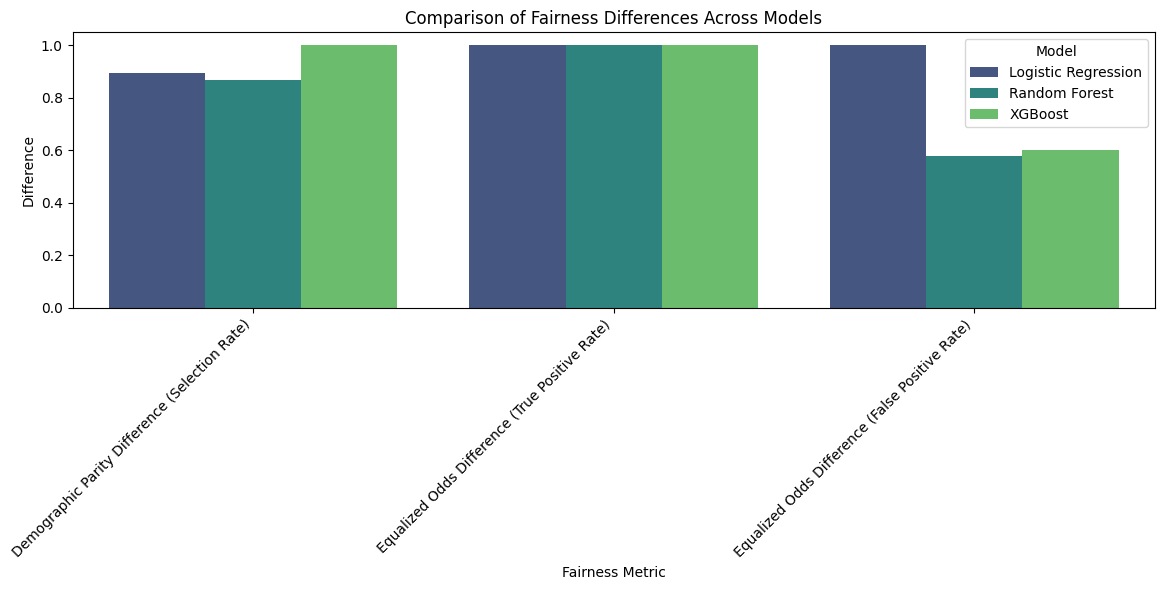

In [ ]:
# Fairness Evaluation

# --- Import Necessary Libraries ---
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Fairlearn imports
from fairlearn.metrics import (
    demographic_parity_difference,
    demographic_parity_ratio,
    equalized_odds_difference,
    equalized_odds_ratio,
    MetricFrame,
)
from fairlearn.metrics import selection_rate, true_positive_rate, false_positive_rate




import seaborn as sns

# --- Load the Processed Data with Labels and Sensitive Attributes ---

labeled_data_path = '/content/drive/MyDrive/Dissertation/processed_data_with_labels.csv'
try:
    df_fairness = pd.read_csv(labeled_data_path)
    print("Processed dataset loaded successfully for fairness evaluation.")
except FileNotFoundError:
    print(f"Error: The file '{labeled_data_path}' was not found. Cannot proceed with fairness evaluation.")



try:
    X_refined_cols_df = pd.read_csv('/content/drive/MyDrive/Dissertation/final_refined_features_dataset.csv')
    final_refined_features = X_refined_cols_df.columns.tolist()
except FileNotFoundError:
    print("Warning: Could not load final_refined_features_dataset.csv to get feature names.")
    print("Using all numeric columns except 'label', 'Role_encoded', 'ID' for fairness features.")

    non_feature_cols = ['label', 'Role_encoded', 'ID', 'Name', 'Role', 'Transcript', 'Resume', 'Reason_for_decision', 'Job_Description', 'cleaned_text']
    numeric_cols = df_fairness.select_dtypes(include=np.number).columns.tolist()
    final_refined_features = [col for col in numeric_cols if col not in non_feature_cols]
    if not final_refined_features:
        print("Error: Failed to identify feature columns for fairness evaluation.")


# Check if df_fairness was loaded successfully before proceeding
if 'df_fairness' not in locals() or df_fairness is None:
    print("Exiting due to failure in loading processed data.")
    exit()


X_fairness = df_fairness[final_refined_features]
y_fairness = df_fairness['label']

# Handle potential NaN/Inf in the selected features
X_fairness = X_fairness.replace([np.inf, -np.inf], np.nan).fillna(X_fairness.mean())


# --- Identify Sensitive Attributes ---

if 'Role' not in df_fairness.columns:
    print("Error: 'Role' column not found in the dataset for fairness evaluation.")
    # exit() # Exit if the sensitive attribute is missing

sensitive_attribute_name = 'Role'

if df_fairness[sensitive_attribute_name].isnull().any():
    print(f"Warning: Missing values found in sensitive attribute '{sensitive_attribute_name}'. Imputing with mode.")
    mode_val = df_fairness[sensitive_attribute_name].mode()[0]
    df_fairness[sensitive_attribute_name].fillna(mode_val, inplace=True)

sensitive_attribute = df_fairness[sensitive_attribute_name]


# --- Split Data for Fairness Evaluation ---

X_train_fair, X_test_fair, y_train_fair, y_test_fair, sa_train, sa_test = train_test_split(
    X_fairness, y_fairness, sensitive_attribute, test_size=0.25, random_state=42, stratify=y_fairness
)

print(f"\nData split for Fairness Evaluation:")
print(f"Training set shape (features): {X_train_fair.shape}")
print(f"Testing set shape (features): {X_test_fair.shape}")
print(f"Training set shape (labels): {y_train_fair.shape}")
print(f"Testing set shape (labels): {y_test_fair.shape}")
print(f"Training set shape (sensitive attribute): {sa_train.shape}")
print(f"Testing set shape (sensitive attribute): {sa_test.shape}")

# --- Train Models (using the best hyperparameters found previously) ---

print("\n--- Training Models for Fairness Evaluation ---")


try:

    if 'best_log_reg_model' in locals() and best_log_reg_model is not None:
         lr_model_fair = best_log_reg_model
         print("Using tuned Logistic Regression model.")
    else:
        raise NameError

except NameError:
    print("Tuned Logistic Regression model not found or is None. Training a new one with default params.")
    lr_model_fair = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)

lr_model_fair.fit(X_train_fair, y_train_fair)
y_pred_lr_fair = lr_model_fair.predict(X_test_fair)



try:

    if 'best_rf_model' in locals() and best_rf_model is not None:
         rf_model_fair = best_rf_model
         print("Using tuned Random Forest model.")
    else:
        raise NameError

except NameError:
     print("Tuned Random Forest model not found or is None. Training a new one with default params.")
     rf_model_fair = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model_fair.fit(X_train_fair, y_train_fair)
y_pred_rf_fair = rf_model_fair.predict(X_test_fair)


try:

    if 'best_xgb_model' in locals() and best_xgb_model is not None:
        xgb_model_fair = best_xgb_model
        print("Using tuned XGBoost model.")
    else:
        raise NameError

except NameError:
    print("Tuned XGBoost model not found or is None. Training a new one with default params.")

    n_rejected = len(y_train_fair[y_train_fair == 0])
    n_selected = len(y_train_fair[y_train_fair == 1])
    scale_pos_weight_value_fair = n_rejected / n_selected if n_selected > 0 else 1.0
    xgb_model_fair = xgb.XGBClassifier(
        objective='binary:logistic',
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight_value_fair
    )

xgb_model_fair.fit(X_train_fair, y_train_fair)
y_pred_xgb_fair = xgb_model_fair.predict(X_test_fair)


print("\nModels trained on fairness evaluation split.")

# --- Evaluate Fairness using Fairlearn ---

print("\n--- Fairness Evaluation using Fairlearn ---")


basic_fairness_metrics = {
    'selection_rate': selection_rate,
    'true_positive_rate': true_positive_rate,
    'false_positive_rate': false_positive_rate,
}


sa_test_series = pd.Series(sa_test, index=X_test_fair.index, name=sensitive_attribute_name)


# Evaluate fairness for Logistic Regression
print("\nFairness Metrics for Logistic Regression:")
metric_frame_lr = MetricFrame(
    metrics=basic_fairness_metrics,
    y_true=y_test_fair,
    y_pred=y_pred_lr_fair,
    sensitive_features=sa_test_series
)
print("Metrics by group:")
print(metric_frame_lr.by_group)
print("\nOverall Metrics:")
print(metric_frame_lr.overall)
print("\nDifferences and Ratios:")

print("Demographic Parity Difference (Selection Rate):", metric_frame_lr.difference(method='between_groups')['selection_rate'])
print("Demographic Parity Ratio (Selection Rate):", metric_frame_lr.ratio(method='between_groups')['selection_rate'])
print("Equalized Odds Difference (True Positive Rate):", metric_frame_lr.difference(method='between_groups')['true_positive_rate'])
print("Equalized Odds Ratio (True Positive Rate):", metric_frame_lr.ratio(method='between_groups')['true_positive_rate'])
print("Equalized Odds Difference (False Positive Rate):", metric_frame_lr.difference(method='between_groups')['false_positive_rate'])
print("Equalized Odds Ratio (False Positive Rate):", metric_frame_lr.ratio(method='between_groups')['false_positive_rate'])



# Evaluate fairness for Random Forest
print("\nFairness Metrics for Random Forest:")
metric_frame_rf = MetricFrame(
    metrics=basic_fairness_metrics,
    y_true=y_test_fair,
    y_pred=y_pred_rf_fair,
    sensitive_features=sa_test_series
)
print("Metrics by group:")
print(metric_frame_rf.by_group)
print("\nOverall Metrics:")
print(metric_frame_rf.overall)
print("\nDifferences and Ratios:")
print("Demographic Parity Difference (Selection Rate):", metric_frame_rf.difference(method='between_groups')['selection_rate'])
print("Demographic Parity Ratio (Selection Rate):", metric_frame_rf.ratio(method='between_groups')['selection_rate'])
print("Equalized Odds Difference (True Positive Rate):", metric_frame_rf.difference(method='between_groups')['true_positive_rate'])
print("Equalized Odds Ratio (True Positive Rate):", metric_frame_rf.ratio(method='between_groups')['true_positive_rate'])
print("Equalized Odds Difference (False Positive Rate):", metric_frame_rf.difference(method='between_groups')['false_positive_rate'])
print("Equalized Odds Ratio (False Positive Rate):", metric_frame_rf.ratio(method='between_groups')['false_positive_rate'])


# Evaluate fairness for XGBoost
print("\nFairness Metrics for XGBoost:")
metric_frame_xgb = MetricFrame(
    metrics=basic_fairness_metrics,
    y_true=y_test_fair,
    y_pred=y_pred_xgb_fair,
    sensitive_features=sa_test_series
)
print("Metrics by group:")
print(metric_frame_xgb.by_group)
print("\nOverall Metrics:")
print(metric_frame_xgb.overall)
print("\nDifferences and Ratios:")
print("Demographic Parity Difference (Selection Rate):", metric_frame_xgb.difference(method='between_groups')['selection_rate'])
print("Demographic Parity Ratio (Selection Rate):", metric_frame_xgb.ratio(method='between_groups')['selection_rate'])
print("Equalized Odds Difference (True Positive Rate):", metric_frame_xgb.difference(method='between_groups')['true_positive_rate'])
print("Equalized Odds Ratio (True Positive Rate):", metric_frame_xgb.ratio(method='between_groups')['true_positive_rate'])
print("Equalized Odds Difference (False Positive Rate):", metric_frame_xgb.difference(method='between_groups')['false_positive_rate'])
print("Equalized Odds Ratio (False Positive Rate):", metric_frame_xgb.ratio(method='between_groups')['false_positive_rate'])



print("\n--- Visualizing Fairness Metrics ---")


fairness_results_lr = metric_frame_lr.by_group.reset_index().assign(Model='Logistic Regression')
fairness_results_rf = metric_frame_rf.by_group.reset_index().assign(Model='Random Forest')
fairness_results_xgb = metric_frame_xgb.by_group.reset_index().assign(Model='XGBoost')

all_fairness_results = pd.concat([fairness_results_lr, fairness_results_rf, fairness_results_xgb])


all_fairness_results_melted = all_fairness_results.melt(
    id_vars=[sensitive_attribute_name, 'Model'],
    var_name='Metric',
    value_name='Value'
)

# Plotting function
def plot_fairness_metric(df, metric_name, title):

    if metric_name not in df['Metric'].unique():
        print(f"Warning: Metric '{metric_name}' not found in the melted DataFrame. Skipping plot.")
        return

    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=df[df['Metric'] == metric_name],
        x=sensitive_attribute_name,
        y='Value',
        hue='Model',
        palette='viridis'
    )
    plt.title(title)
    plt.xlabel(sensitive_attribute_name)
    plt.ylabel(metric_name.replace('_', ' ').title())
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

plot_fairness_metric(all_fairness_results_melted, 'selection_rate', 'Selection Rate by Role and Model')
plot_fairness_metric(all_fairness_results_melted, 'true_positive_rate', 'True Positive Rate by Role and Model')
plot_fairness_metric(all_fairness_results_melted, 'false_positive_rate', 'False Positive Rate by Role and Model')


summary_metrics_data_full = {
    'Metric': ['Demographic Parity Difference (Selection Rate)', 'Demographic Parity Ratio (Selection Rate)',
               'Equalized Odds Difference (True Positive Rate)', 'Equalized Odds Ratio (True Positive Rate)',
               'Equalized Odds Difference (False Positive Rate)', 'Equalized Odds Ratio (False Positive Rate)'],
    'Logistic Regression': [
        metric_frame_lr.difference(method='between_groups')['selection_rate'],
        metric_frame_lr.ratio(method='between_groups')['selection_rate'],
        metric_frame_lr.difference(method='between_groups')['true_positive_rate'],
        metric_frame_lr.ratio(method='between_groups')['true_positive_rate'],
        metric_frame_lr.difference(method='between_groups')['false_positive_rate'],
        metric_frame_lr.ratio(method='between_groups')['false_positive_rate'],
    ],
    'Random Forest': [
        metric_frame_rf.difference(method='between_groups')['selection_rate'],
        metric_frame_rf.ratio(method='between_groups')['selection_rate'],
        metric_frame_rf.difference(method='between_groups')['true_positive_rate'],
        metric_frame_rf.ratio(method='between_groups')['true_positive_rate'],
        metric_frame_rf.difference(method='between_groups')['false_positive_rate'],
        metric_frame_rf.ratio(method='between_groups')['false_positive_rate'],
    ],
     'XGBoost': [
        metric_frame_xgb.difference(method='between_groups')['selection_rate'],
        metric_frame_xgb.ratio(method='between_groups')['selection_rate'],
        metric_frame_xgb.difference(method='between_groups')['true_positive_rate'],
        metric_frame_xgb.ratio(method='between_groups')['true_positive_rate'],
        metric_frame_xgb.difference(method='between_groups')['false_positive_rate'],
        metric_frame_xgb.ratio(method='between_groups')['false_positive_rate'],
    ]
}


summary_df = pd.DataFrame(summary_metrics_data_full)
print("\n--- Summary of Overall Fairness Metrics (Differences/Ratios) ---")
print(summary_df.round(4))


summary_melted_diff = summary_df[['Metric', 'Logistic Regression', 'Random Forest', 'XGBoost']].melt(
    id_vars='Metric', var_name='Model', value_name='Difference'
)
summary_melted_diff = summary_melted_diff[summary_melted_diff['Metric'].str.contains('Difference')]

plt.figure(figsize=(12, 6))
sns.barplot(data=summary_melted_diff, x='Metric', y='Difference', hue='Model', palette='viridis')
plt.title('Comparison of Fairness Differences Across Models')
plt.xlabel('Fairness Metric')
plt.ylabel('Difference')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**extracted_education_level_encoded ( LOGISTIC REGRESSION ,RANDOM FOREST ,XGBOOST)**

Processed dataset loaded successfully for fairness evaluation.

Data split for Fairness Evaluation:
Training set shape (features): (5628, 21)
Testing set shape (features): (1876, 21)
Training set shape (labels): (5628,)
Testing set shape (labels): (1876,)
Training set shape (sensitive attribute): (5628,)
Testing set shape (sensitive attribute): (1876,)

--- Training Models for Fairness Evaluation ---
Tuned Logistic Regression model not found or is None. Training a new one with default params.
Tuned Random Forest model not found or is None. Training a new one with default params.
Tuned XGBoost model not found or is None. Training a new one with default params.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [14:49:40] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Models trained on fairness evaluation split.

--- Fairness Evaluation using Fairlearn ---

Fairness Metrics for Logistic Regression:
Metrics by group:
                                   selection_rate  true_positive_rate  \
extracted_education_level_encoded                                       
0                                        0.428571            0.857143   
1                                        0.383636            0.535354   
2                                        0.464129            0.629310   
3                                        0.518987            0.722222   

                                   false_positive_rate  
extracted_education_level_encoded                       
0                                             0.000000  
1                                             0.259504  
2                                             0.292537  
3                                             0.080000  

Overall Metrics:
selection_rate         0.418977
true_positive_rat

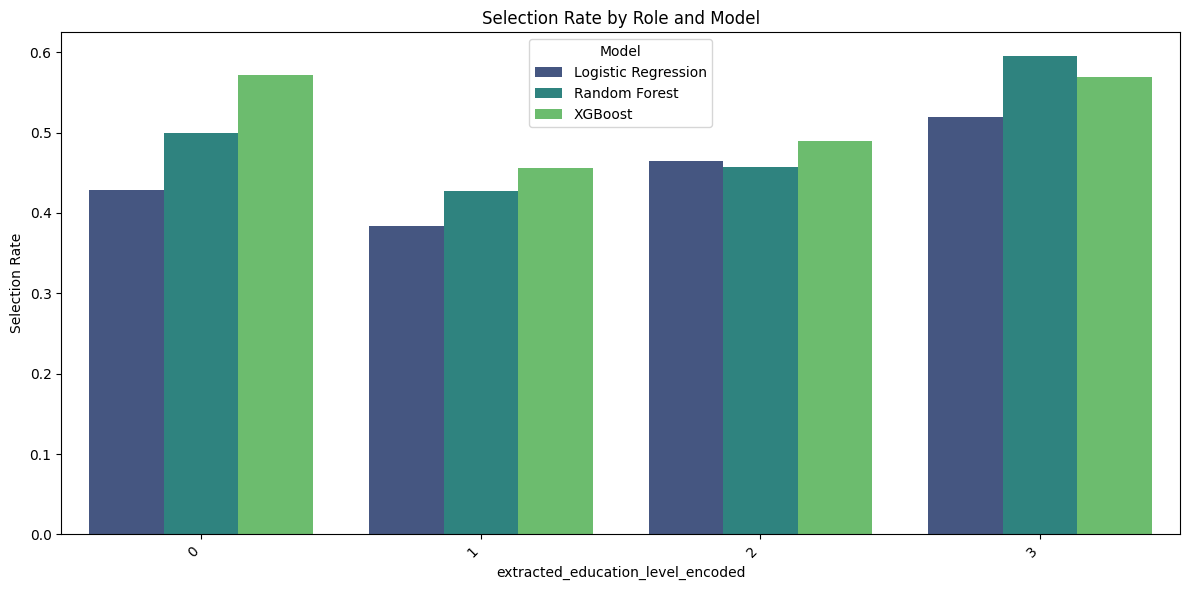

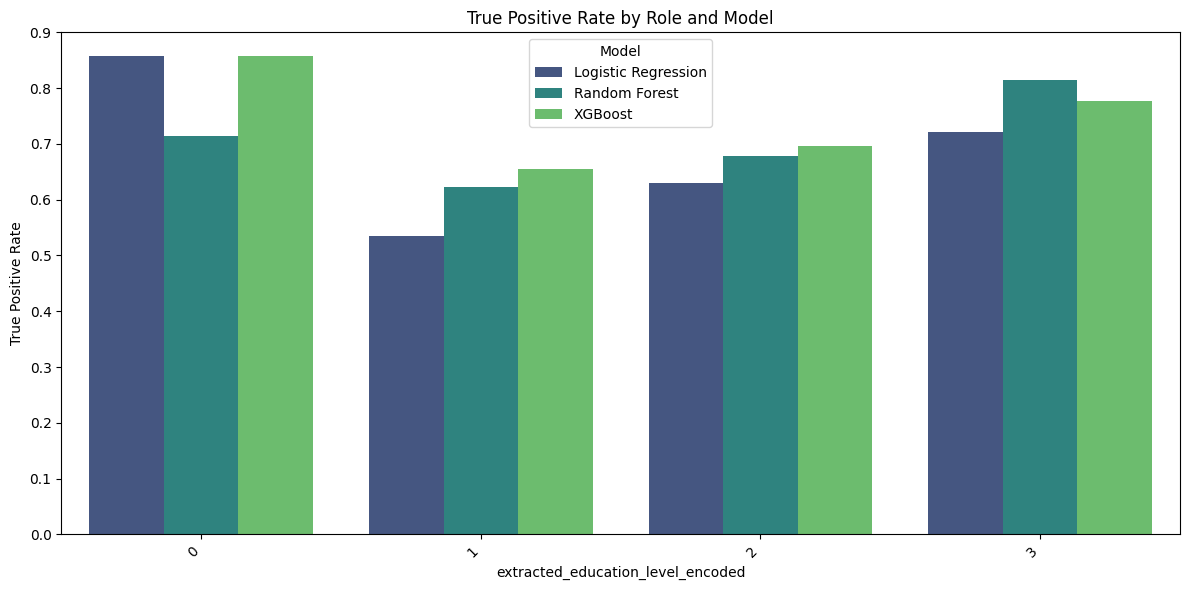

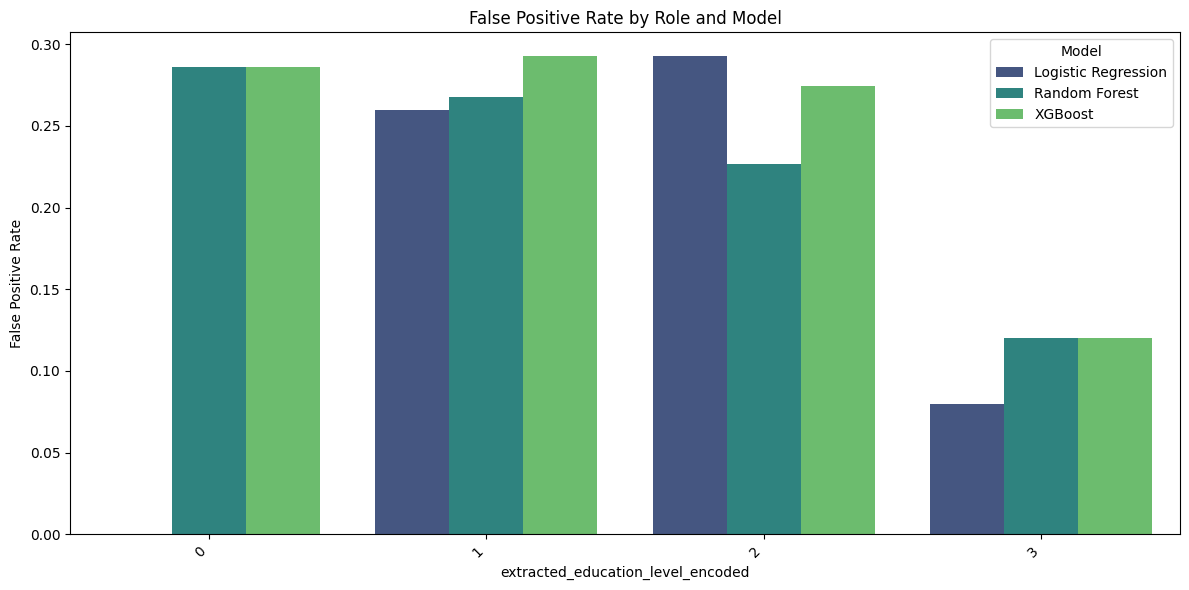


--- Summary of Overall Fairness Metrics (Differences/Ratios) ---
                                            Metric  Logistic Regression  \
0   Demographic Parity Difference (Selection Rate)               0.1354   
1        Demographic Parity Ratio (Selection Rate)               0.7392   
2   Equalized Odds Difference (True Positive Rate)               0.3218   
3        Equalized Odds Ratio (True Positive Rate)               0.6246   
4  Equalized Odds Difference (False Positive Rate)               0.2925   
5       Equalized Odds Ratio (False Positive Rate)               0.0000   

   Random Forest  XGBoost  
0         0.1677   0.1160  
1         0.7182   0.7970  
2         0.1926   0.2026  
3         0.7636   0.7636  
4         0.1657   0.1726  
5         0.4200   0.4102  


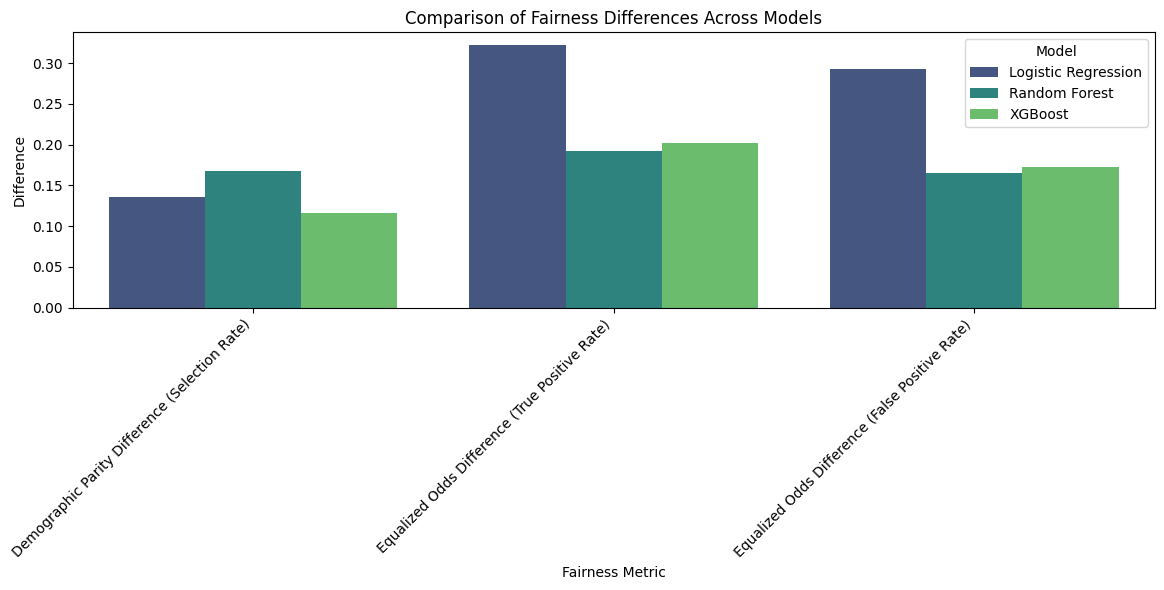

In [ ]:
# Fairness Evaluation

# --- Import Necessary Libraries ---
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Fairlearn imports
from fairlearn.metrics import (
    demographic_parity_difference,
    demographic_parity_ratio,
    equalized_odds_difference,
    equalized_odds_ratio,
    MetricFrame,
)
from fairlearn.metrics import selection_rate, true_positive_rate, false_positive_rate




import seaborn as sns

# --- Load the Processed Data with Labels and Sensitive Attributes ---

labeled_data_path = '/content/drive/MyDrive/Dissertation/processed_data_with_labels.csv'
try:
    df_fairness = pd.read_csv(labeled_data_path)
    print("Processed dataset loaded successfully for fairness evaluation.")
except FileNotFoundError:
    print(f"Error: The file '{labeled_data_path}' was not found. Cannot proceed with fairness evaluation.")



try:
    X_refined_cols_df = pd.read_csv('/content/drive/MyDrive/Dissertation/final_refined_features_dataset.csv')
    final_refined_features = X_refined_cols_df.columns.tolist()
except FileNotFoundError:
    print("Warning: Could not load final_refined_features_dataset.csv to get feature names.")
    print("Using all numeric columns except 'label', 'Role_encoded', 'ID' for fairness features.")

    non_feature_cols = ['label', 'Role_encoded', 'ID', 'Name', 'Role', 'Transcript', 'Resume', 'Reason_for_decision', 'Job_Description', 'cleaned_text']
    numeric_cols = df_fairness.select_dtypes(include=np.number).columns.tolist()
    final_refined_features = [col for col in numeric_cols if col not in non_feature_cols]
    if not final_refined_features:
        print("Error: Failed to identify feature columns for fairness evaluation.")


# Check if df_fairness was loaded successfully before proceeding
if 'df_fairness' not in locals() or df_fairness is None:
    print("Exiting due to failure in loading processed data.")
    exit()


X_fairness = df_fairness[final_refined_features]
y_fairness = df_fairness['label']

# Handle potential NaN/Inf in the selected features
X_fairness = X_fairness.replace([np.inf, -np.inf], np.nan).fillna(X_fairness.mean())


# --- Identify Sensitive Attributes ---

if 'extracted_education_level_encoded' not in df_fairness.columns:
    print("Error: 'Role' column not found in the dataset for fairness evaluation.")


sensitive_attribute_name = 'extracted_education_level_encoded'

if df_fairness[sensitive_attribute_name].isnull().any():
    print(f"Warning: Missing values found in sensitive attribute '{sensitive_attribute_name}'. Imputing with mode.")
    mode_val = df_fairness[sensitive_attribute_name].mode()[0]
    df_fairness[sensitive_attribute_name].fillna(mode_val, inplace=True)

sensitive_attribute = df_fairness[sensitive_attribute_name]


# --- Split Data for Fairness Evaluation ---

X_train_fair, X_test_fair, y_train_fair, y_test_fair, sa_train, sa_test = train_test_split(
    X_fairness, y_fairness, sensitive_attribute, test_size=0.25, random_state=42, stratify=y_fairness
)

print(f"\nData split for Fairness Evaluation:")
print(f"Training set shape (features): {X_train_fair.shape}")
print(f"Testing set shape (features): {X_test_fair.shape}")
print(f"Training set shape (labels): {y_train_fair.shape}")
print(f"Testing set shape (labels): {y_test_fair.shape}")
print(f"Training set shape (sensitive attribute): {sa_train.shape}")
print(f"Testing set shape (sensitive attribute): {sa_test.shape}")

# --- Train Models (using the best hyperparameters found previously) ---

print("\n--- Training Models for Fairness Evaluation ---")


try:

    if 'best_log_reg_model' in locals() and best_log_reg_model is not None:
         lr_model_fair = best_log_reg_model
         print("Using tuned Logistic Regression model.")
    else:
        raise NameError

except NameError:
    print("Tuned Logistic Regression model not found or is None. Training a new one with default params.")
    lr_model_fair = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)

lr_model_fair.fit(X_train_fair, y_train_fair)
y_pred_lr_fair = lr_model_fair.predict(X_test_fair)



try:

    if 'best_rf_model' in locals() and best_rf_model is not None:
         rf_model_fair = best_rf_model
         print("Using tuned Random Forest model.")
    else:
        raise NameError

except NameError:
     print("Tuned Random Forest model not found or is None. Training a new one with default params.")
     rf_model_fair = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model_fair.fit(X_train_fair, y_train_fair)
y_pred_rf_fair = rf_model_fair.predict(X_test_fair)


try:

    if 'best_xgb_model' in locals() and best_xgb_model is not None:
        xgb_model_fair = best_xgb_model
        print("Using tuned XGBoost model.")
    else:
        raise NameError

except NameError:
    print("Tuned XGBoost model not found or is None. Training a new one with default params.")

    n_rejected = len(y_train_fair[y_train_fair == 0])
    n_selected = len(y_train_fair[y_train_fair == 1])
    scale_pos_weight_value_fair = n_rejected / n_selected if n_selected > 0 else 1.0
    xgb_model_fair = xgb.XGBClassifier(
        objective='binary:logistic',
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight_value_fair
    )

xgb_model_fair.fit(X_train_fair, y_train_fair)
y_pred_xgb_fair = xgb_model_fair.predict(X_test_fair)


print("\nModels trained on fairness evaluation split.")

# --- Evaluate Fairness using Fairlearn ---

print("\n--- Fairness Evaluation using Fairlearn ---")


basic_fairness_metrics = {
    'selection_rate': selection_rate,
    'true_positive_rate': true_positive_rate,
    'false_positive_rate': false_positive_rate,
}


sa_test_series = pd.Series(sa_test, index=X_test_fair.index, name=sensitive_attribute_name)


# Evaluate fairness for Logistic Regression
print("\nFairness Metrics for Logistic Regression:")
metric_frame_lr = MetricFrame(
    metrics=basic_fairness_metrics,
    y_true=y_test_fair,
    y_pred=y_pred_lr_fair,
    sensitive_features=sa_test_series
)
print("Metrics by group:")
print(metric_frame_lr.by_group)
print("\nOverall Metrics:")
print(metric_frame_lr.overall)
print("\nDifferences and Ratios:")

print("Demographic Parity Difference (Selection Rate):", metric_frame_lr.difference(method='between_groups')['selection_rate'])
print("Demographic Parity Ratio (Selection Rate):", metric_frame_lr.ratio(method='between_groups')['selection_rate'])
print("Equalized Odds Difference (True Positive Rate):", metric_frame_lr.difference(method='between_groups')['true_positive_rate'])
print("Equalized Odds Ratio (True Positive Rate):", metric_frame_lr.ratio(method='between_groups')['true_positive_rate'])
print("Equalized Odds Difference (False Positive Rate):", metric_frame_lr.difference(method='between_groups')['false_positive_rate'])
print("Equalized Odds Ratio (False Positive Rate):", metric_frame_lr.ratio(method='between_groups')['false_positive_rate'])



# Evaluate fairness for Random Forest
print("\nFairness Metrics for Random Forest:")
metric_frame_rf = MetricFrame(
    metrics=basic_fairness_metrics,
    y_true=y_test_fair,
    y_pred=y_pred_rf_fair,
    sensitive_features=sa_test_series
)
print("Metrics by group:")
print(metric_frame_rf.by_group)
print("\nOverall Metrics:")
print(metric_frame_rf.overall)
print("\nDifferences and Ratios:")
print("Demographic Parity Difference (Selection Rate):", metric_frame_rf.difference(method='between_groups')['selection_rate'])
print("Demographic Parity Ratio (Selection Rate):", metric_frame_rf.ratio(method='between_groups')['selection_rate'])
print("Equalized Odds Difference (True Positive Rate):", metric_frame_rf.difference(method='between_groups')['true_positive_rate'])
print("Equalized Odds Ratio (True Positive Rate):", metric_frame_rf.ratio(method='between_groups')['true_positive_rate'])
print("Equalized Odds Difference (False Positive Rate):", metric_frame_rf.difference(method='between_groups')['false_positive_rate'])
print("Equalized Odds Ratio (False Positive Rate):", metric_frame_rf.ratio(method='between_groups')['false_positive_rate'])


# Evaluate fairness for XGBoost
print("\nFairness Metrics for XGBoost:")
metric_frame_xgb = MetricFrame(
    metrics=basic_fairness_metrics,
    y_true=y_test_fair,
    y_pred=y_pred_xgb_fair,
    sensitive_features=sa_test_series
)
print("Metrics by group:")
print(metric_frame_xgb.by_group)
print("\nOverall Metrics:")
print(metric_frame_xgb.overall)
print("\nDifferences and Ratios:")
print("Demographic Parity Difference (Selection Rate):", metric_frame_xgb.difference(method='between_groups')['selection_rate'])
print("Demographic Parity Ratio (Selection Rate):", metric_frame_xgb.ratio(method='between_groups')['selection_rate'])
print("Equalized Odds Difference (True Positive Rate):", metric_frame_xgb.difference(method='between_groups')['true_positive_rate'])
print("Equalized Odds Ratio (True Positive Rate):", metric_frame_xgb.ratio(method='between_groups')['true_positive_rate'])
print("Equalized Odds Difference (False Positive Rate):", metric_frame_xgb.difference(method='between_groups')['false_positive_rate'])
print("Equalized Odds Ratio (False Positive Rate):", metric_frame_xgb.ratio(method='between_groups')['false_positive_rate'])



print("\n--- Visualizing Fairness Metrics ---")


fairness_results_lr = metric_frame_lr.by_group.reset_index().assign(Model='Logistic Regression')
fairness_results_rf = metric_frame_rf.by_group.reset_index().assign(Model='Random Forest')
fairness_results_xgb = metric_frame_xgb.by_group.reset_index().assign(Model='XGBoost')

all_fairness_results = pd.concat([fairness_results_lr, fairness_results_rf, fairness_results_xgb])


all_fairness_results_melted = all_fairness_results.melt(
    id_vars=[sensitive_attribute_name, 'Model'],
    var_name='Metric',
    value_name='Value'
)

# Plotting function
def plot_fairness_metric(df, metric_name, title):

    if metric_name not in df['Metric'].unique():
        print(f"Warning: Metric '{metric_name}' not found in the melted DataFrame. Skipping plot.")
        return

    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=df[df['Metric'] == metric_name],
        x=sensitive_attribute_name,
        y='Value',
        hue='Model',
        palette='viridis'
    )
    plt.title(title)
    plt.xlabel(sensitive_attribute_name)
    plt.ylabel(metric_name.replace('_', ' ').title())
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

plot_fairness_metric(all_fairness_results_melted, 'selection_rate', 'Selection Rate by Role and Model')
plot_fairness_metric(all_fairness_results_melted, 'true_positive_rate', 'True Positive Rate by Role and Model')
plot_fairness_metric(all_fairness_results_melted, 'false_positive_rate', 'False Positive Rate by Role and Model')


summary_metrics_data_full = {
    'Metric': ['Demographic Parity Difference (Selection Rate)', 'Demographic Parity Ratio (Selection Rate)',
               'Equalized Odds Difference (True Positive Rate)', 'Equalized Odds Ratio (True Positive Rate)',
               'Equalized Odds Difference (False Positive Rate)', 'Equalized Odds Ratio (False Positive Rate)'],
    'Logistic Regression': [
        metric_frame_lr.difference(method='between_groups')['selection_rate'],
        metric_frame_lr.ratio(method='between_groups')['selection_rate'],
        metric_frame_lr.difference(method='between_groups')['true_positive_rate'],
        metric_frame_lr.ratio(method='between_groups')['true_positive_rate'],
        metric_frame_lr.difference(method='between_groups')['false_positive_rate'],
        metric_frame_lr.ratio(method='between_groups')['false_positive_rate'],
    ],
    'Random Forest': [
        metric_frame_rf.difference(method='between_groups')['selection_rate'],
        metric_frame_rf.ratio(method='between_groups')['selection_rate'],
        metric_frame_rf.difference(method='between_groups')['true_positive_rate'],
        metric_frame_rf.ratio(method='between_groups')['true_positive_rate'],
        metric_frame_rf.difference(method='between_groups')['false_positive_rate'],
        metric_frame_rf.ratio(method='between_groups')['false_positive_rate'],
    ],
     'XGBoost': [
        metric_frame_xgb.difference(method='between_groups')['selection_rate'],
        metric_frame_xgb.ratio(method='between_groups')['selection_rate'],
        metric_frame_xgb.difference(method='between_groups')['true_positive_rate'],
        metric_frame_xgb.ratio(method='between_groups')['true_positive_rate'],
        metric_frame_xgb.difference(method='between_groups')['false_positive_rate'],
        metric_frame_xgb.ratio(method='between_groups')['false_positive_rate'],
    ]
}


summary_df = pd.DataFrame(summary_metrics_data_full)
print("\n--- Summary of Overall Fairness Metrics (Differences/Ratios) ---")
print(summary_df.round(4))


summary_melted_diff = summary_df[['Metric', 'Logistic Regression', 'Random Forest', 'XGBoost']].melt(
    id_vars='Metric', var_name='Model', value_name='Difference'
)
summary_melted_diff = summary_melted_diff[summary_melted_diff['Metric'].str.contains('Difference')]

plt.figure(figsize=(12, 6))
sns.barplot(data=summary_melted_diff, x='Metric', y='Difference', hue='Model', palette='viridis')
plt.title('Comparison of Fairness Differences Across Models')
plt.xlabel('Fairness Metric')
plt.ylabel('Difference')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

 **extracted_experience_level_encoded( LOGISTIC REGRESSION ,RANDOM FOREST ,XGBOOST)**

Processed dataset loaded successfully for fairness evaluation.

Data split for Fairness Evaluation:
Training set shape (features): (5628, 21)
Testing set shape (features): (1876, 21)
Training set shape (labels): (5628,)
Testing set shape (labels): (1876,)
Training set shape (sensitive attribute): (5628,)
Testing set shape (sensitive attribute): (1876,)

--- Training Models for Fairness Evaluation ---
Tuned Logistic Regression model not found or is None. Training a new one with default params.
Tuned Random Forest model not found or is None. Training a new one with default params.
Tuned XGBoost model not found or is None. Training a new one with default params.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [14:50:09] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Models trained on fairness evaluation split.

--- Fairness Evaluation using Fairlearn ---

Fairness Metrics for Logistic Regression:
Metrics by group:
                                    selection_rate  true_positive_rate  \
extracted_experience_level_encoded                                       
0                                         0.396927            0.597183   
1                                         0.434703            0.577413   

                                    false_positive_rate  
extracted_experience_level_encoded                       
0                                              0.230047  
1                                              0.291209  

Overall Metrics:
selection_rate         0.418977
true_positive_rate     0.585177
false_positive_rate    0.264403
dtype: float64

Differences and Ratios:
Demographic Parity Difference (Selection Rate): 0.03777617970170549
Demographic Parity Ratio (Selection Rate): 0.9130989143416649
Equalized Odds Difference (True Pos

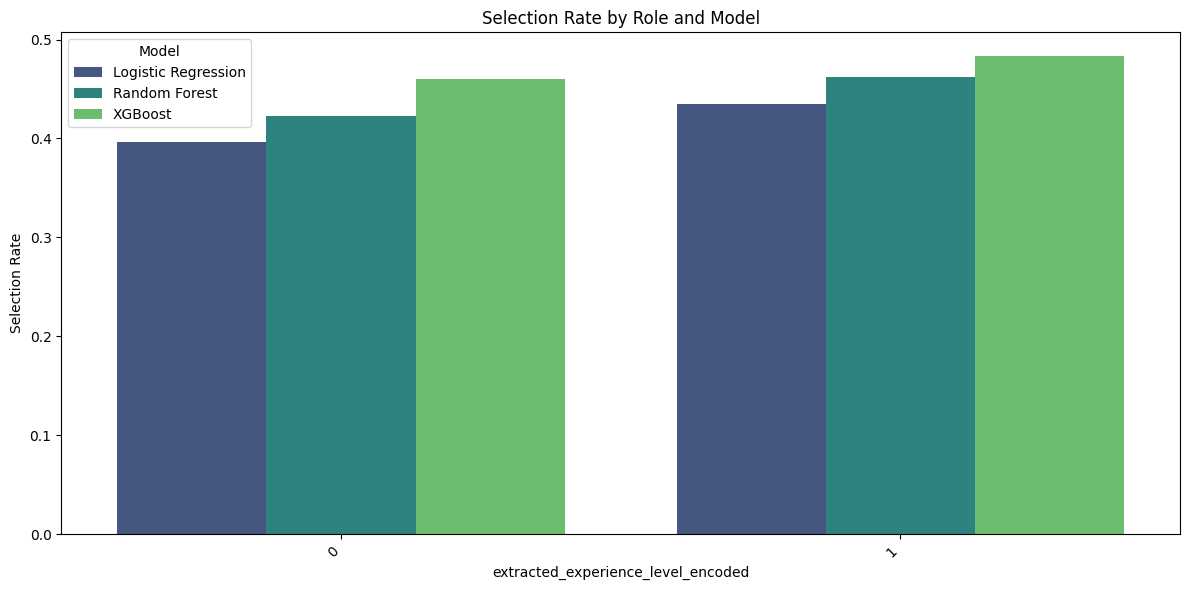

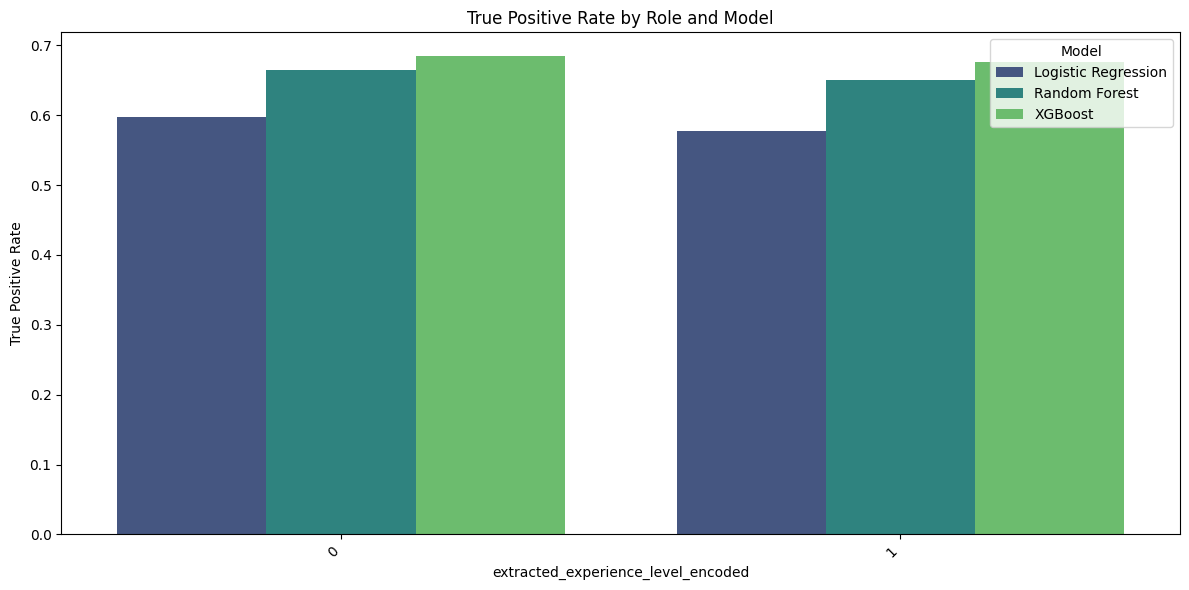

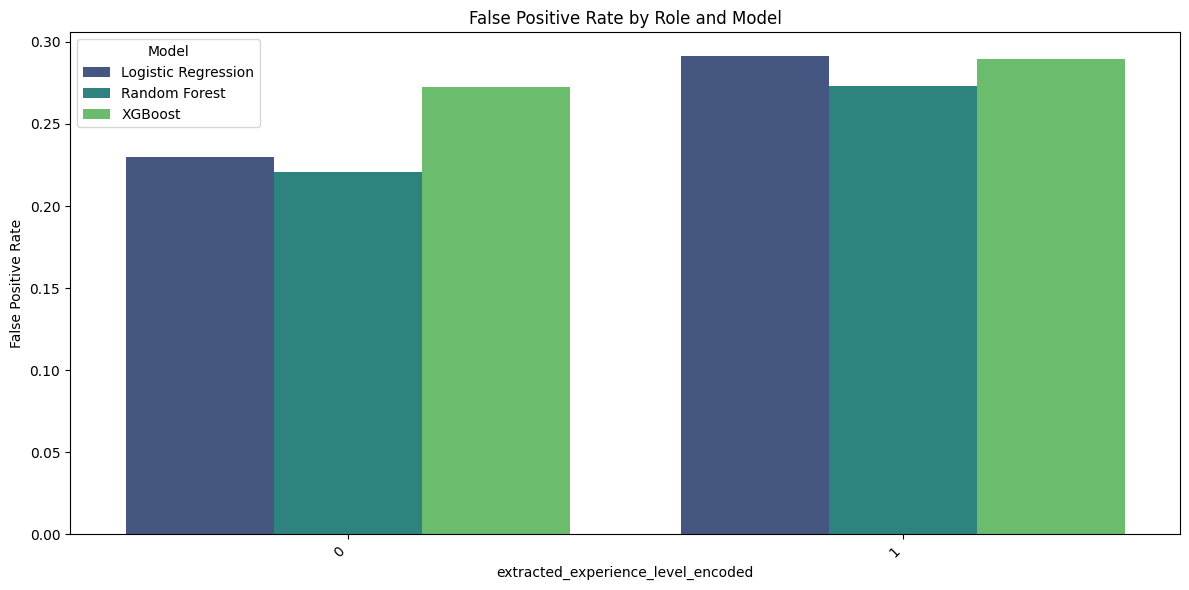


--- Summary of Overall Fairness Metrics (Differences/Ratios) ---
                                            Metric  Logistic Regression  \
0   Demographic Parity Difference (Selection Rate)               0.0378   
1        Demographic Parity Ratio (Selection Rate)               0.9131   
2   Equalized Odds Difference (True Positive Rate)               0.0198   
3        Equalized Odds Ratio (True Positive Rate)               0.9669   
4  Equalized Odds Difference (False Positive Rate)               0.0612   
5       Equalized Odds Ratio (False Positive Rate)               0.7900   

   Random Forest  XGBoost  
0         0.0396   0.0234  
1         0.9144   0.9515  
2         0.0145   0.0087  
3         0.9782   0.9872  
4         0.0522   0.0171  
5         0.8086   0.9410  


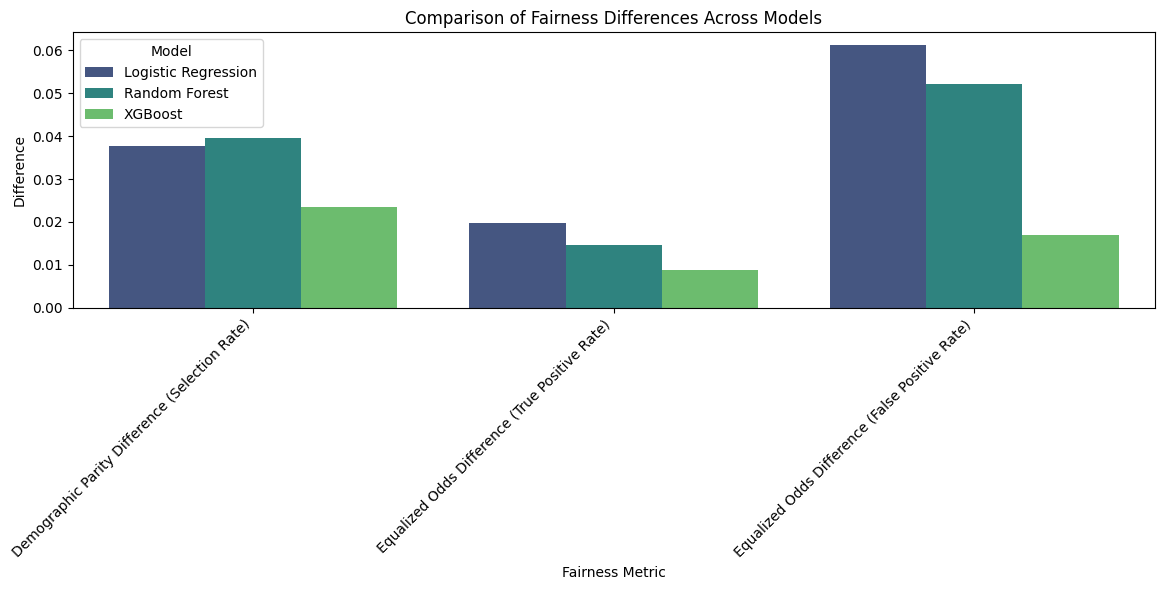

In [ ]:
# Fairness Evaluation

# --- Import Necessary Libraries ---
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Fairlearn imports
from fairlearn.metrics import (
    demographic_parity_difference,
    demographic_parity_ratio,
    equalized_odds_difference,
    equalized_odds_ratio,
    MetricFrame,
)
from fairlearn.metrics import selection_rate, true_positive_rate, false_positive_rate




import seaborn as sns

# --- Load the Processed Data with Labels and Sensitive Attributes ---

labeled_data_path = '/content/drive/MyDrive/Dissertation/processed_data_with_labels.csv'
try:
    df_fairness = pd.read_csv(labeled_data_path)
    print("Processed dataset loaded successfully for fairness evaluation.")
except FileNotFoundError:
    print(f"Error: The file '{labeled_data_path}' was not found. Cannot proceed with fairness evaluation.")



try:
    X_refined_cols_df = pd.read_csv('/content/drive/MyDrive/Dissertation/final_refined_features_dataset.csv')
    final_refined_features = X_refined_cols_df.columns.tolist()
except FileNotFoundError:
    print("Warning: Could not load final_refined_features_dataset.csv to get feature names.")
    print("Using all numeric columns except 'label', 'Role_encoded', 'ID' for fairness features.")

    non_feature_cols = ['label', 'Role_encoded', 'ID', 'Name', 'Role', 'Transcript', 'Resume', 'Reason_for_decision', 'Job_Description', 'cleaned_text']
    numeric_cols = df_fairness.select_dtypes(include=np.number).columns.tolist()
    final_refined_features = [col for col in numeric_cols if col not in non_feature_cols]
    if not final_refined_features:
        print("Error: Failed to identify feature columns for fairness evaluation.")


# Check if df_fairness was loaded successfully before proceeding
if 'df_fairness' not in locals() or df_fairness is None:
    print("Exiting due to failure in loading processed data.")
    exit()


X_fairness = df_fairness[final_refined_features]
y_fairness = df_fairness['label']

# Handle potential NaN/Inf in the selected features
X_fairness = X_fairness.replace([np.inf, -np.inf], np.nan).fillna(X_fairness.mean())


# --- Identify Sensitive Attributes ---

if 'extracted_experience_level_encoded' not in df_fairness.columns:
    print("Error: 'Role' column not found in the dataset for fairness evaluation.")


sensitive_attribute_name = 'extracted_experience_level_encoded'

if df_fairness[sensitive_attribute_name].isnull().any():
    print(f"Warning: Missing values found in sensitive attribute '{sensitive_attribute_name}'. Imputing with mode.")
    mode_val = df_fairness[sensitive_attribute_name].mode()[0]
    df_fairness[sensitive_attribute_name].fillna(mode_val, inplace=True)

sensitive_attribute = df_fairness[sensitive_attribute_name]


# --- Split Data for Fairness Evaluation ---

X_train_fair, X_test_fair, y_train_fair, y_test_fair, sa_train, sa_test = train_test_split(
    X_fairness, y_fairness, sensitive_attribute, test_size=0.25, random_state=42, stratify=y_fairness
)

print(f"\nData split for Fairness Evaluation:")
print(f"Training set shape (features): {X_train_fair.shape}")
print(f"Testing set shape (features): {X_test_fair.shape}")
print(f"Training set shape (labels): {y_train_fair.shape}")
print(f"Testing set shape (labels): {y_test_fair.shape}")
print(f"Training set shape (sensitive attribute): {sa_train.shape}")
print(f"Testing set shape (sensitive attribute): {sa_test.shape}")

# --- Train Models (using the best hyperparameters found previously) ---

print("\n--- Training Models for Fairness Evaluation ---")


try:

    if 'best_log_reg_model' in locals() and best_log_reg_model is not None:
         lr_model_fair = best_log_reg_model
         print("Using tuned Logistic Regression model.")
    else:
        raise NameError

except NameError:
    print("Tuned Logistic Regression model not found or is None. Training a new one with default params.")
    lr_model_fair = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)

lr_model_fair.fit(X_train_fair, y_train_fair)
y_pred_lr_fair = lr_model_fair.predict(X_test_fair)



try:

    if 'best_rf_model' in locals() and best_rf_model is not None:
         rf_model_fair = best_rf_model
         print("Using tuned Random Forest model.")
    else:
        raise NameError

except NameError:
     print("Tuned Random Forest model not found or is None. Training a new one with default params.")
     rf_model_fair = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model_fair.fit(X_train_fair, y_train_fair)
y_pred_rf_fair = rf_model_fair.predict(X_test_fair)


try:

    if 'best_xgb_model' in locals() and best_xgb_model is not None:
        xgb_model_fair = best_xgb_model
        print("Using tuned XGBoost model.")
    else:
        raise NameError

except NameError:
    print("Tuned XGBoost model not found or is None. Training a new one with default params.")

    n_rejected = len(y_train_fair[y_train_fair == 0])
    n_selected = len(y_train_fair[y_train_fair == 1])
    scale_pos_weight_value_fair = n_rejected / n_selected if n_selected > 0 else 1.0
    xgb_model_fair = xgb.XGBClassifier(
        objective='binary:logistic',
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight_value_fair
    )

xgb_model_fair.fit(X_train_fair, y_train_fair)
y_pred_xgb_fair = xgb_model_fair.predict(X_test_fair)


print("\nModels trained on fairness evaluation split.")

# --- Evaluate Fairness using Fairlearn ---

print("\n--- Fairness Evaluation using Fairlearn ---")


basic_fairness_metrics = {
    'selection_rate': selection_rate,
    'true_positive_rate': true_positive_rate,
    'false_positive_rate': false_positive_rate,
}


sa_test_series = pd.Series(sa_test, index=X_test_fair.index, name=sensitive_attribute_name)


# Evaluate fairness for Logistic Regression
print("\nFairness Metrics for Logistic Regression:")
metric_frame_lr = MetricFrame(
    metrics=basic_fairness_metrics,
    y_true=y_test_fair,
    y_pred=y_pred_lr_fair,
    sensitive_features=sa_test_series
)
print("Metrics by group:")
print(metric_frame_lr.by_group)
print("\nOverall Metrics:")
print(metric_frame_lr.overall)
print("\nDifferences and Ratios:")

print("Demographic Parity Difference (Selection Rate):", metric_frame_lr.difference(method='between_groups')['selection_rate'])
print("Demographic Parity Ratio (Selection Rate):", metric_frame_lr.ratio(method='between_groups')['selection_rate'])
print("Equalized Odds Difference (True Positive Rate):", metric_frame_lr.difference(method='between_groups')['true_positive_rate'])
print("Equalized Odds Ratio (True Positive Rate):", metric_frame_lr.ratio(method='between_groups')['true_positive_rate'])
print("Equalized Odds Difference (False Positive Rate):", metric_frame_lr.difference(method='between_groups')['false_positive_rate'])
print("Equalized Odds Ratio (False Positive Rate):", metric_frame_lr.ratio(method='between_groups')['false_positive_rate'])



# Evaluate fairness for Random Forest
print("\nFairness Metrics for Random Forest:")
metric_frame_rf = MetricFrame(
    metrics=basic_fairness_metrics,
    y_true=y_test_fair,
    y_pred=y_pred_rf_fair,
    sensitive_features=sa_test_series
)
print("Metrics by group:")
print(metric_frame_rf.by_group)
print("\nOverall Metrics:")
print(metric_frame_rf.overall)
print("\nDifferences and Ratios:")
print("Demographic Parity Difference (Selection Rate):", metric_frame_rf.difference(method='between_groups')['selection_rate'])
print("Demographic Parity Ratio (Selection Rate):", metric_frame_rf.ratio(method='between_groups')['selection_rate'])
print("Equalized Odds Difference (True Positive Rate):", metric_frame_rf.difference(method='between_groups')['true_positive_rate'])
print("Equalized Odds Ratio (True Positive Rate):", metric_frame_rf.ratio(method='between_groups')['true_positive_rate'])
print("Equalized Odds Difference (False Positive Rate):", metric_frame_rf.difference(method='between_groups')['false_positive_rate'])
print("Equalized Odds Ratio (False Positive Rate):", metric_frame_rf.ratio(method='between_groups')['false_positive_rate'])


# Evaluate fairness for XGBoost
print("\nFairness Metrics for XGBoost:")
metric_frame_xgb = MetricFrame(
    metrics=basic_fairness_metrics,
    y_true=y_test_fair,
    y_pred=y_pred_xgb_fair,
    sensitive_features=sa_test_series
)
print("Metrics by group:")
print(metric_frame_xgb.by_group)
print("\nOverall Metrics:")
print(metric_frame_xgb.overall)
print("\nDifferences and Ratios:")
print("Demographic Parity Difference (Selection Rate):", metric_frame_xgb.difference(method='between_groups')['selection_rate'])
print("Demographic Parity Ratio (Selection Rate):", metric_frame_xgb.ratio(method='between_groups')['selection_rate'])
print("Equalized Odds Difference (True Positive Rate):", metric_frame_xgb.difference(method='between_groups')['true_positive_rate'])
print("Equalized Odds Ratio (True Positive Rate):", metric_frame_xgb.ratio(method='between_groups')['true_positive_rate'])
print("Equalized Odds Difference (False Positive Rate):", metric_frame_xgb.difference(method='between_groups')['false_positive_rate'])
print("Equalized Odds Ratio (False Positive Rate):", metric_frame_xgb.ratio(method='between_groups')['false_positive_rate'])



print("\n--- Visualizing Fairness Metrics ---")


fairness_results_lr = metric_frame_lr.by_group.reset_index().assign(Model='Logistic Regression')
fairness_results_rf = metric_frame_rf.by_group.reset_index().assign(Model='Random Forest')
fairness_results_xgb = metric_frame_xgb.by_group.reset_index().assign(Model='XGBoost')

all_fairness_results = pd.concat([fairness_results_lr, fairness_results_rf, fairness_results_xgb])


all_fairness_results_melted = all_fairness_results.melt(
    id_vars=[sensitive_attribute_name, 'Model'],
    var_name='Metric',
    value_name='Value'
)

# Plotting function
def plot_fairness_metric(df, metric_name, title):

    if metric_name not in df['Metric'].unique():
        print(f"Warning: Metric '{metric_name}' not found in the melted DataFrame. Skipping plot.")
        return

    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=df[df['Metric'] == metric_name],
        x=sensitive_attribute_name,
        y='Value',
        hue='Model',
        palette='viridis'
    )
    plt.title(title)
    plt.xlabel(sensitive_attribute_name)
    plt.ylabel(metric_name.replace('_', ' ').title())
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

plot_fairness_metric(all_fairness_results_melted, 'selection_rate', 'Selection Rate by Role and Model')
plot_fairness_metric(all_fairness_results_melted, 'true_positive_rate', 'True Positive Rate by Role and Model')
plot_fairness_metric(all_fairness_results_melted, 'false_positive_rate', 'False Positive Rate by Role and Model')


summary_metrics_data_full = {
    'Metric': ['Demographic Parity Difference (Selection Rate)', 'Demographic Parity Ratio (Selection Rate)',
               'Equalized Odds Difference (True Positive Rate)', 'Equalized Odds Ratio (True Positive Rate)',
               'Equalized Odds Difference (False Positive Rate)', 'Equalized Odds Ratio (False Positive Rate)'],
    'Logistic Regression': [
        metric_frame_lr.difference(method='between_groups')['selection_rate'],
        metric_frame_lr.ratio(method='between_groups')['selection_rate'],
        metric_frame_lr.difference(method='between_groups')['true_positive_rate'],
        metric_frame_lr.ratio(method='between_groups')['true_positive_rate'],
        metric_frame_lr.difference(method='between_groups')['false_positive_rate'],
        metric_frame_lr.ratio(method='between_groups')['false_positive_rate'],
    ],
    'Random Forest': [
        metric_frame_rf.difference(method='between_groups')['selection_rate'],
        metric_frame_rf.ratio(method='between_groups')['selection_rate'],
        metric_frame_rf.difference(method='between_groups')['true_positive_rate'],
        metric_frame_rf.ratio(method='between_groups')['true_positive_rate'],
        metric_frame_rf.difference(method='between_groups')['false_positive_rate'],
        metric_frame_rf.ratio(method='between_groups')['false_positive_rate'],
    ],
     'XGBoost': [
        metric_frame_xgb.difference(method='between_groups')['selection_rate'],
        metric_frame_xgb.ratio(method='between_groups')['selection_rate'],
        metric_frame_xgb.difference(method='between_groups')['true_positive_rate'],
        metric_frame_xgb.ratio(method='between_groups')['true_positive_rate'],
        metric_frame_xgb.difference(method='between_groups')['false_positive_rate'],
        metric_frame_xgb.ratio(method='between_groups')['false_positive_rate'],
    ]
}


summary_df = pd.DataFrame(summary_metrics_data_full)
print("\n--- Summary of Overall Fairness Metrics (Differences/Ratios) ---")
print(summary_df.round(4))


summary_melted_diff = summary_df[['Metric', 'Logistic Regression', 'Random Forest', 'XGBoost']].melt(
    id_vars='Metric', var_name='Model', value_name='Difference'
)
summary_melted_diff = summary_melted_diff[summary_melted_diff['Metric'].str.contains('Difference')]

plt.figure(figsize=(12, 6))
sns.barplot(data=summary_melted_diff, x='Metric', y='Difference', hue='Model', palette='viridis')
plt.title('Comparison of Fairness Differences Across Models')
plt.xlabel('Fairness Metric')
plt.ylabel('Difference')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Visualizations**

Processed dataset loaded successfully for bias detection visualization.
Refined feature names loaded successfully from /content/drive/MyDrive/Dissertation/final_refined_features_dataset.csv.

--- Training Models ---
Training Logistic Regression Model...
Logistic Regression model trained.

Training Random Forest Model...
Tuned Random Forest model not found. Training a new Random Forest model with default parameters.
Random Forest model trained.

Training XGBoost Model...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [14:52:14] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Tuned XGBoost model not found. Training a new XGBoost model with default parameters.
XGBoost model trained.

--- Calculating Overall Fairness Differences ---

Calculating differences for Logistic Regression...

Calculating differences for Random Forest...

Calculating differences for XGBoost...

--- Overall Fairness Differences Across Models and Sensitive Attributes ---
| Model               | Sensitive Attribute        | Metric                        |   Difference |
|:--------------------|:---------------------------|:------------------------------|-------------:|
| Logistic Regression | Role                       | Demographic Parity Difference |    0.722222  |
| Logistic Regression | Role                       | Equalized Odds Difference     |    0.928571  |
| Logistic Regression | Extracted Education Level  | Demographic Parity Difference |    0.156921  |
| Logistic Regression | Extracted Education Level  | Equalized Odds Difference     |    0.298354  |
| Logistic Regression | Ext

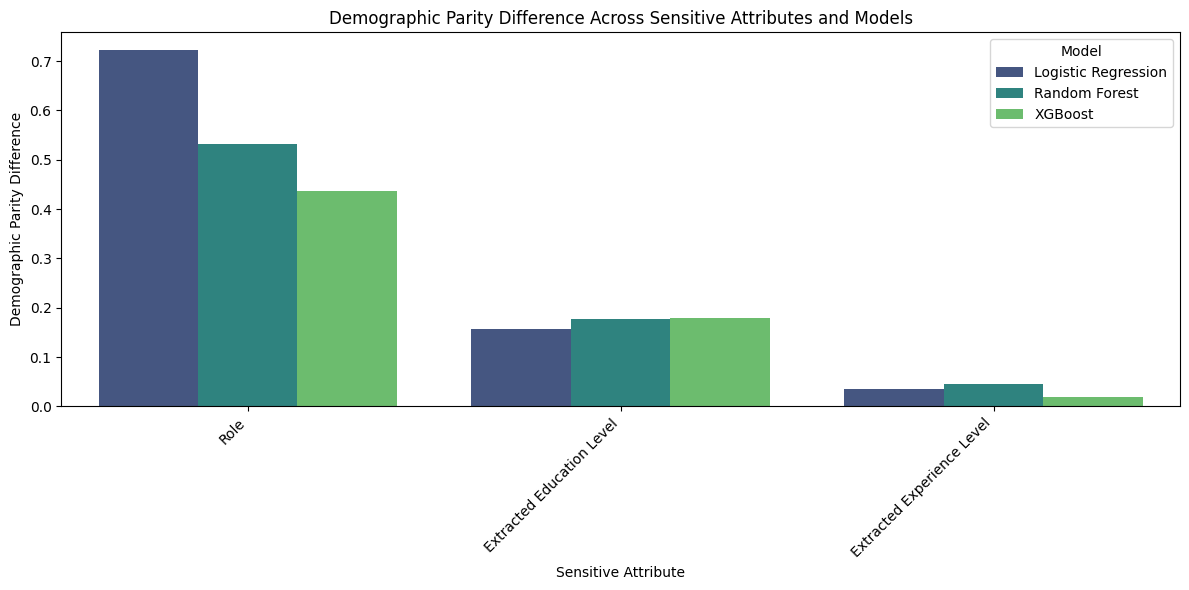

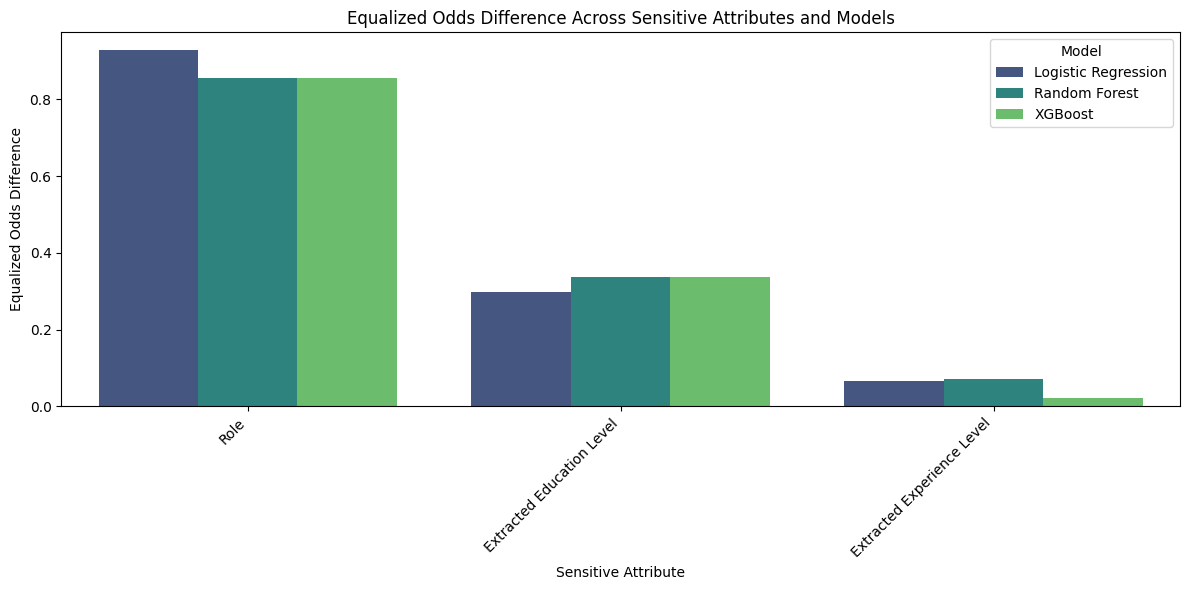

In [ ]:


# --- Import Necessary Libraries ---
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Fairlearn imports
from fairlearn.metrics import (
    demographic_parity_difference,
    equalized_odds_difference,
    MetricFrame,
)
from fairlearn.metrics import selection_rate, true_positive_rate, false_positive_rate
from sklearn.metrics import accuracy_score


import seaborn as sns

# --- Load the Processed Data with Labels and Sensitive Attributes ---
labeled_data_path = '/content/drive/MyDrive/Dissertation/processed_data_with_labels.csv'
try:
    df_fairness = pd.read_csv(labeled_data_path)
    print("Processed dataset loaded successfully for bias detection visualization.")
except FileNotFoundError:
    print(f"Error: The file '{labeled_data_path}' was not found. Cannot proceed with bias detection visualization.")
    exit()


try:
    X_refined_cols_path = '/content/drive/MyDrive/Dissertation/final_refined_features_dataset.csv'
    X_refined_cols_df = pd.read_csv(X_refined_cols_path)
    final_refined_features = X_refined_cols_df.columns.tolist()
    print(f"Refined feature names loaded successfully from {X_refined_cols_path}.")
except FileNotFoundError:
    print(f"Warning: Could not load {X_refined_cols_path} to get feature names.")
    print("Using all numeric columns except specific non-features for fairness features.")

    non_feature_cols_for_fallback = ['label', 'Role_encoded', 'ID', 'Name', 'Role', 'Transcript', 'Resume', 'Reason_for_decision', 'Job_Description', 'cleaned_text', 'extracted_education_level', 'extracted_experience_level', 'extracted_location']
    numeric_cols = df_fairness.select_dtypes(include=np.number).columns.tolist()
    final_refined_features = [col for col in numeric_cols if col not in non_feature_cols_for_fallback]

    if not final_refined_features:
        print("Error: Failed to identify any suitable numeric features for bias detection visualization.")
        exit()

    print(f"Identified {len(final_refined_features)} fallback features.")


# --- Prepare Data for Modeling ---
y = df_fairness['label']
X = df_fairness[final_refined_features].copy()

sensitive_attribute_cols = ['Role_encoded', 'extracted_education_level_encoded', 'extracted_experience_level_encoded']
sa_data = df_fairness[sensitive_attribute_cols].copy()

numeric_cols_in_X = X.select_dtypes(include=np.number).columns
X[numeric_cols_in_X] = X[numeric_cols_in_X].replace([np.inf, -np.inf], np.nan).fillna(X[numeric_cols_in_X].mean())

for col in sa_data.columns:
     if sa_data[col].isnull().any():
        mode_val = sa_data[col].mode().iloc[0]
        sa_data[col].fillna(mode_val, inplace=True)
        print(f"Filled missing values in sensitive attribute '{col}' with mode ({mode_val}).")

# --- Train-Test Split ---
X_aligned, y_aligned = X.align(y, join='inner', axis=0)
X_aligned, sa_data_aligned = X_aligned.align(sa_data, join='inner', axis=0)
y_aligned, sa_data_aligned = y_aligned.align(sa_data_aligned, join='inner', axis=0)


X_train, X_test, y_train, y_test, sa_train, sa_test = train_test_split(
    X_aligned, y_aligned, sa_data_aligned, test_size=0.25, random_state=42, stratify=y_aligned
)

# --- Identify and Exclude Degenerate Groups in the Test Set ---
test_df_combined = X_test.copy()
test_df_combined['label'] = y_test
test_df_combined[['Role_encoded', 'extracted_education_level_encoded', 'extracted_experience_level_encoded']] = sa_test.values

degenerate_group_indices = []
grouped_by_sa = test_df_combined.groupby(['Role_encoded', 'extracted_education_level_encoded', 'extracted_experience_level_encoded'])

for name, group in grouped_by_sa:
    if group['label'].nunique() <= 1:
        degenerate_group_indices.extend(group.index.tolist())


X_test_filtered = X_test.drop(index=degenerate_group_indices)
y_test_filtered = y_test.drop(index=degenerate_group_indices)
sa_test_filtered = sa_test.drop(index=degenerate_group_indices)


# --- Train Models (Using Default Parameters or Tuned Models if Available) ---
print("\n--- Training Models ---")

# Logistic Regression
print("Training Logistic Regression Model...")
model_lr = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)
model_lr.fit(X_train, y_train)
print("Logistic Regression model trained.")

# Random Forest
print("\nTraining Random Forest Model...")
try:
    if 'best_rf_model' in globals() and best_rf_model is not None:
        model_rf = best_rf_model
        print("Using the best tuned Random Forest model found previously.")
    else:
        model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
        model_rf.fit(X_train, y_train)
        print("Tuned Random Forest model not found. Training a new Random Forest model with default parameters.")
except NameError:
    model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
    model_rf.fit(X_train, y_train)
    print("Tuned Random Forest model not found. Training a new Random Forest model with default parameters.")
print("Random Forest model trained.")


# XGBoost
print("\nTraining XGBoost Model...")
try:
    if 'best_xgb_model' in globals() and best_xgb_model is not None:
         model_xgb = best_xgb_model
         print("Using the best tuned XGBoost model found previously.")
    else:
        n_rejected = len(y_train[y_train == 0])
        n_selected = len(y_train[y_train == 1])
        scale_pos_weight_value = n_rejected / n_selected if n_selected > 0 else 1.0
        model_xgb = xgb.XGBClassifier(
            objective='binary:logistic',
            random_state=42,
            use_label_encoder=False,
            eval_metric='logloss',
            scale_pos_weight=scale_pos_weight_value
        )
        model_xgb.fit(X_train, y_train)
        print("Tuned XGBoost model not found. Training a new XGBoost model with default parameters.")
except NameError:
    n_rejected = len(y_train[y_train == 0])
    n_selected = len(y_train[y_train == 1])
    scale_pos_weight_value = n_rejected / n_selected if n_selected > 0 else 1.0
    model_xgb = xgb.XGBClassifier(
        objective='binary:logistic',
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight_value
    )
    model_xgb.fit(X_train, y_train)
    print("Tuned XGBoost model not found. Training a new XGBoost model with default parameters.")
print("XGBoost model trained.")


# --- Calculate and Store Overall Fairness Difference Metrics ---
print("\n--- Calculating Overall Fairness Differences ---")

models_to_evaluate = {
    'Logistic Regression': model_lr,
    'Random Forest': model_rf,
    'XGBoost': model_xgb
}

sensitive_attribute_names = ['Role_encoded', 'extracted_education_level_encoded', 'extracted_experience_level_encoded']

overall_fairness_differences = []

for model_name, model in models_to_evaluate.items():
    print(f"\nCalculating differences for {model_name}...")
    # Get predictions for the current model on the filtered test set
    y_pred = model.predict(X_test_filtered)

    for sensitive_attr in sensitive_attribute_names:
        if sensitive_attr not in sa_test_filtered.columns:
            print(f"Warning: Sensitive attribute '{sensitive_attr}' not found in sa_test_filtered. Skipping difference calculation.")
            continue

        sa_test_current = sa_test_filtered[sensitive_attr]

        try:
            # Calculate Demographic Parity Difference
            dpd = demographic_parity_difference(y_test_filtered, y_pred, sensitive_features=sa_test_current)

            # Calculate Equalized Odds Difference
            eod = equalized_odds_difference(y_test_filtered, y_pred, sensitive_features=sa_test_current)

            overall_fairness_differences.append({
                'Model': model_name,
                'Sensitive Attribute': sensitive_attr.replace('_encoded', '').replace('_', ' ').title(),
                'Metric': 'Demographic Parity Difference',
                'Difference': dpd
            })
            overall_fairness_differences.append({
                'Model': model_name,
                'Sensitive Attribute': sensitive_attr.replace('_encoded', '').replace('_', ' ').title(),
                'Metric': 'Equalized Odds Difference',
                'Difference': eod
            })

        except Exception as e:
            print(f"Could not calculate fairness differences for {model_name} on {sensitive_attr}. Error: {e}")
            overall_fairness_differences.append({
                'Model': model_name,
                'Sensitive Attribute': sensitive_attr.replace('_encoded', '').replace('_', ' ').title(),
                'Metric': 'Demographic Parity Difference',
                'Difference': f"Error: {e}"
            })
            overall_fairness_differences.append({
                'Model': model_name,
                'Sensitive Attribute': sensitive_attr.replace('_encoded', '').replace('_', ' ').title(),
                'Metric': 'Equalized Odds Difference',
                'Difference': f"Error: {e}"
            })


# Create a DataFrame from the results
overall_differences_df = pd.DataFrame(overall_fairness_differences)

print("\n--- Overall Fairness Differences Across Models and Sensitive Attributes ---")
print(overall_differences_df.to_markdown(index=False))


# --- Visualize Overall Fairness Differences ---
print("\n--- Visualizing Overall Fairness Differences ---")

# Plot Demographic Parity Difference
plt.figure(figsize=(12, 6))
sns.barplot(
    data=overall_differences_df[overall_differences_df['Metric'] == 'Demographic Parity Difference'],
    x='Sensitive Attribute',
    y='Difference',
    hue='Model',
    palette='viridis'
)
plt.title('Demographic Parity Difference Across Sensitive Attributes and Models')
plt.ylabel('Demographic Parity Difference')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plot Equalized Odds Difference
plt.figure(figsize=(12, 6))
sns.barplot(
    data=overall_differences_df[overall_differences_df['Metric'] == 'Equalized Odds Difference'],
    x='Sensitive Attribute',
    y='Difference',
    hue='Model',
    palette='viridis'
)
plt.title('Equalized Odds Difference Across Sensitive Attributes and Models')
plt.ylabel('Equalized Odds Difference')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


--- Aggregating Fairness Differences by Sensitive Attribute Across Models ---

Aggregated Bias (Mean Difference Across Models):
| Sensitive Attribute        | Metric                        |   Difference |
|:---------------------------|:------------------------------|-------------:|
| Extracted Education Level  | Demographic Parity Difference |    0.171387  |
| Extracted Education Level  | Equalized Odds Difference     |    0.324451  |
| Extracted Experience Level | Demographic Parity Difference |    0.0338499 |
| Extracted Experience Level | Equalized Odds Difference     |    0.0522761 |
| Role                       | Demographic Parity Difference |    0.563751  |
| Role                       | Equalized Odds Difference     |    0.880952  |

--- Visualizing Aggregated Bias Across Sensitive Attributes ---


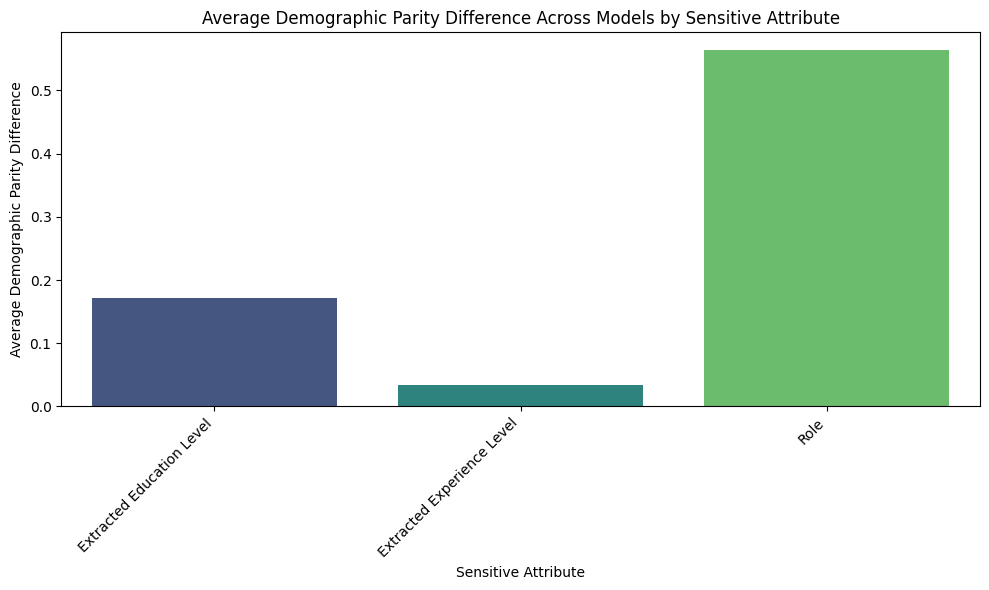

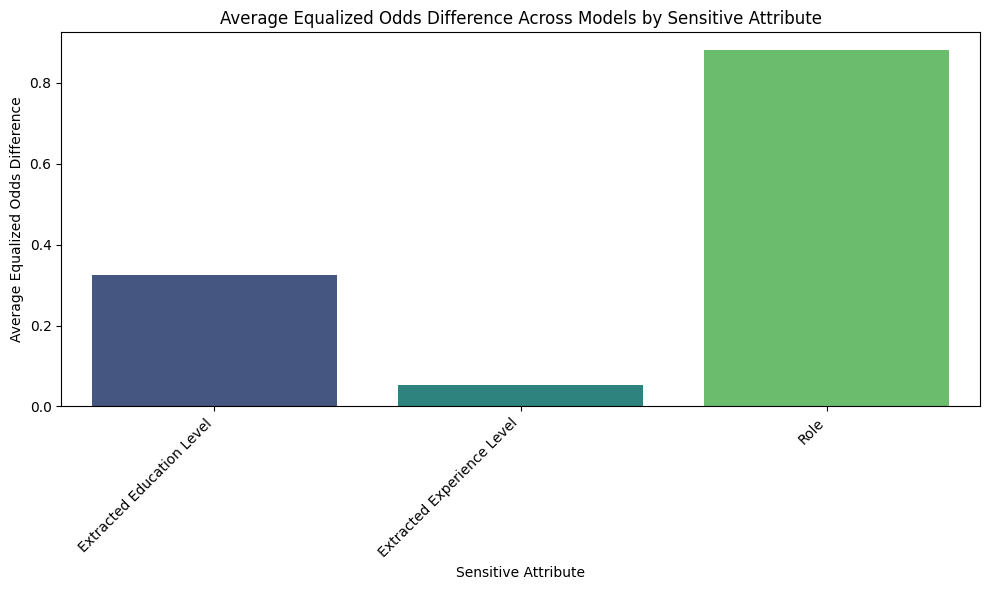


--- Ranking Sensitive Attributes by Average Bias Across Models ---

Ranking (Based on Average of Demographic Parity and Equalized Odds Differences):
| Sensitive Attribute        |   Average Difference |
|:---------------------------|---------------------:|
| Role                       |             0.722352 |
| Extracted Education Level  |             0.247919 |
| Extracted Experience Level |             0.043063 |

Summary of Bias Ranking Across Models:
Most Biased Attribute: Role
Moderate Biased Attribute: Extracted Education Level
Least Biased Attribute: Extracted Experience Level


In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Aggregating Fairness Differences by Sensitive Attribute Across Models ---")


if 'overall_differences_df' not in locals():
    print("Error: 'overall_differences_df' not found. Please run the previous cell (Ox0ceS90y_Ja) first.")

    pass


# Filter for difference metrics only
difference_metrics_df = overall_differences_df[
    overall_differences_df['Metric'].isin(['Demographic Parity Difference', 'Equalized Odds Difference'])
].copy()

# Aggregate by 'Sensitive Attribute' and 'Metric', calculating the mean Difference across models
aggregated_bias = difference_metrics_df.groupby(['Sensitive Attribute', 'Metric'])['Difference'].mean().reset_index()

print("\nAggregated Bias (Mean Difference Across Models):")
print(aggregated_bias.to_markdown(index=False))


# --- Visualize Aggregated Bias ---
print("\n--- Visualizing Aggregated Bias Across Sensitive Attributes ---")

# Plot aggregated Demographic Parity Difference
plt.figure(figsize=(10, 6))
sns.barplot(
    data=aggregated_bias[aggregated_bias['Metric'] == 'Demographic Parity Difference'],
    x='Sensitive Attribute',
    y='Difference',
    hue='Sensitive Attribute',
    palette='viridis',
    legend=False
)
plt.title('Average Demographic Parity Difference Across Models by Sensitive Attribute')
plt.ylabel('Average Demographic Parity Difference')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plot aggregated Equalized Odds Difference
plt.figure(figsize=(10, 6))
sns.barplot(
    data=aggregated_bias[aggregated_bias['Metric'] == 'Equalized Odds Difference'],
    x='Sensitive Attribute',
    y='Difference',
    hue='Sensitive Attribute',
    palette='viridis',
    legend=False
)
plt.title('Average Equalized Odds Difference Across Models by Sensitive Attribute')
plt.ylabel('Average Equalized Odds Difference')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# --- Rank Sensitive Attributes by Bias ---
print("\n--- Ranking Sensitive Attributes by Average Bias Across Models ---")

aggregated_bias['Average Difference'] = aggregated_bias.groupby('Sensitive Attribute')['Difference'].transform('mean')

# Get unique attributes and their average differences
attribute_average_bias = aggregated_bias[['Sensitive Attribute', 'Average Difference']].drop_duplicates()

# Sort by average difference to rank
ranked_attributes = attribute_average_bias.sort_values(by='Average Difference', ascending=False).reset_index(drop=True)

print("\nRanking (Based on Average of Demographic Parity and Equalized Odds Differences):")
print(ranked_attributes.to_markdown(index=False))

# Determine most, moderate, and least biased (assuming 3 attributes)
if len(ranked_attributes) >= 3:
    most_biased = ranked_attributes.iloc[0]['Sensitive Attribute']
    least_biased = ranked_attributes.iloc[-1]['Sensitive Attribute']

    moderate_biased = ranked_attributes[~ranked_attributes['Sensitive Attribute'].isin([most_biased, least_biased])]['Sensitive Attribute'].iloc[0]

    print(f"\nSummary of Bias Ranking Across Models:")
    print(f"Most Biased Attribute: {most_biased}")
    print(f"Moderate Biased Attribute: {moderate_biased}")
    print(f"Least Biased Attribute: {least_biased}")
elif len(ranked_attributes) > 0:
     print("\nSummary of Bias Ranking Across Models:")
     print("Could not determine most, moderate, and least biased attributes as there are less than 3 attributes with calculated differences.")
     print("Attributes with calculated differences:", ranked_attributes['Sensitive Attribute'].tolist())
else:
    print("\nNo sensitive attributes with calculated fairness differences to rank.")

**BIAS MTIGATION**

Data loaded successfully for bias mitigation.

Original test set size: 1876
Number of data points in degenerate groups: 63
Filtered test set size (excluding degenerate groups): 1813

--- Training Models for Mitigation ---
Training Logistic Regression Model...
Logistic Regression model trained.

Training Random Forest Model...
Tuned Random Forest model not found. Training a new Random Forest model with default parameters.
Random Forest model trained.

Training XGBoost Model...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [14:52:35] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Tuned XGBoost model not found. Training a new XGBoost model with default parameters.
XGBoost model trained.

--- Applying ThresholdOptimizer and Evaluating Bias Mitigation ---

--- Mitigating and Evaluating Logistic Regression ---

Applying mitigation for sensitive attribute: Role_encoded
Mitigation applied for Role_encoded.

Applying mitigation for sensitive attribute: extracted_education_level_encoded
Mitigation applied for extracted_education_level_encoded.

Applying mitigation for sensitive attribute: extracted_experience_level_encoded
Mitigation applied for extracted_experience_level_encoded.

--- Mitigating and Evaluating Random Forest ---

Applying mitigation for sensitive attribute: Role_encoded
Mitigation applied for Role_encoded.

Applying mitigation for sensitive attribute: extracted_education_level_encoded
Mitigation applied for extracted_education_level_encoded.

Applying mitigation for sensitive attribute: extracted_experience_level_encoded
Mitigation applied for extracte

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [14:52:49] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Mitigation applied for Role_encoded.

Applying mitigation for sensitive attribute: extracted_education_level_encoded


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [14:52:57] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Mitigation applied for extracted_education_level_encoded.

Applying mitigation for sensitive attribute: extracted_experience_level_encoded


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [14:52:58] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Mitigation applied for extracted_experience_level_encoded.

--- Bias Mitigation Comparison Results (Filtered Test Set) ---
| Model               | Sensitive Attribute        | Metric                        |   Before Mitigation |   After Mitigation |
|:--------------------|:---------------------------|:------------------------------|--------------------:|-------------------:|
| Logistic Regression | Role                       | Accuracy                      |           0.65968   |         0.54385    |
| Logistic Regression | Role                       | Demographic Parity Difference |           0.722222  |         0.333333   |
| Logistic Regression | Role                       | Equalized Odds Difference     |           0.928571  |         0.5        |
| Logistic Regression | Extracted Education Level  | Accuracy                      |           0.65968   |         0.6139     |
| Logistic Regression | Extracted Education Level  | Demographic Parity Difference |           0.156921  |   

<Figure size 1400x700 with 0 Axes>

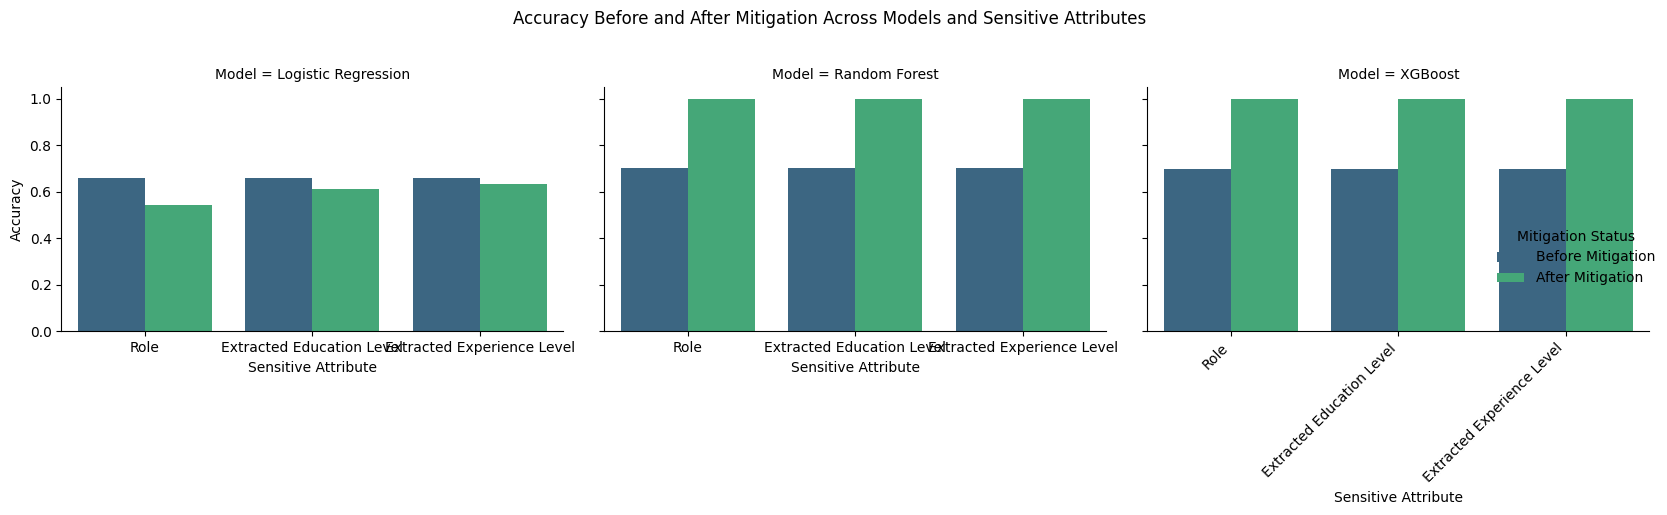

<Figure size 1400x700 with 0 Axes>

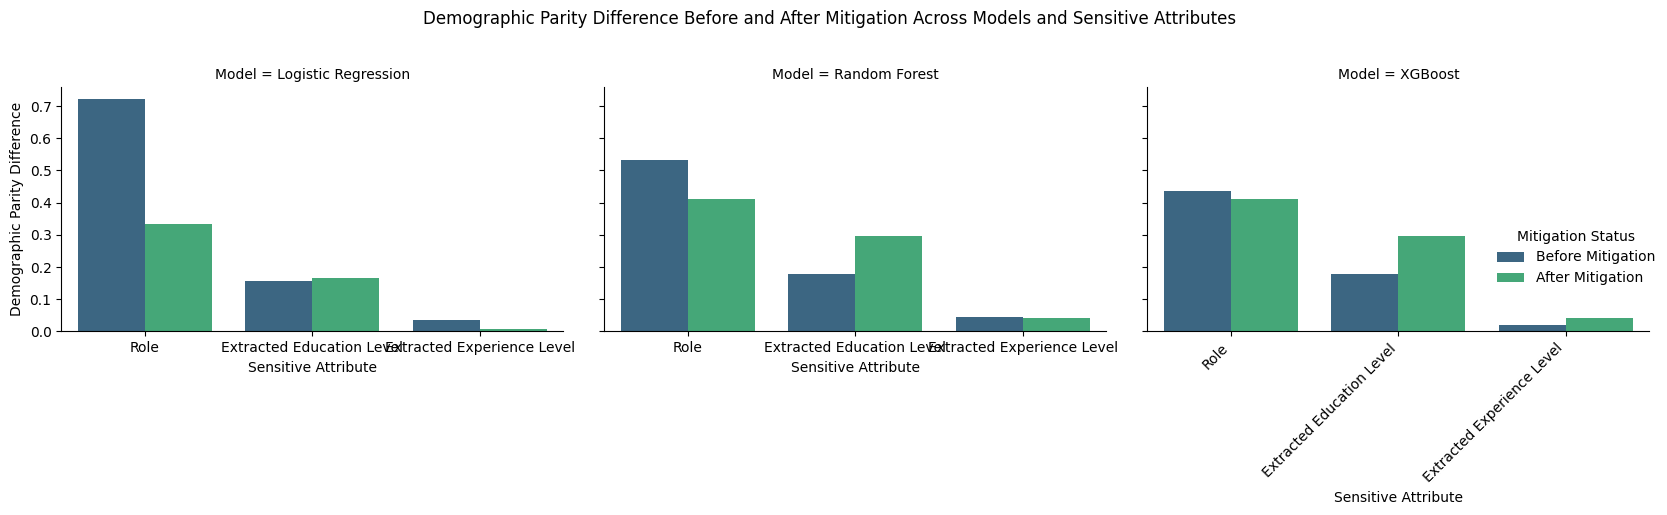

<Figure size 1400x700 with 0 Axes>

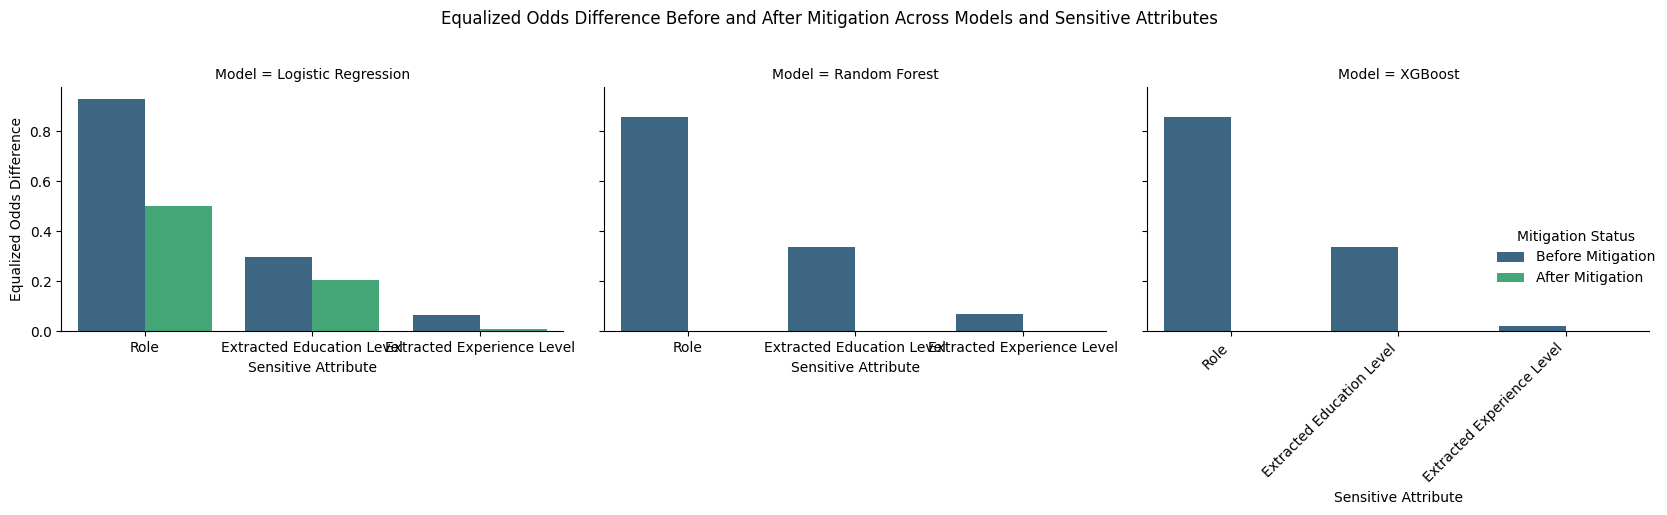

In [ ]:
# Bias Mitigation using Fairlearn's ThresholdOptimizer (Post-processing) for Logistic Regression, Random Forest, and XGBoost

# --- Import Libraries ---
from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.metrics import MetricFrame, demographic_parity_difference, equalized_odds_difference, selection_rate, true_positive_rate, false_positive_rate
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score

# Import warnings module
import warnings

# Filter out the specific UserWarning from XGBoost related to use_label_encoder
warnings.filterwarnings("ignore", category=UserWarning, module='xgboost', message=".*use_label_encoder.*")
# Filter out the specific FutureWarning from fairlearn/pandas
warnings.filterwarnings("ignore", category=FutureWarning, message="Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas.")


try:
    X = pd.read_csv('/content/drive/MyDrive/Dissertation/final_refined_features_dataset.csv')
    labeled_data_path = '/content/drive/MyDrive/Dissertation/processed_data_with_labels.csv'
    df_labeled = pd.read_csv(labeled_data_path)
    y = df_labeled['label']
    print("Data loaded successfully for bias mitigation.")
except FileNotFoundError:
    print("Error: Could not load necessary data files. Please ensure 'final_refined_features_dataset.csv' and 'processed_data_with_labels.csv' exist.")
    exit()


df_labeled['Role_encoded'] = LabelEncoder().fit_transform(df_labeled['Role'])
df_labeled['extracted_education_level_encoded'] = LabelEncoder().fit_transform(df_labeled['extracted_education_level'])
df_labeled['extracted_experience_level_encoded'] = LabelEncoder().fit_transform(df_labeled['extracted_experience_level'])


# --- Train-Test Split (maintaining original split for consistency) ---
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df_labeled.index, test_size=0.25, random_state=42, stratify=y
)

# Extract sensitive attributes for the test set based on the index
sensitive_attribute_cols = ['Role_encoded', 'extracted_education_level_encoded', 'extracted_experience_level_encoded']
sa_test = df_labeled.loc[idx_test, sensitive_attribute_cols]


# --- Identify and Exclude Degenerate Groups in the Test Set ---
# Create a combined DataFrame for the test set including labels and sensitive attributes
test_df_combined = X_test.copy()
test_df_combined['label'] = y_test
test_df_combined[['Role_encoded', 'extracted_education_level_encoded', 'extracted_experience_level_encoded']] = sa_test.values

# Identify groups with only one label
degenerate_group_indices = []
grouped_by_sa = test_df_combined.groupby(['Role_encoded', 'extracted_education_level_encoded', 'extracted_experience_level_encoded'])

for name, group in grouped_by_sa:
    if group['label'].nunique() <= 1:
        degenerate_group_indices.extend(group.index.tolist())



# Exclude degenerate group indices from the test set for fairness evaluation
X_test_filtered = X_test.drop(index=degenerate_group_indices)
y_test_filtered = y_test.drop(index=degenerate_group_indices)
sa_test_filtered = sa_test.drop(index=degenerate_group_indices)

print(f"\nOriginal test set size: {len(y_test)}")
print(f"Number of data points in degenerate groups: {len(degenerate_group_indices)}")
print(f"Filtered test set size (excluding degenerate groups): {len(y_test_filtered)}")


print("\n--- Training Models for Mitigation ---")

# Logistic Regression
print("Training Logistic Regression Model...")
model_lr = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)
model_lr.fit(X_train, y_train)
print("Logistic Regression model trained.")

# Random Forest
print("\nTraining Random Forest Model...")
try:
    if 'best_rf_model' in globals() and best_rf_model is not None:
        model_rf = best_rf_model
        print("Using the best tuned Random Forest model found previously.")
    else:
        model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
        model_rf.fit(X_train, y_train)
        print("Tuned Random Forest model not found. Training a new Random Forest model with default parameters.")
except NameError:
    model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
    model_rf.fit(X_train, y_train)
    print("Tuned Random Forest model not found. Training a new Random Forest model with default parameters.")
print("Random Forest model trained.")


# XGBoost
print("\nTraining XGBoost Model...")
try:
    if 'best_xgb_model' in globals() and best_xgb_model is not None:
         model_xgb = best_xgb_model
         print("Using the best tuned XGBoost model found previously.")
    else:
        n_rejected = len(y_train[y_train == 0])
        n_selected = len(y_train[y_train == 1])
        scale_pos_weight_value = n_rejected / n_selected if n_selected > 0 else 1.0
        model_xgb = xgb.XGBClassifier(
            objective='binary:logistic',
            random_state=42,
            use_label_encoder=False,
            eval_metric='logloss',
            scale_pos_weight=scale_pos_weight_value
        )
        model_xgb.fit(X_train, y_train)
        print("Tuned XGBoost model not found. Training a new XGBoost model with default parameters.")
except NameError:
    n_rejected = len(y_train[y_train == 0])
    n_selected = len(y_train[y_train == 1])
    scale_pos_weight_value = n_rejected / n_selected if n_selected > 0 else 1.0
    model_xgb = xgb.XGBClassifier(
        objective='binary:logistic',
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight_value
    )
    model_xgb.fit(X_train, y_train)
    print("Tuned XGBoost model not found. Training a new XGBoost model with default parameters.")
print("XGBoost model trained.")



# --- Applied Post-processing Mitigation using ThresholdOptimizer ---
print("\n--- Applying ThresholdOptimizer and Evaluating Bias Mitigation ---")

models_to_mitigate = {
    'Logistic Regression': model_lr,
    'Random Forest': model_rf,
    'XGBoost': model_xgb
}

sensitive_attribute_names = ['Role_encoded', 'extracted_education_level_encoded', 'extracted_experience_level_encoded']

mitigation_comparison_results = []

# Iterate through each model
for model_name, base_model in models_to_mitigate.items():
    print(f"\n--- Mitigating and Evaluating {model_name} ---")

    # Get base model predictions and probabilities on the filtered test set
    y_pred_base = base_model.predict(X_test_filtered)
    y_prob_base = base_model.predict_proba(X_test_filtered)[:, 1]


    # Apply ThresholdOptimizer for each sensitive attribute and evaluate
    for sensitive_attr in sensitive_attribute_names:
        print(f"\nApplying mitigation for sensitive attribute: {sensitive_attr}")

        if sensitive_attr not in sa_test_filtered.columns:
             print(f"Warning: Sensitive attribute '{sensitive_attr}' not found in sa_test_filtered. Skipping mitigation for this attribute.")
             continue

        # Explicitly align the sensitive attribute Series with the filtered test set data
        sa_test_current = sa_test_filtered[sensitive_attr].align(y_test_filtered, join='inner')[0]


        try:
            # Initialize and fit ThresholdOptimizer
            postprocessed_model = ThresholdOptimizer(
                estimator=base_model,
                constraints="equalized_odds",
                predict_method="predict_proba"
            )
            # Fit on the filtered test set
            # Ensure X_test_filtered and y_test_filtered are passed correctly
            postprocessed_model.fit(X_test_filtered, y_test_filtered, sensitive_features=sa_test_current)

            # Get mitigated predictions on the filtered test set
            y_pred_mitigated = postprocessed_model.predict(X_test_filtered, sensitive_features=sa_test_current)

            print(f"Mitigation applied for {sensitive_attr}.")

            # --- Evaluate Metrics BEFORE Mitigation (on filtered data) ---
            metrics_before = MetricFrame(
                metrics={
                    "accuracy": accuracy_score,
                    "selection_rate": selection_rate,
                    "true_positive_rate": true_positive_rate,
                    "false_positive_rate": false_positive_rate
                },
                y_true=y_test_filtered,
                y_pred=y_pred_base,
                sensitive_features=sa_test_current
            )

            acc_before = metrics_before.overall['accuracy']
            dpd_before = metrics_before.difference(method="between_groups")["selection_rate"]
            eod_before = equalized_odds_difference(y_test_filtered, y_pred_base, sensitive_features=sa_test_current)


            # --- Evaluate Metrics AFTER Mitigation (on filtered data) ---
            metrics_after = MetricFrame(
                 metrics={
                    "accuracy": accuracy_score,
                    "selection_rate": selection_rate,
                    "true_positive_rate": true_positive_rate,
                    "false_positive_rate": false_positive_rate
                },
                y_true=y_test_filtered,
                y_pred=y_pred_mitigated,
                sensitive_features=sa_test_current
            )

            acc_after = metrics_after.overall['accuracy']
            dpd_after = metrics_after.difference(method="between_groups")["selection_rate"]
            eod_after = equalized_odds_difference(y_test_filtered, y_pred_mitigated, sensitive_features=sa_test_current)


            # Store comparison results
            mitigation_comparison_results.append({
                'Model': model_name,
                'Sensitive Attribute': sensitive_attr.replace('_encoded', '').replace('_', ' ').title(),
                'Metric': 'Accuracy',
                'Before Mitigation': acc_before,
                'After Mitigation': acc_after
            })
            mitigation_comparison_results.append({
                'Model': model_name,
                'Sensitive Attribute': sensitive_attr.replace('_encoded', '').replace('_', ' ').title(),
                'Metric': 'Demographic Parity Difference',
                'Before Mitigation': dpd_before,
                'After Mitigation': dpd_after
            })
            mitigation_comparison_results.append({
                'Model': model_name,
                'Sensitive Attribute': sensitive_attr.replace('_encoded', '').replace('_', ' ').title(),
                'Metric': 'Equalized Odds Difference',
                'Before Mitigation': eod_before,
                'After Mitigation': eod_after
            })

        except Exception as e:
            print(f"Could not apply mitigation or calculate metrics for {model_name} on {sensitive_attr}. Error: {e}")

            mitigation_comparison_results.append({
                'Model': model_name,
                'Sensitive Attribute': sensitive_attr.replace('_encoded', '').replace('_', ' ').title(),
                'Metric': 'Accuracy',
                'Before Mitigation': 'N/A',
                'After Mitigation': f"Error: {e}"
            })
            mitigation_comparison_results.append({
                'Model': model_name,
                'Sensitive Attribute': sensitive_attr.replace('_encoded', '').replace('_', ' ').title(),
                'Metric': 'Demographic Parity Difference',
                'Before Mitigation': 'N/A',
                'After Mitigation': f"Error: {e}"
            })
            mitigation_comparison_results.append({
                'Model': model_name,
                'Sensitive Attribute': sensitive_attr.replace('_encoded', '').replace('_', ' ').title(),
                'Metric': 'Equalized Odds Difference',
                'Before Mitigation': 'N/A',
                'After Mitigation': f"Error: {e}"
            })



# Display mitigation comparison results in a DataFrame
mitigation_comparison_df = pd.DataFrame(mitigation_comparison_results)

print("\n--- Bias Mitigation Comparison Results (Filtered Test Set) ---")
print(mitigation_comparison_df.to_markdown(index=False))


print("\n--- Visualizing Bias Mitigation Impact (Filtered Test Set) ---")

# Separate data for plotting
accuracy_comparison = mitigation_comparison_df[mitigation_comparison_df['Metric'] == 'Accuracy'].copy()
dpd_comparison = mitigation_comparison_df[mitigation_comparison_df['Metric'] == 'Demographic Parity Difference'].copy()
eod_comparison = mitigation_comparison_df[mitigation_comparison_df['Metric'] == 'Equalized Odds Difference'].copy()



accuracy_melted = accuracy_comparison.melt(
    id_vars=['Model', 'Sensitive Attribute', 'Metric'],
    var_name='Mitigation Status',
    value_name='Value'
)

dpd_melted = dpd_comparison.melt(
    id_vars=['Model', 'Sensitive Attribute', 'Metric'],
    var_name='Mitigation Status',
    value_name='Value'
)

eod_melted = eod_comparison.melt(
    id_vars=['Model', 'Sensitive Attribute', 'Metric'],
    var_name='Mitigation Status',
    value_name='Value'
)


# Plot Accuracy Comparison
plt.figure(figsize=(14, 7))
g = sns.catplot(data=accuracy_melted, x='Sensitive Attribute', y='Value', hue='Mitigation Status', col='Model', palette='viridis', kind='bar')
g.fig.suptitle('Accuracy Before and After Mitigation Across Models and Sensitive Attributes', y=1.02)
g.set_axis_labels("Sensitive Attribute", "Accuracy")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# Plot Demographic Parity Difference Comparison
plt.figure(figsize=(14, 7))
g = sns.catplot(data=dpd_melted, x='Sensitive Attribute', y='Value', hue='Mitigation Status', col='Model', palette='viridis', kind='bar')
g.fig.suptitle('Demographic Parity Difference Before and After Mitigation Across Models and Sensitive Attributes', y=1.02)
g.set_axis_labels("Sensitive Attribute", "Demographic Parity Difference")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Plot Equalized Odds Difference Comparison
plt.figure(figsize=(14, 7))
g = sns.catplot(data=eod_melted, x='Sensitive Attribute', y='Value', hue='Mitigation Status', col='Model', palette='viridis', kind='bar')
g.fig.suptitle('Equalized Odds Difference Before and After Mitigation Across Models and Sensitive Attributes', y=1.02)
g.set_axis_labels("Sensitive Attribute", "Equalized Odds Difference")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Analyze and display which model works best based on accuracy and fairness after mitigation

print("\n--- Evaluating Best Model After Bias Mitigation (Considering Accuracy and Fairness) ---")


if 'mitigation_comparison_df' not in locals():
    print("Error: 'mitigation_comparison_df' not found. Please run the previous cell (2otXqxx62O9U) first.")
else:

    after_mitigation_results = mitigation_comparison_df.copy()




    pivot_results = after_mitigation_results.pivot_table(
        index=['Model', 'Sensitive Attribute'],
        columns='Metric',
        values='After Mitigation'
    ).reset_index()

    print("\nPerformance Metrics After Bias Mitigation:")
    print(pivot_results.to_markdown(index=False, floatfmt=".4f"))

    # Calculate average metrics across sensitive attributes for each model for an overall comparison
    average_performance_after_mitigation = pivot_results.groupby('Model')[
        ['Accuracy', 'Demographic Parity Difference', 'Equalized Odds Difference']
    ].mean().reset_index()


    # Rename columns for clarity in the overall summary
    average_performance_after_mitigation = average_performance_after_mitigation.rename(columns={
        'Demographic Parity Difference': 'Avg Demographic Parity Diff',
        'Equalized Odds Difference': 'Avg Equalized Odds Diff'
    })

    print("\nAverage Performance Metrics Across Sensitive Attributes After Bias Mitigation:")
    print(average_performance_after_mitigation.to_markdown(index=False, floatfmt=".4f"))


    normalized_dpd = average_performance_after_mitigation['Avg Demographic Parity Diff'] / average_performance_after_mitigation['Avg Demographic Parity Diff'].max()
    normalized_eod = average_performance_after_mitigation['Avg Equalized Odds Diff'] / average_performance_after_mitigation['Avg Equalized Odds Diff'].max()

    # Rank by Accuracy (descending, higher is better)
    average_performance_after_mitigation['Accuracy_Rank'] = average_performance_after_mitigation['Accuracy'].rank(ascending=False)

    # Rank by Normalized Differences (ascending, lower is better)
    average_performance_after_mitigation['Avg Demographic Parity Diff_Rank'] = normalized_dpd.rank(ascending=True)
    average_performance_after_mitigation['Avg Equalized Odds Diff_Rank'] = normalized_eod.rank(ascending=True)


    # Calculate a combined rank (lower is better)
    average_performance_after_mitigation['Combined_Rank'] = (
        average_performance_after_mitigation['Accuracy_Rank'] +
        average_performance_after_mitigation['Avg Demographic Parity Diff_Rank'] +
        average_performance_after_mitigation['Avg Equalized Odds Diff_Rank']
    )

    # Sort by combined rank
    ranked_models = average_performance_after_mitigation.sort_values(by='Combined_Rank').reset_index(drop=True)

    print("\nModel Ranking Based on Average Performance After Bias Mitigation (Lower Combined Rank is Better):")
    print(ranked_models[['Model', 'Accuracy', 'Avg Demographic Parity Diff', 'Avg Equalized Odds Diff', 'Combined_Rank']].to_markdown(index=False, floatfmt=".4f"))

    # Final conclusion based on the ranking
    if not ranked_models.empty:
        best_model = ranked_models.iloc[0]['Model']
        print(f"\nBased on the average performance across sensitive attributes after bias mitigation (considering accuracy and fairness differences), the **{best_model}** appears to be the best performing model.")
    else:
        print("\nCould not determine the best model based on the available data.")


--- Evaluating Best Model After Bias Mitigation (Considering Accuracy and Fairness) ---

Performance Metrics After Bias Mitigation:
| Model               | Sensitive Attribute        |   Accuracy |   Demographic Parity Difference |   Equalized Odds Difference |
|:--------------------|:---------------------------|-----------:|--------------------------------:|----------------------------:|
| Logistic Regression | Extracted Education Level  |     0.6211 |                          0.1554 |                      0.3625 |
| Logistic Regression | Extracted Experience Level |     0.6354 |                          0.0012 |                      0.0110 |
| Logistic Regression | Role                       |     0.5455 |                          0.3636 |                      1.0000 |
| Random Forest       | Extracted Education Level  |     1.0000 |                          0.2956 |                      0.0000 |
| Random Forest       | Extracted Experience Level |     1.0000 |                      